A notebook for modeling of radio SEDs -- focus: SSA

In [2]:
%reload_ext autoreload 
%autoreload 2 

# load functions
import functions

# imports
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from scipy.optimize import curve_fit
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [3]:
# input flux density values

# from ALMA
phase_ALMA = np.array([4.1, 7.1, 17.1, 21.0, 198.6, 213.5, 306.2, 1024.4, 1364.4, 4.1, 6.2, 17.1, 198.6, 1364.4, 1217, 1217]) # days
freq_ALMA = np.array([100.0, 100.0, 100.0, 93.5, 100.0, 92.1, 103.0, 92.1, 100.0, 250.0, 250.0, 250.0, 250.0, 250.0, 6.5, 6.3]) # GHz
flux_ALMA = np.array([4.25, 7.42, 9.05, 7.41, 0.336, 0.322, 0.264, 1.128, 0.955, 4.21, 4.32, 2.49, 0.120, 0.286, 9.1, 8.7]) # mJy
flux_err_ALMA = np.array([0.22, 0.38, 0.46, 0.99, 0.026, 0.036, 0.044, 0.069, 0.093, 0.43, 0.44, 0.28, 0.022, 0.067, 0.9, 1.3]) # mJy
telescope_ALMA = np.array(['ALMA']*len(phase_ALMA))

# 200 days
freq_200 = np.array([24.1, 31.0, 41.0]) # GHz
flux_200 = np.array([0.546, 0.430, 0.249]) # mJy
flux_err_200 = np.array([0.025, 0.038, 0.037]) # mJy
phase_200 = np.array([263.5, 263.5, 263.5]) # days
telescope_200 = np.array(['VLA']*len(phase_200))

# 800 days
freq_800 = np.array([6.0, 10.0]) # GHz
flux_800 = np.array([8.576, 8.88]) # mJy
flux_err_800 = np.array([0.090, 0.12]) # mJy
phase_800 = np.array([795.9, 789.0]) # days
telescope_800 = np.array(['VLA']*len(phase_800))

# 1300 days
freq_1300 = np.array([10.0, 15.1, 22.0, 33.0]) # GHz
flux_1300 = np.array([7.023, 6.476, 7.055, 4.48]) # mJy
flux_err_1300 = np.array([0.944, 0.818, 0.673, 0.15]) # mJy
phase_1300 = np.array([1365.1, 1363.2, 1369.2, 1369.1]) # days
telescope_1300 = np.array(['VLA']*len(phase_1300))

# 1700 days
freq_1700 = np.array([6.0, 10.0, 15.1, 22.0, 33.0]) # GHz
flux_1700 = np.array([6.069, 5.882, 4.85, 3.485, 3.072]) # mJy
flux_err_1700 = np.array([1.18, 0.577, 0.053, 0.468, 0.177]) # mJy
phase_1700 = np.array([1738.0, 1689.9, 1712.0, 1688.1, 1702.2]) # days
telescope_1700 = np.array(['VLA']*len(phase_1700))

# 2100 days
freq_2100 = np.array([3.0, 6.0, 10.0, 15.1, 22.0]) # GHz
flux_2100 = np.array([6.22, 12.228, 7.593, 8.68, 8.33]) # mJy
flux_err_2100 = np.array([1.66, 0.56, 0.593, 0.10, 0.23]) # mJy
phase_2100 = np.array([2155, 2154, 2154, 2154, 2162]) # days
telescope_2100 = np.array(['VLA']*len(phase_2100))

# 2400 days
freq_2400 = np.array([3.0, 6.0, 10.0, 15.1, 20.0, 24.0]) # GHz
flux_2400 = np.array([16.2, 15.07, 13.309, 9.432, 4.973, 2.19]) # mJy
flux_err_2400 = np.array([0.95, 0.27, 0.059, 0.07, 0.099, 0.14]) # mJy
phase_2400 = np.array([2471, 2471, 2476, 2471, 2480, 2480]) # days
telescope_2400 = np.array(['VLA']*len(phase_2400))

# 2500 days
freq_2500 = np.array([3.0, 6.0, 10.0]) # GHz
flux_2500 = np.array([17.77, 15.755, 13.097]) # mJy
flux_err_2500 = np.array([0.6, 0.052, 0.040]) # mJy
phase_2500 = np.array([2529, 2529, 2529]) # days
telescope_2500 = np.array(['VLA']*len(phase_2500))

In [4]:
# stack all data into one table
phase = np.concatenate((phase_200, phase_800, phase_ALMA, phase_1300, phase_1700, phase_2100, phase_2400, phase_2500))
freq = np.concatenate((freq_200, freq_800, freq_ALMA, freq_1300, freq_1700, freq_2100, freq_2400, freq_2500))
flux = np.concatenate((flux_200, flux_800, flux_ALMA, flux_1300, flux_1700, flux_2100, flux_2400, flux_2500))
flux_err = np.concatenate((flux_err_200, flux_err_800, flux_err_ALMA, flux_err_1300, flux_err_1700, flux_err_2100, flux_err_2400, flux_err_2500))
telescope = np.concatenate((telescope_200, telescope_800, telescope_ALMA, telescope_1300, telescope_1700, telescope_2100, telescope_2400, telescope_2500))

table = np.column_stack((phase, freq, flux, flux_err, telescope))
data = Table(table, names=['phase', 'freq', 'flux', 'flux_err', 'telescope'])
data['phase'] = data['phase'].astype(float)
data['freq'] = data['freq'].astype(float)
data['flux'] = data['flux'].astype(float)
data['flux_err'] = data['flux_err'].astype(float)
data['telescope'] = data['telescope'].astype(str)

In [5]:
# set global values for x and y axes of plots:
x_sed = (0.8*np.min(data['freq']), 1.2*np.max(data['freq']))
x_lc = (0.8*np.min(data['phase']), 1.2*np.max(data['phase']))
y_lims = (0.8*np.min(data['flux']), 1.2*np.max(data['flux']))

# Plot each epoch and model, manually:
1) Play around with single component
2) Play around with 2 components, where applicable

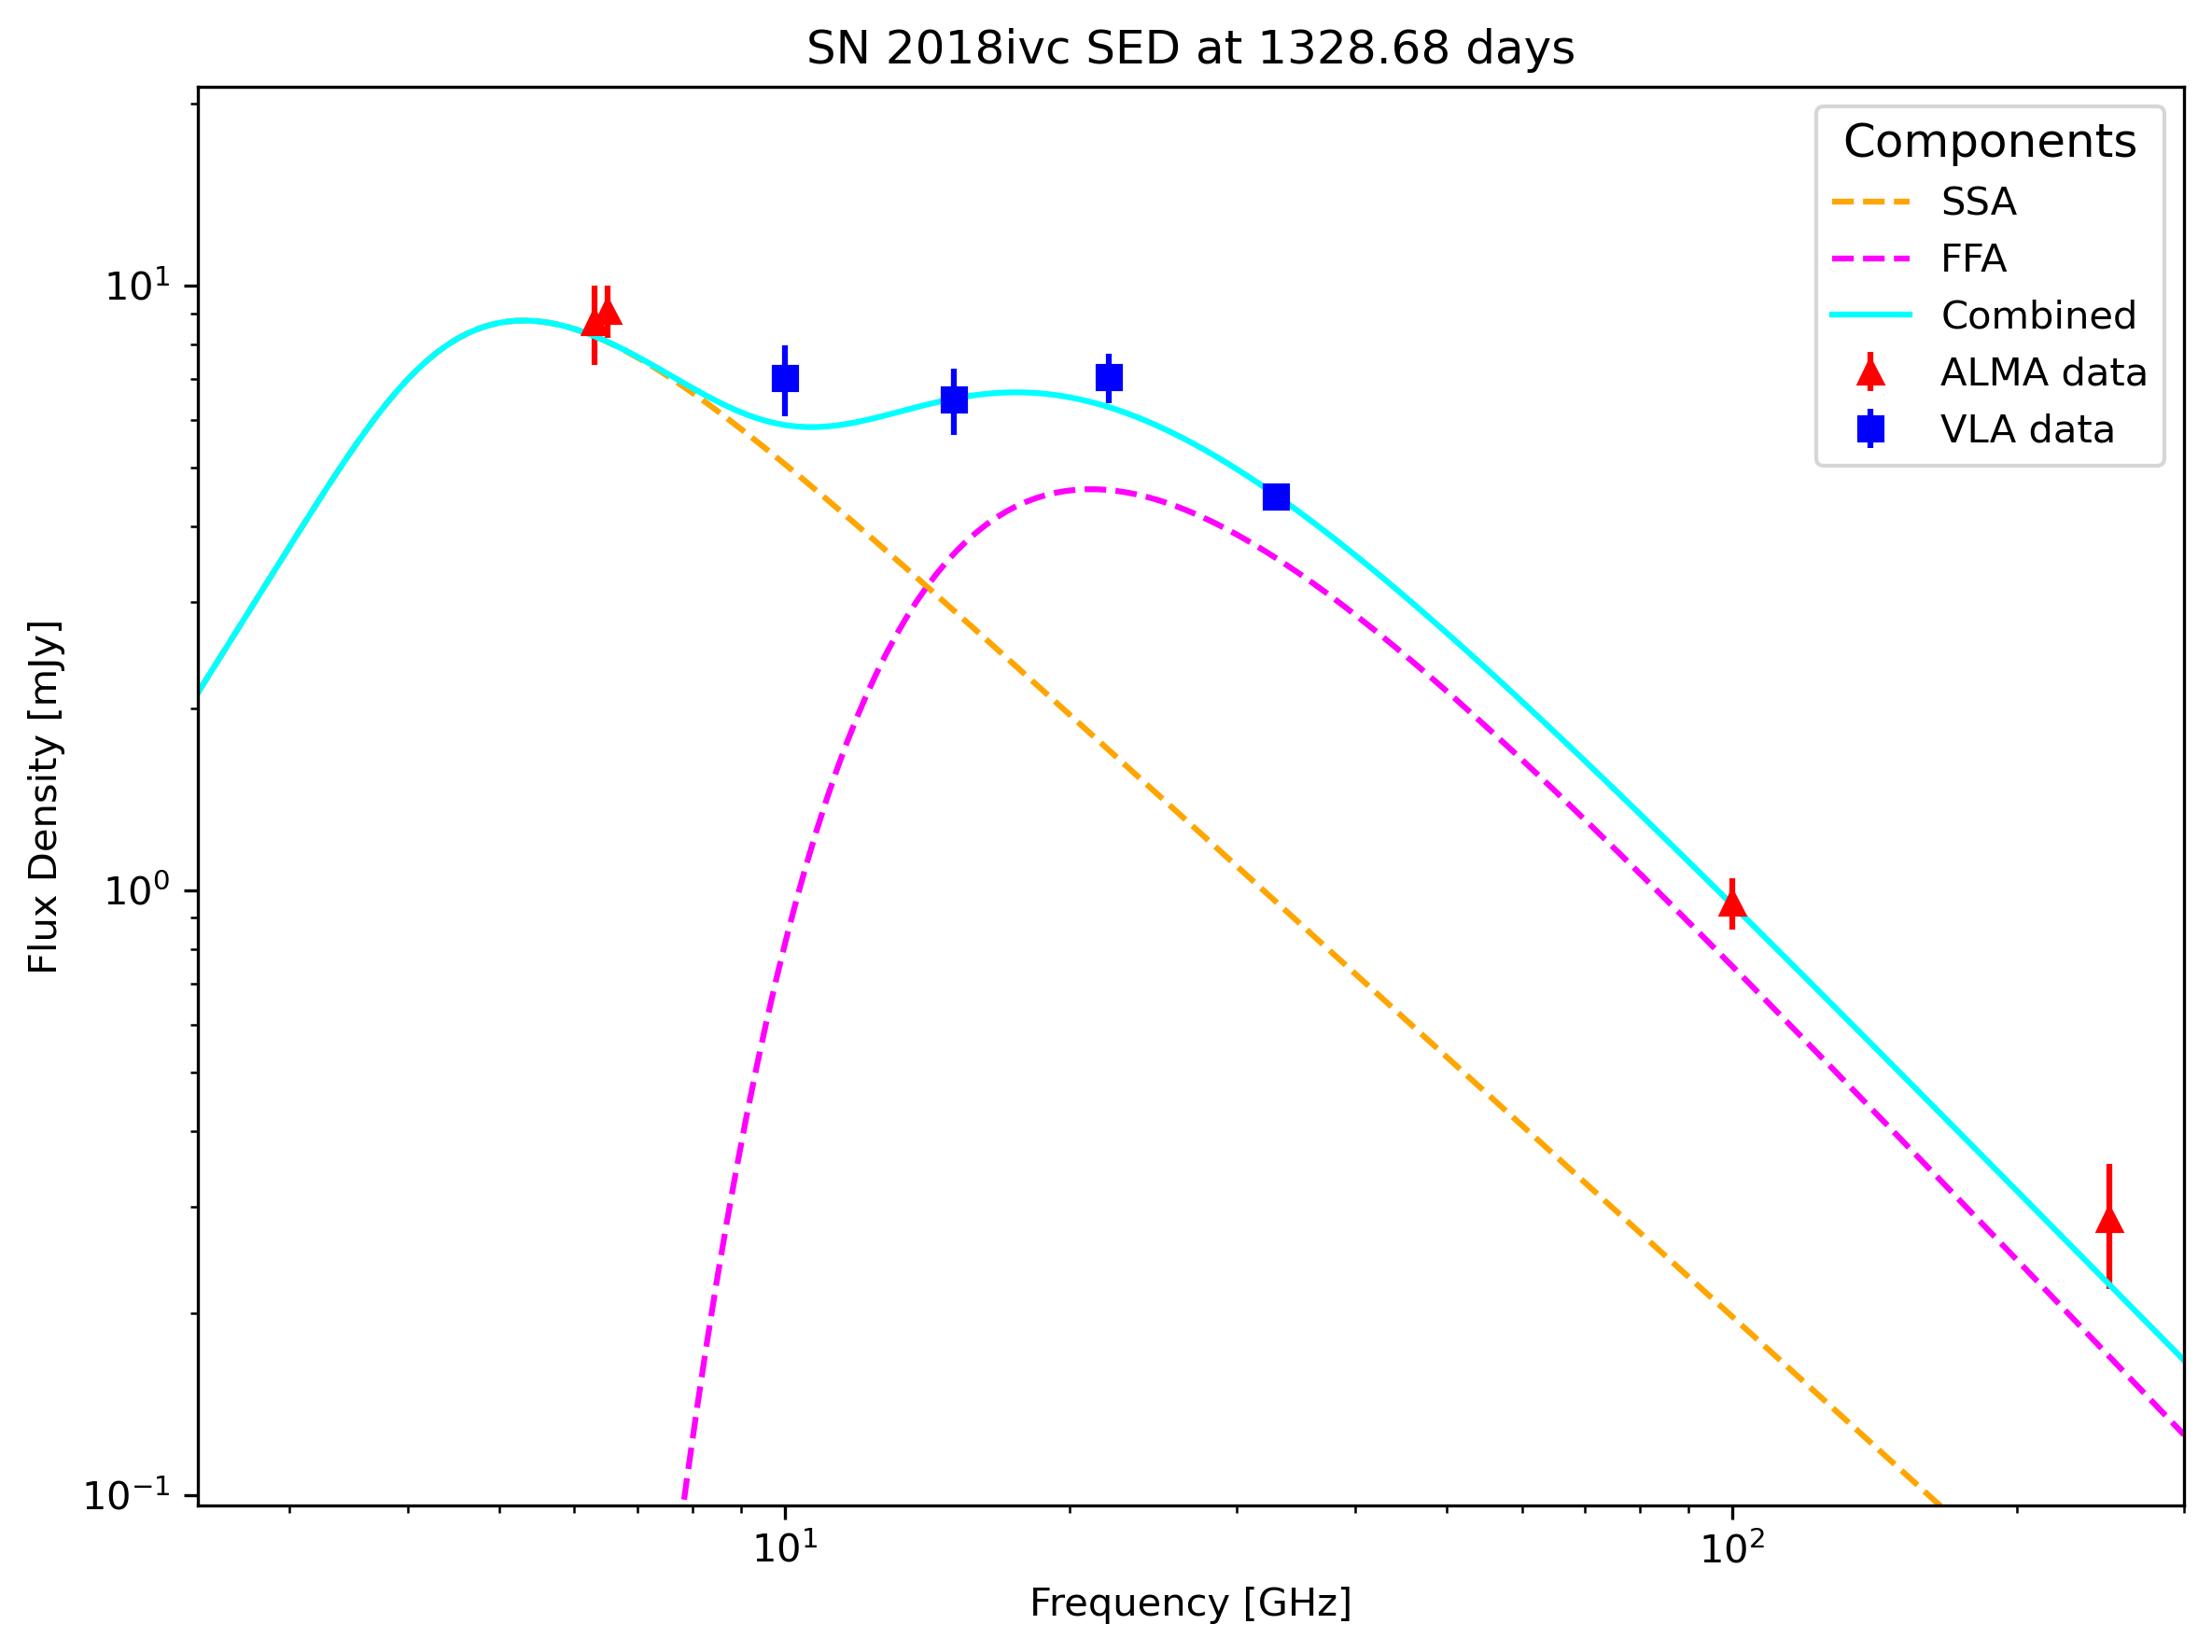

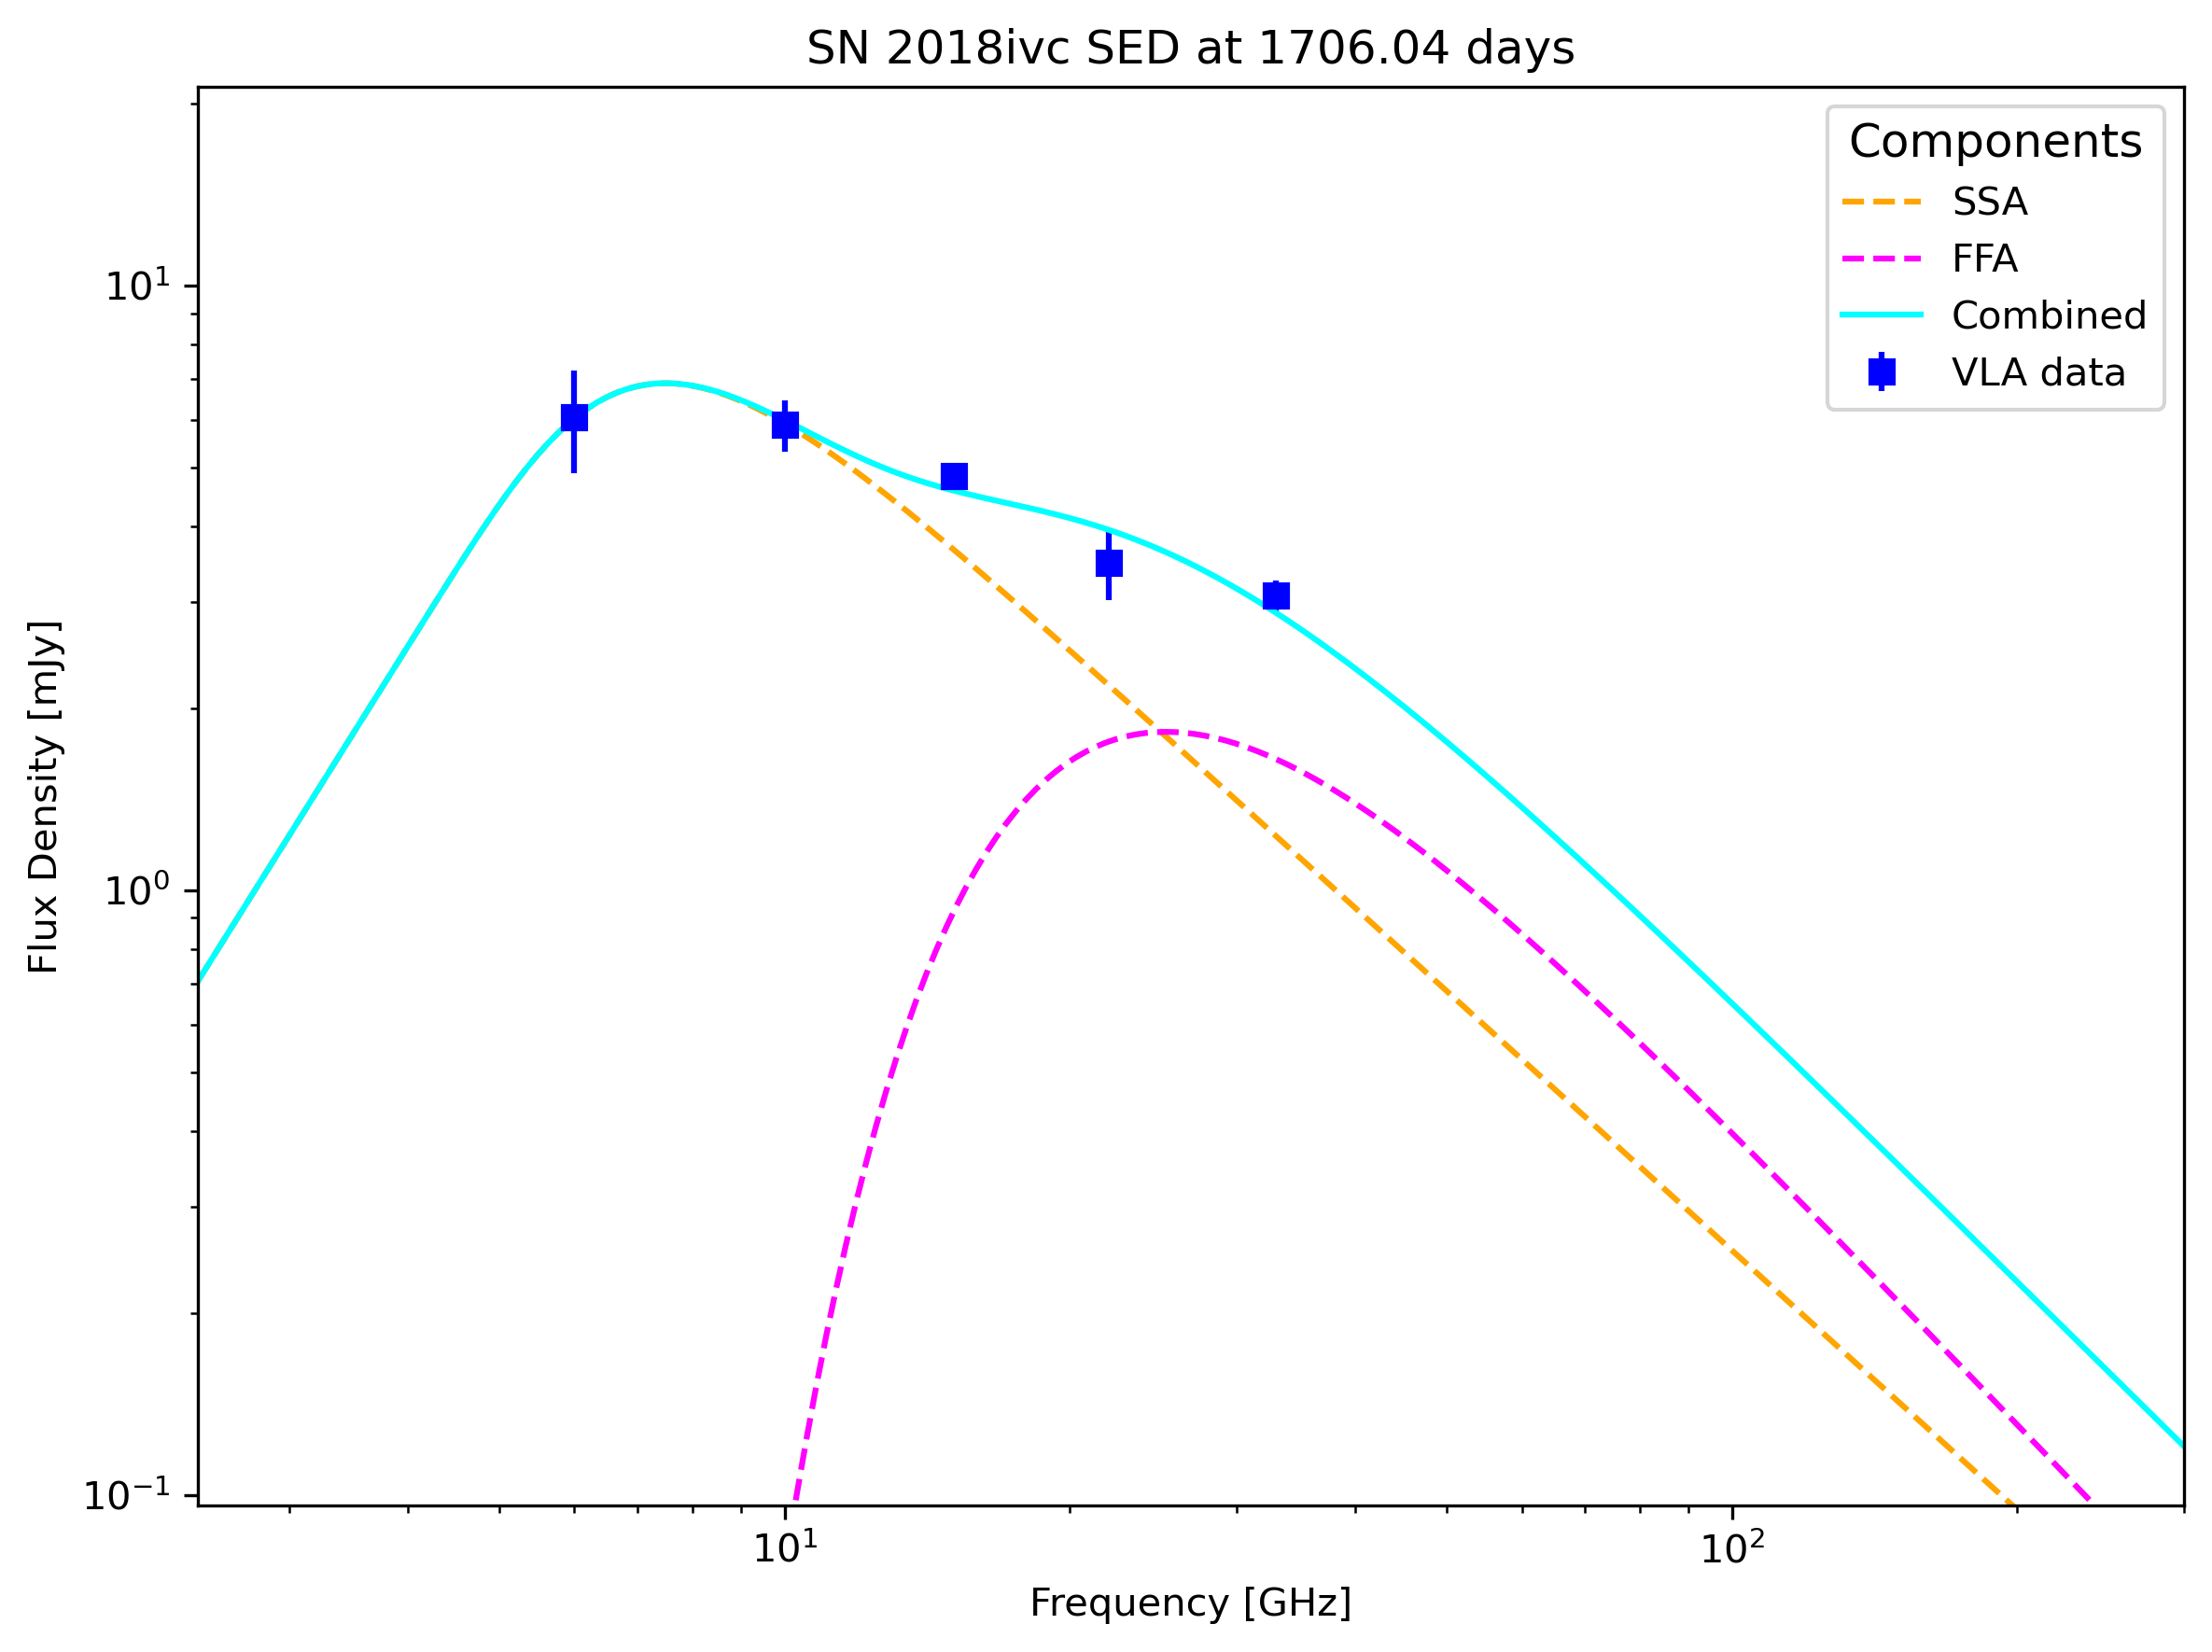

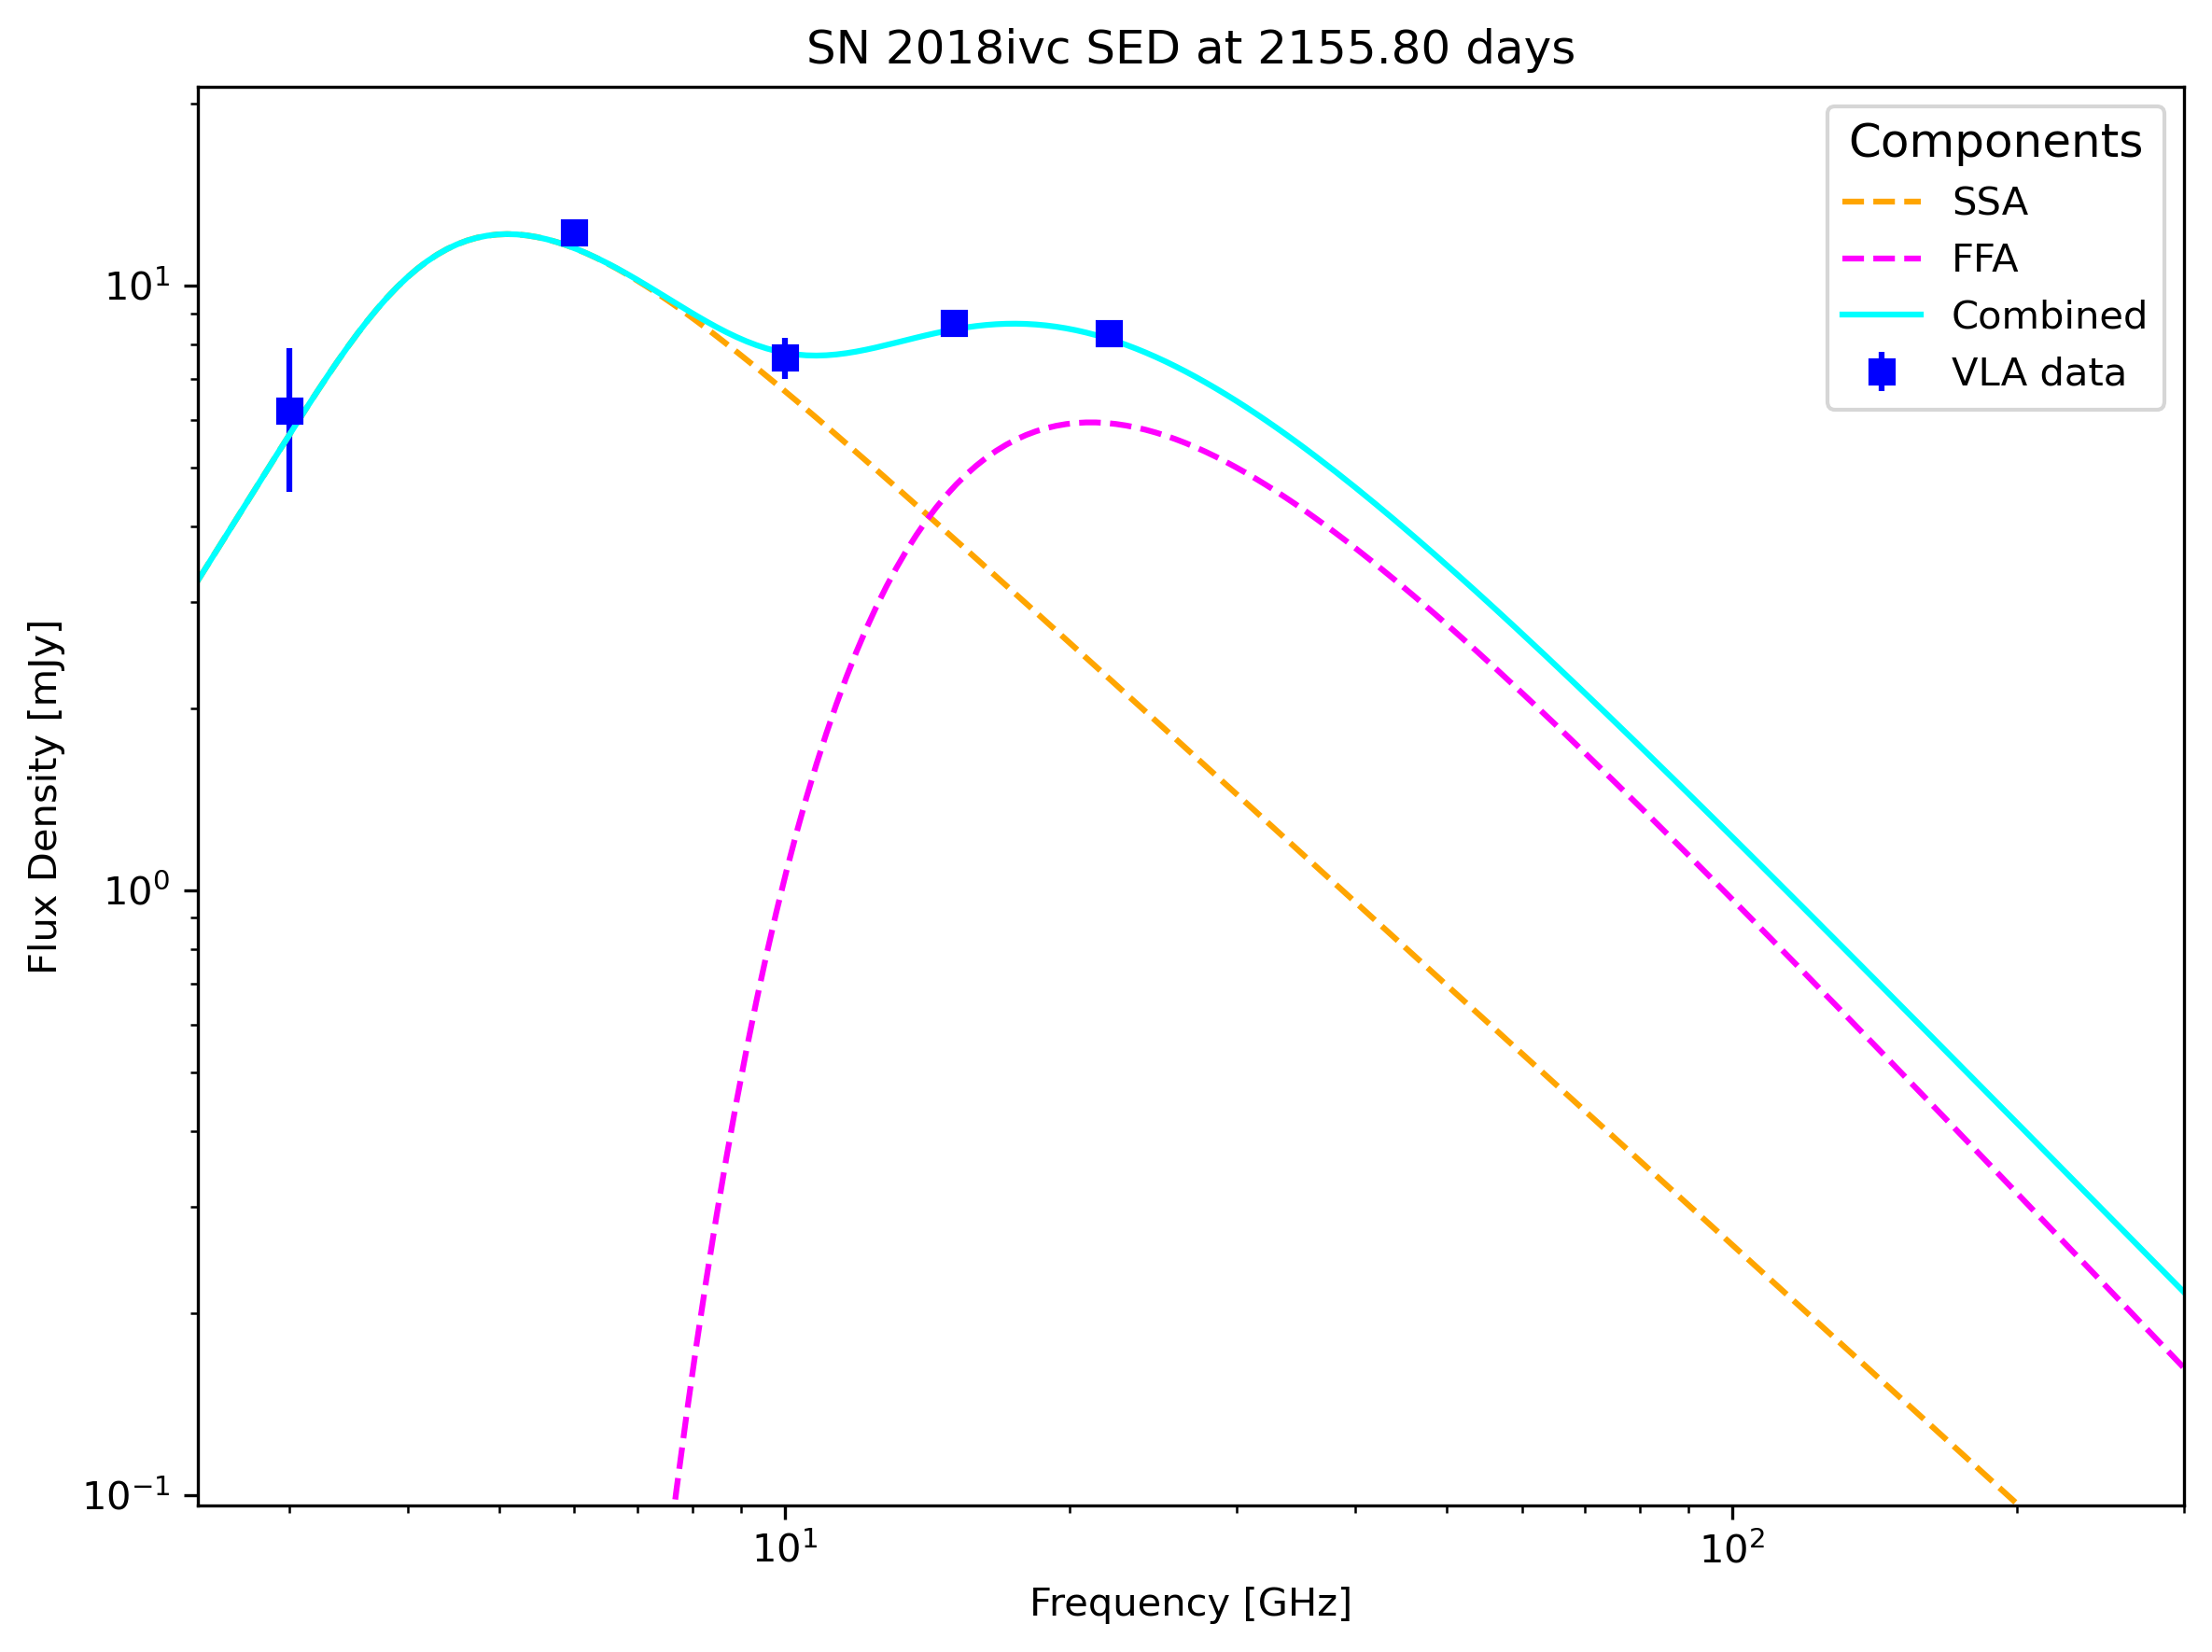

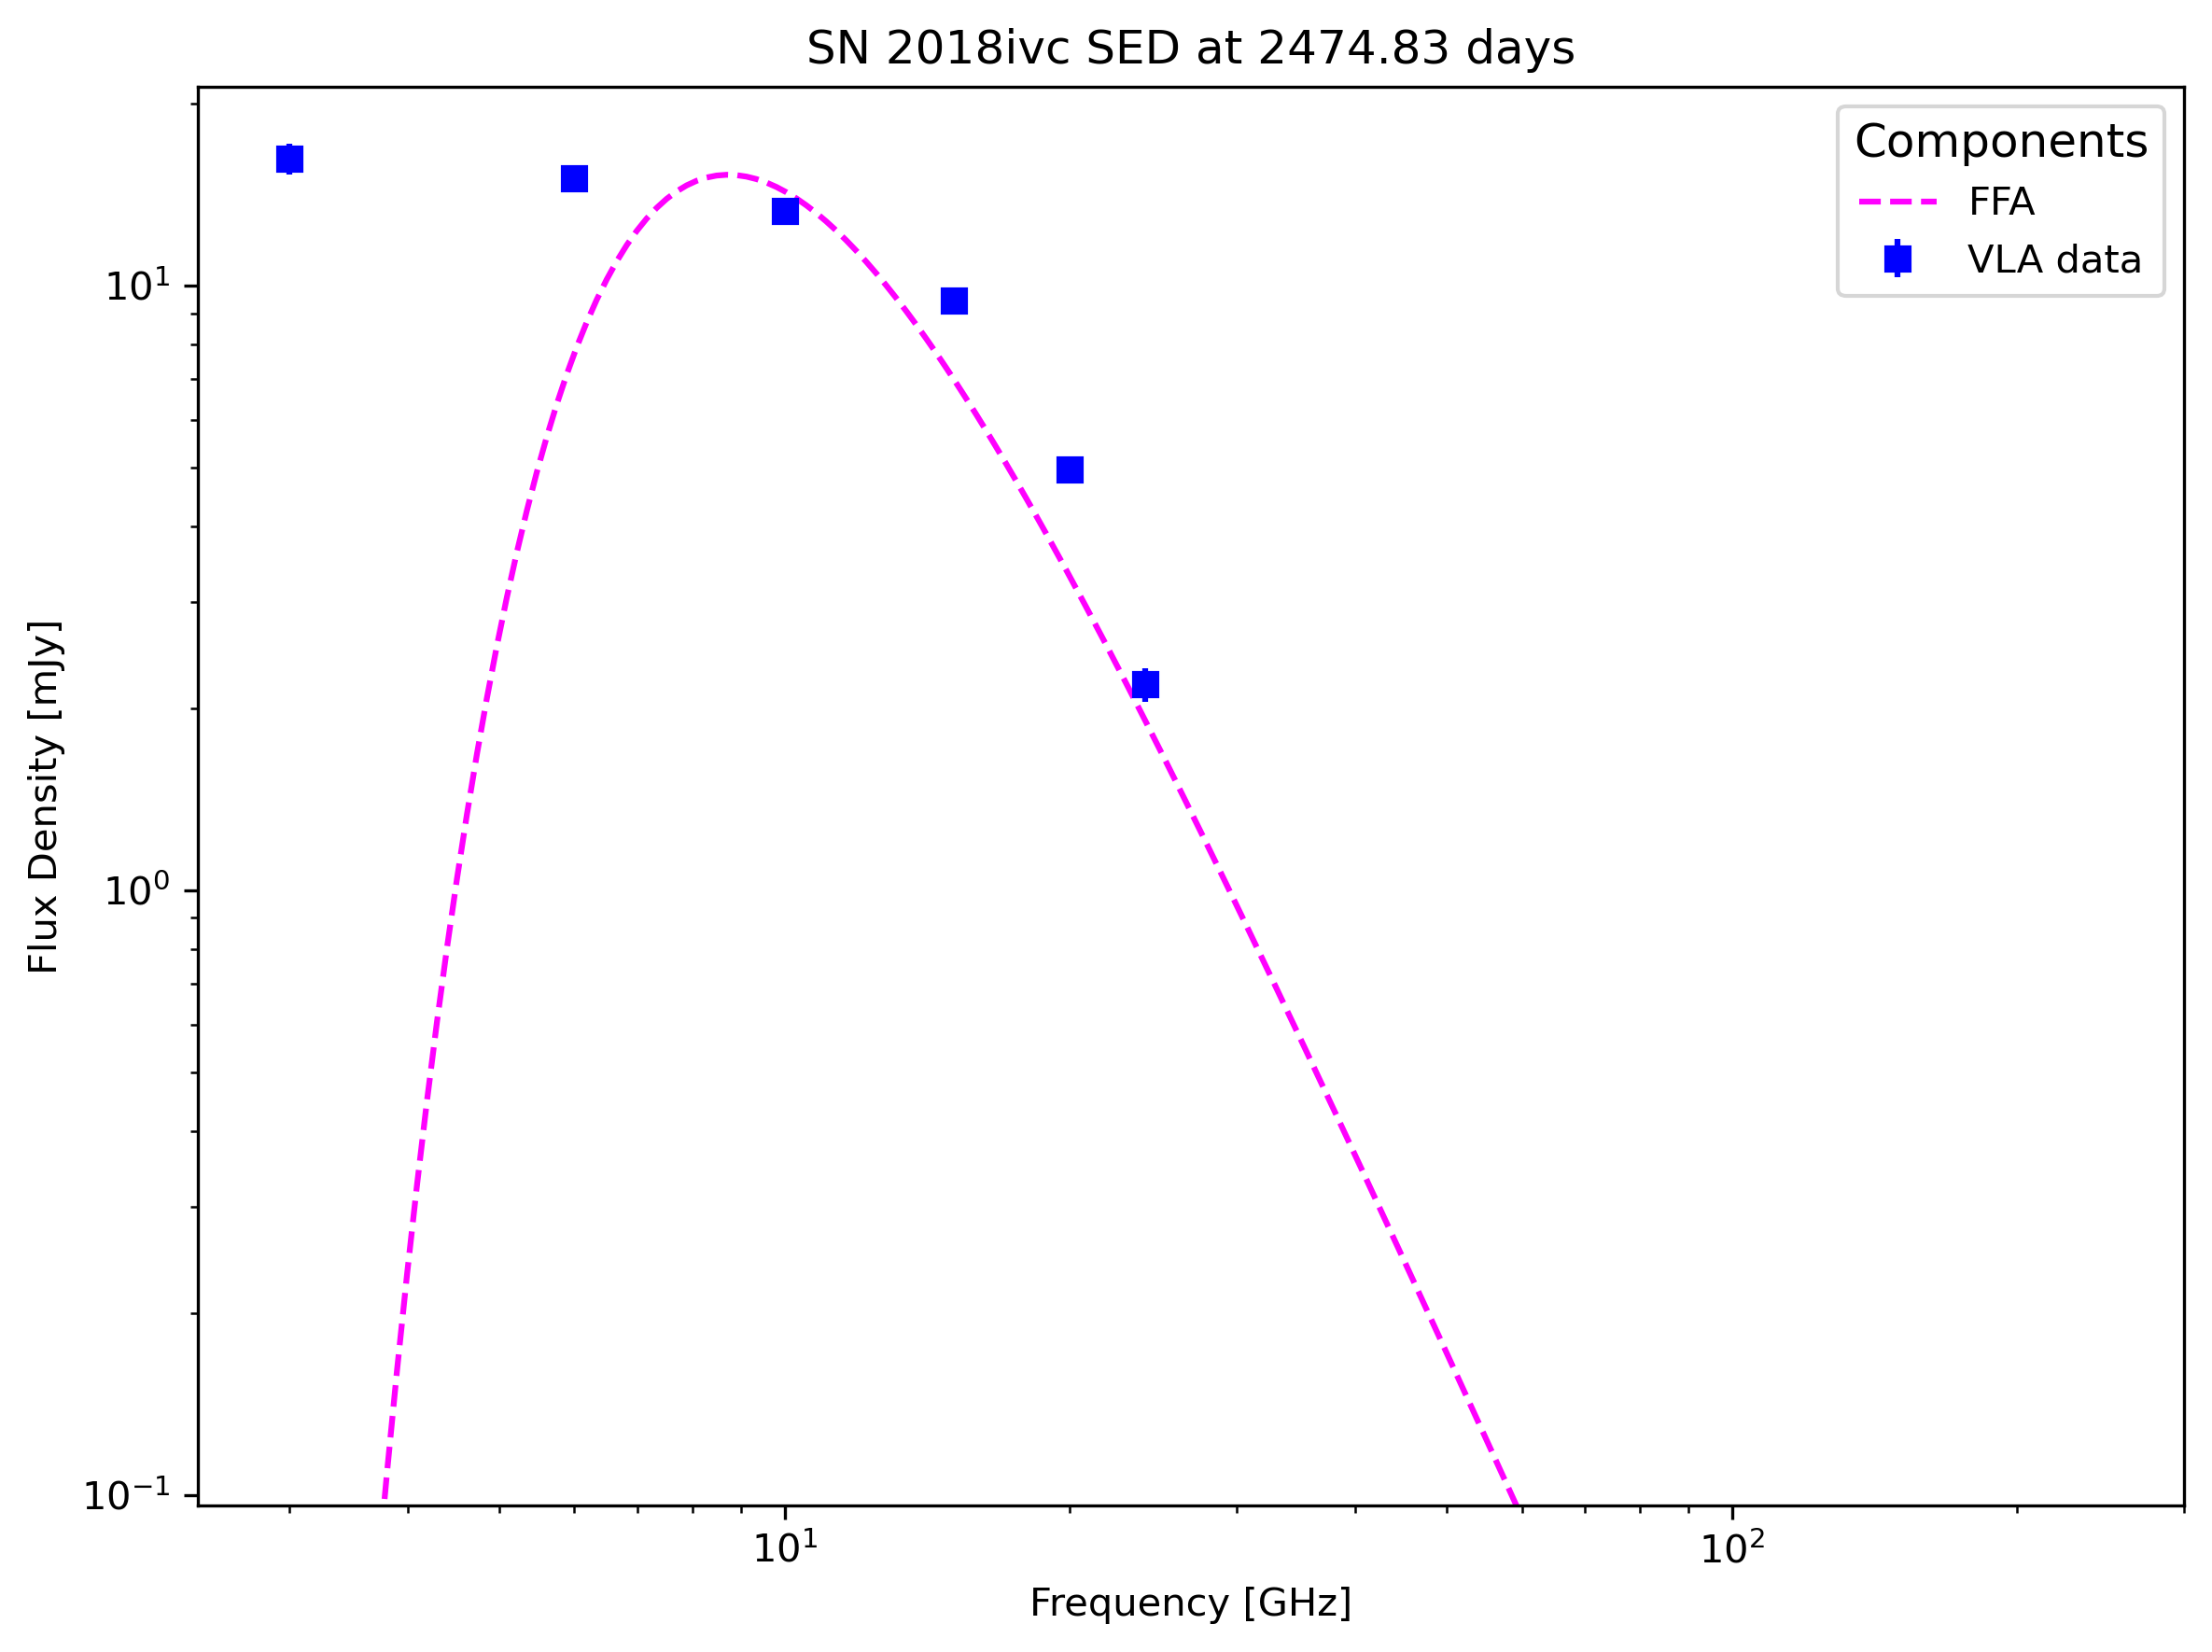

In [6]:
functions.plot_single_epoch(1200, 1400, data, x_sed, y_lims, [75.0, 0.07, 3.85], [34.5, 3.75, 1.65])
functions.plot_single_epoch(1600, 1800, data, x_sed, y_lims, [25.0, 0.27, 3.85], [18.5, 5.5, 1.65])
functions.plot_single_epoch(2000, 2200, data, x_sed, y_lims, [115.0, 0.06, 3.85], [44.5, 3.75, 1.65])
functions.plot_single_epoch(2300, 2490, data, x_sed, y_lims, comp1=None, comp2=[50.0, 1.25, 3.5])
# functions.plot_single_epoch(2300, 2490, data, (1.0, 100), (1.0, 30), comp1=[350.0, 0.03, 2.85], comp2=[5.0, 0.25, 3.5])

## Plot all the epochs on the same plot

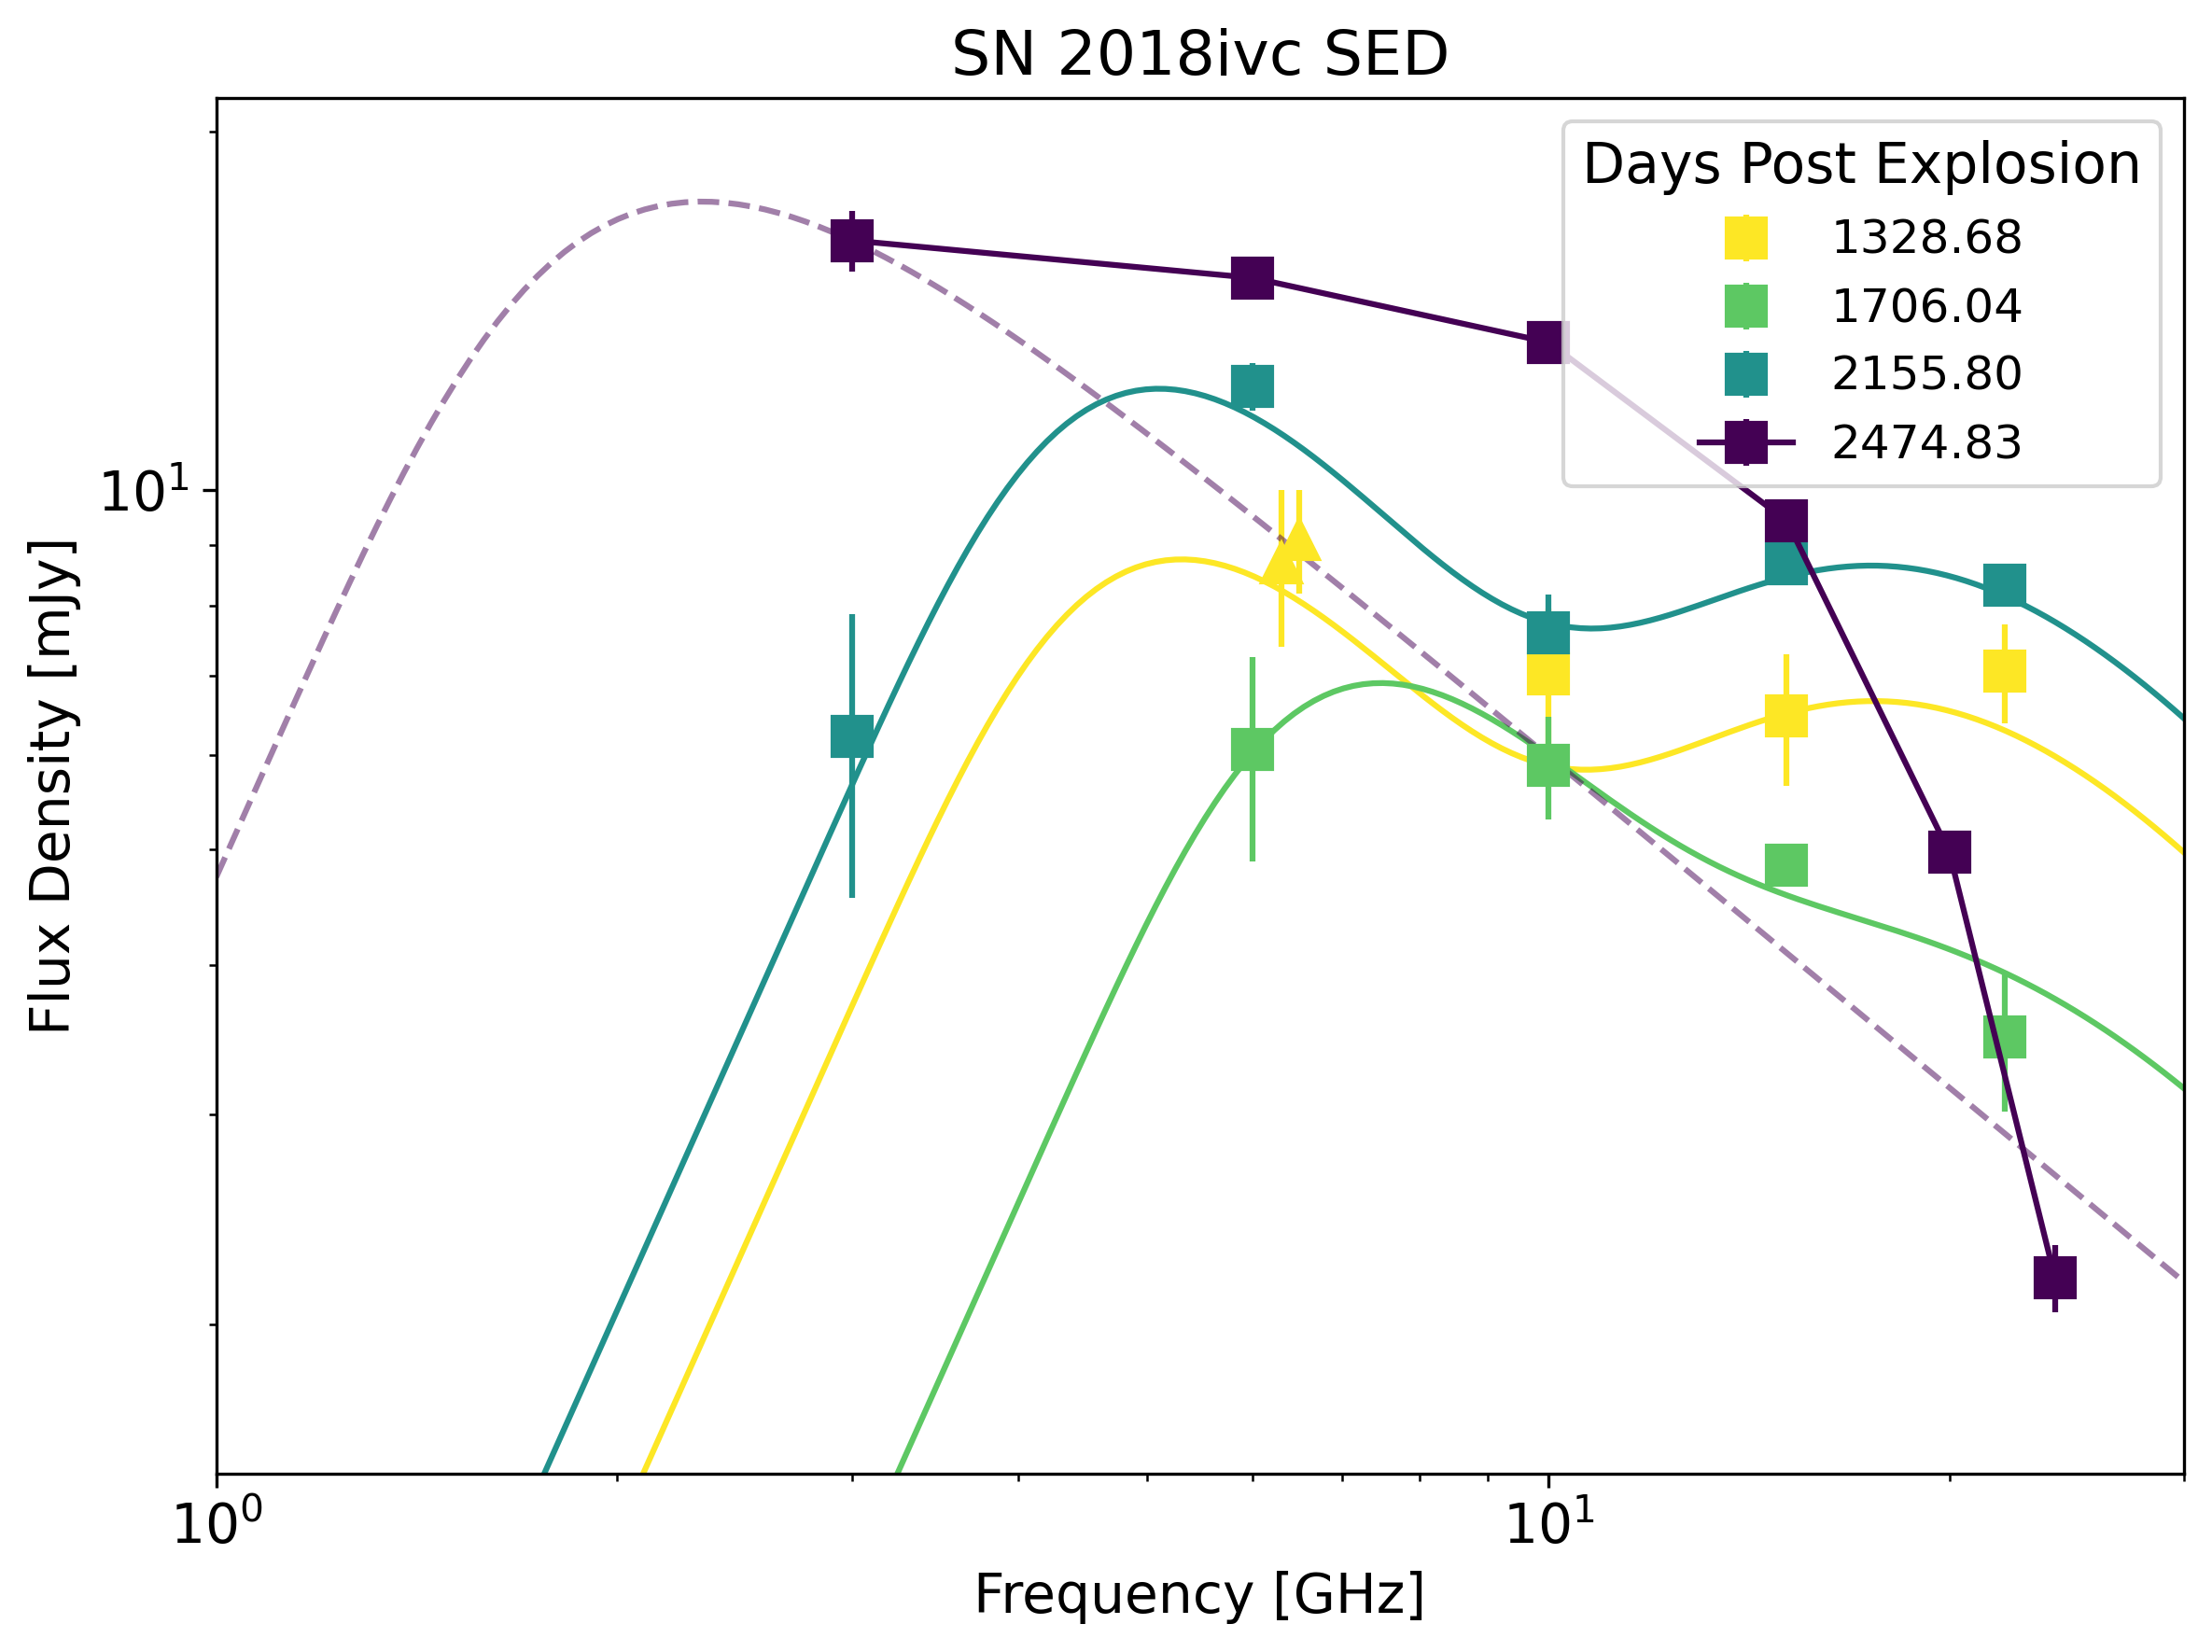

In [11]:
fig, ax = plt.subplots(figsize=(8,6), dpi=300)

epochs = [
    (1200, 1400, [75.0, 0.07, 3.85], [34.5, 3.75, 1.65], "#FDE725", "1300 d"),
    (1600, 1800, [25.0, 0.27, 3.85], [18.5, 5.5, 1.65], "#5DC863", "1700 d"),
    (2000, 2200, [115.0, 0.06, 3.85], [44.5, 3.75, 1.65], "#21918C", "2100 d"),
    (2350, 2500, None, [50.0, 1.25, 3.5], "#440154", "2400 d"),
]

for ph_lo, ph_hi, c1, c2, col, lab in epochs:
    functions.plot_single_epoch(ph_lo, ph_hi, data, (1.0, 30), (1.5, 21.324), comp1=c1, comp2=c2, color=col, ax=ax)

A1, A2, p2 = [1500.0, 0.004, 2.85]
freq_range = np.logspace(0, 2, 200)
latest_SSA = functions.F_SSA(freq_range, A1, A2, p2)
ax.plot(freq_range, latest_SSA, linestyle='--', color="#440154", alpha=0.5)

# Replace the title (each call sets it)
ax.set_title("SN 2018ivc SED", fontsize=16)

# fix legend to be unique once at end
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title="Days Post Explosion", title_fontsize='x-large', fontsize='large')
fig.tight_layout()
plt.show()

## Plot the light curve at all frequencies

In [12]:
# bin the data
# early only
data_250 = data[data['freq']==250.0]
data_100 = data[((data['freq']>90.0)&(data['freq']<110.0))]

# late only
data_Ku = data[((data['freq']>11.0)&(data['freq']<19.0))]
data_X = data[((data['freq']>9.0)&(data['freq']<11.0))]
data_S = data[((data['freq']>2.0)&(data['freq']<4.0))]

# both
data_Ka = data[((data['freq']>30.0)&(data['freq']<35.0))]
data_K = data[((data['freq']>20.0)&(data['freq']<25.0))]
data_C = data[((data['freq']>5.0)&(data['freq']<7.0))]

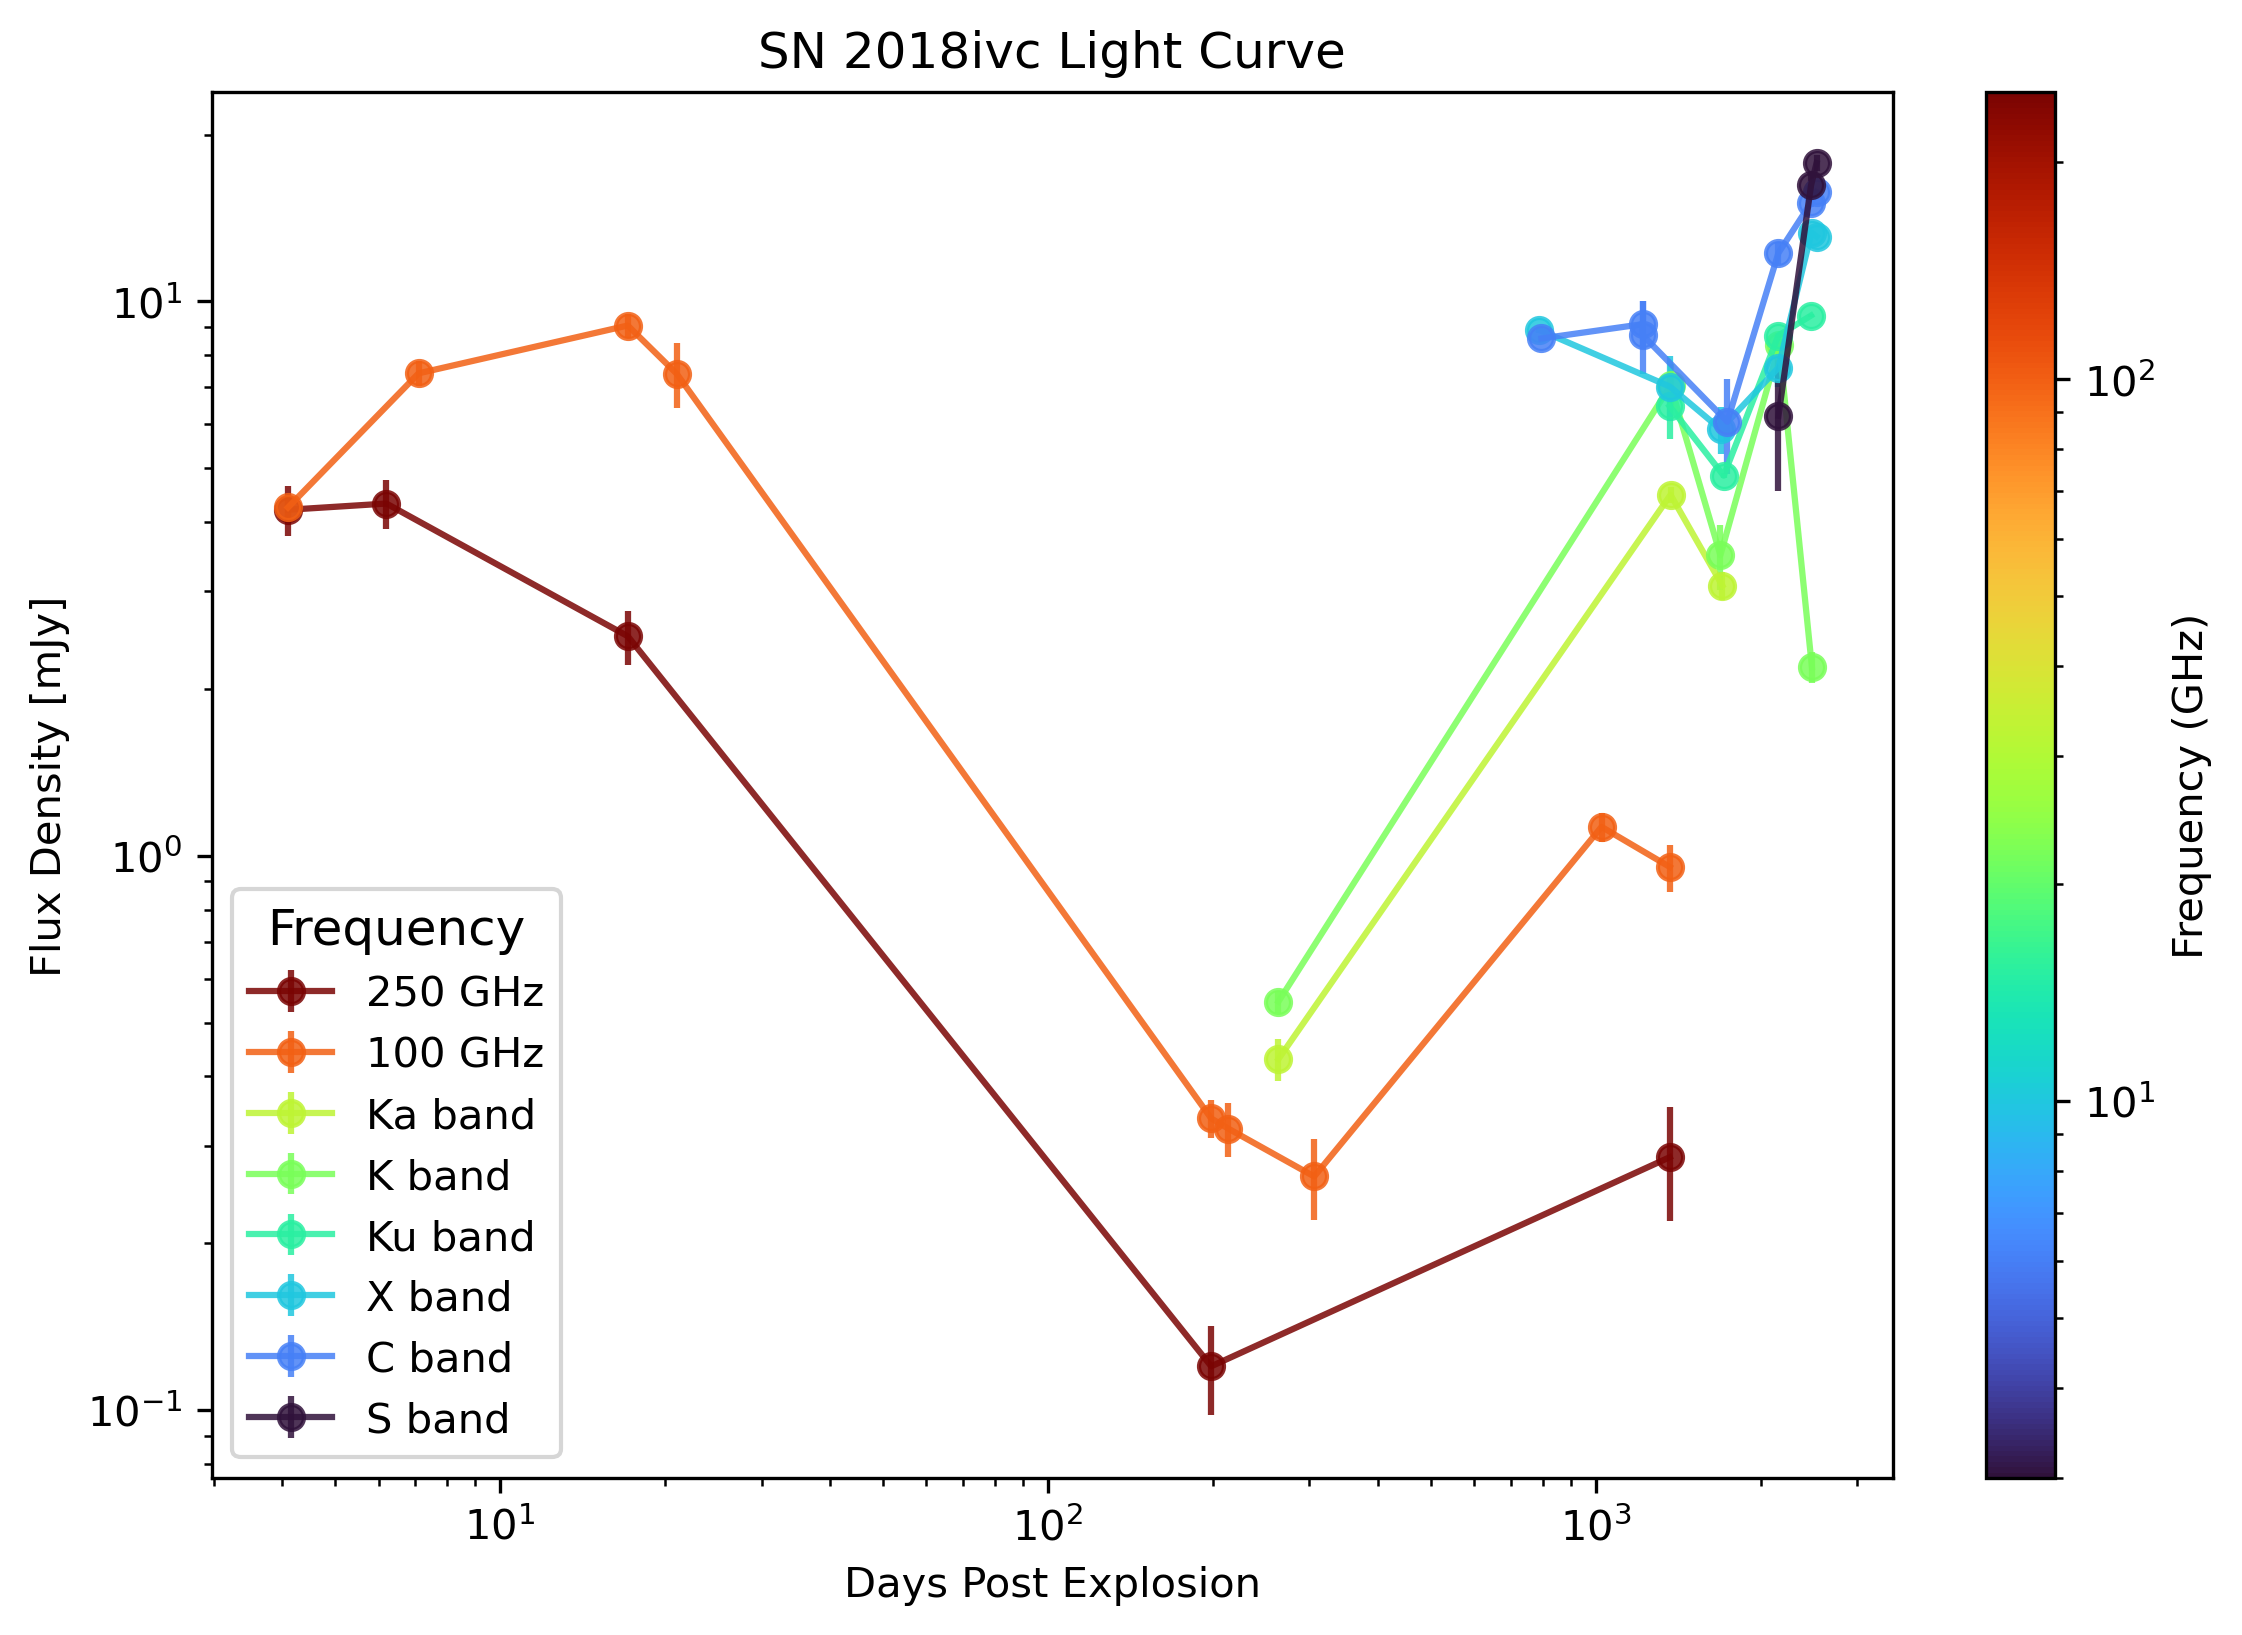

In [13]:
# plot the full light curve
import matplotlib as mpl
from matplotlib.colors import LogNorm

freq_map = {
    "250 GHz": 250,
    "100 GHz": 100,
    "Ku band": 15,
    "X band": 10,
    "S band": 3,
    "Ka band": 33,
    "K band": 22,
    "C band": 6
}
freqs = list(freq_map.values())

norm = LogNorm(vmin=min(freqs), vmax=max(freqs))
cmap = mpl.colormaps["turbo"]
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, ax = plt.subplots(dpi=300, figsize=(8,6))

def plot_band(data, label):
    f = freq_map[label]
    color = cmap(norm(f))

    ax.errorbar(
        data['phase'],
        data['flux'],
        data['flux_err'],
        fmt='o-',
        color=color,
        alpha=0.85,   # slight transparency
        label=label
    )

# --- Plot all bands ---
plot_band(data_250, "250 GHz")
plot_band(data_100, "100 GHz")
plot_band(data_Ka, "Ka band")
plot_band(data_K, "K band")
plot_band(data_Ku, "Ku band")
plot_band(data_X, "X band")
plot_band(data_C, "C band")
plot_band(data_S, "S band")

# --- Axes formatting ---
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(title="Frequency", title_fontsize='large')
ax.set_xlabel('Days Post Explosion')
ax.set_ylabel('Flux Density [mJy]')
ax.set_title('SN 2018ivc Light Curve')

# --- Log colorbar ---
cbar = fig.colorbar(sm, ax=ax, fraction=0.046)
cbar.set_label("Frequency (GHz)")

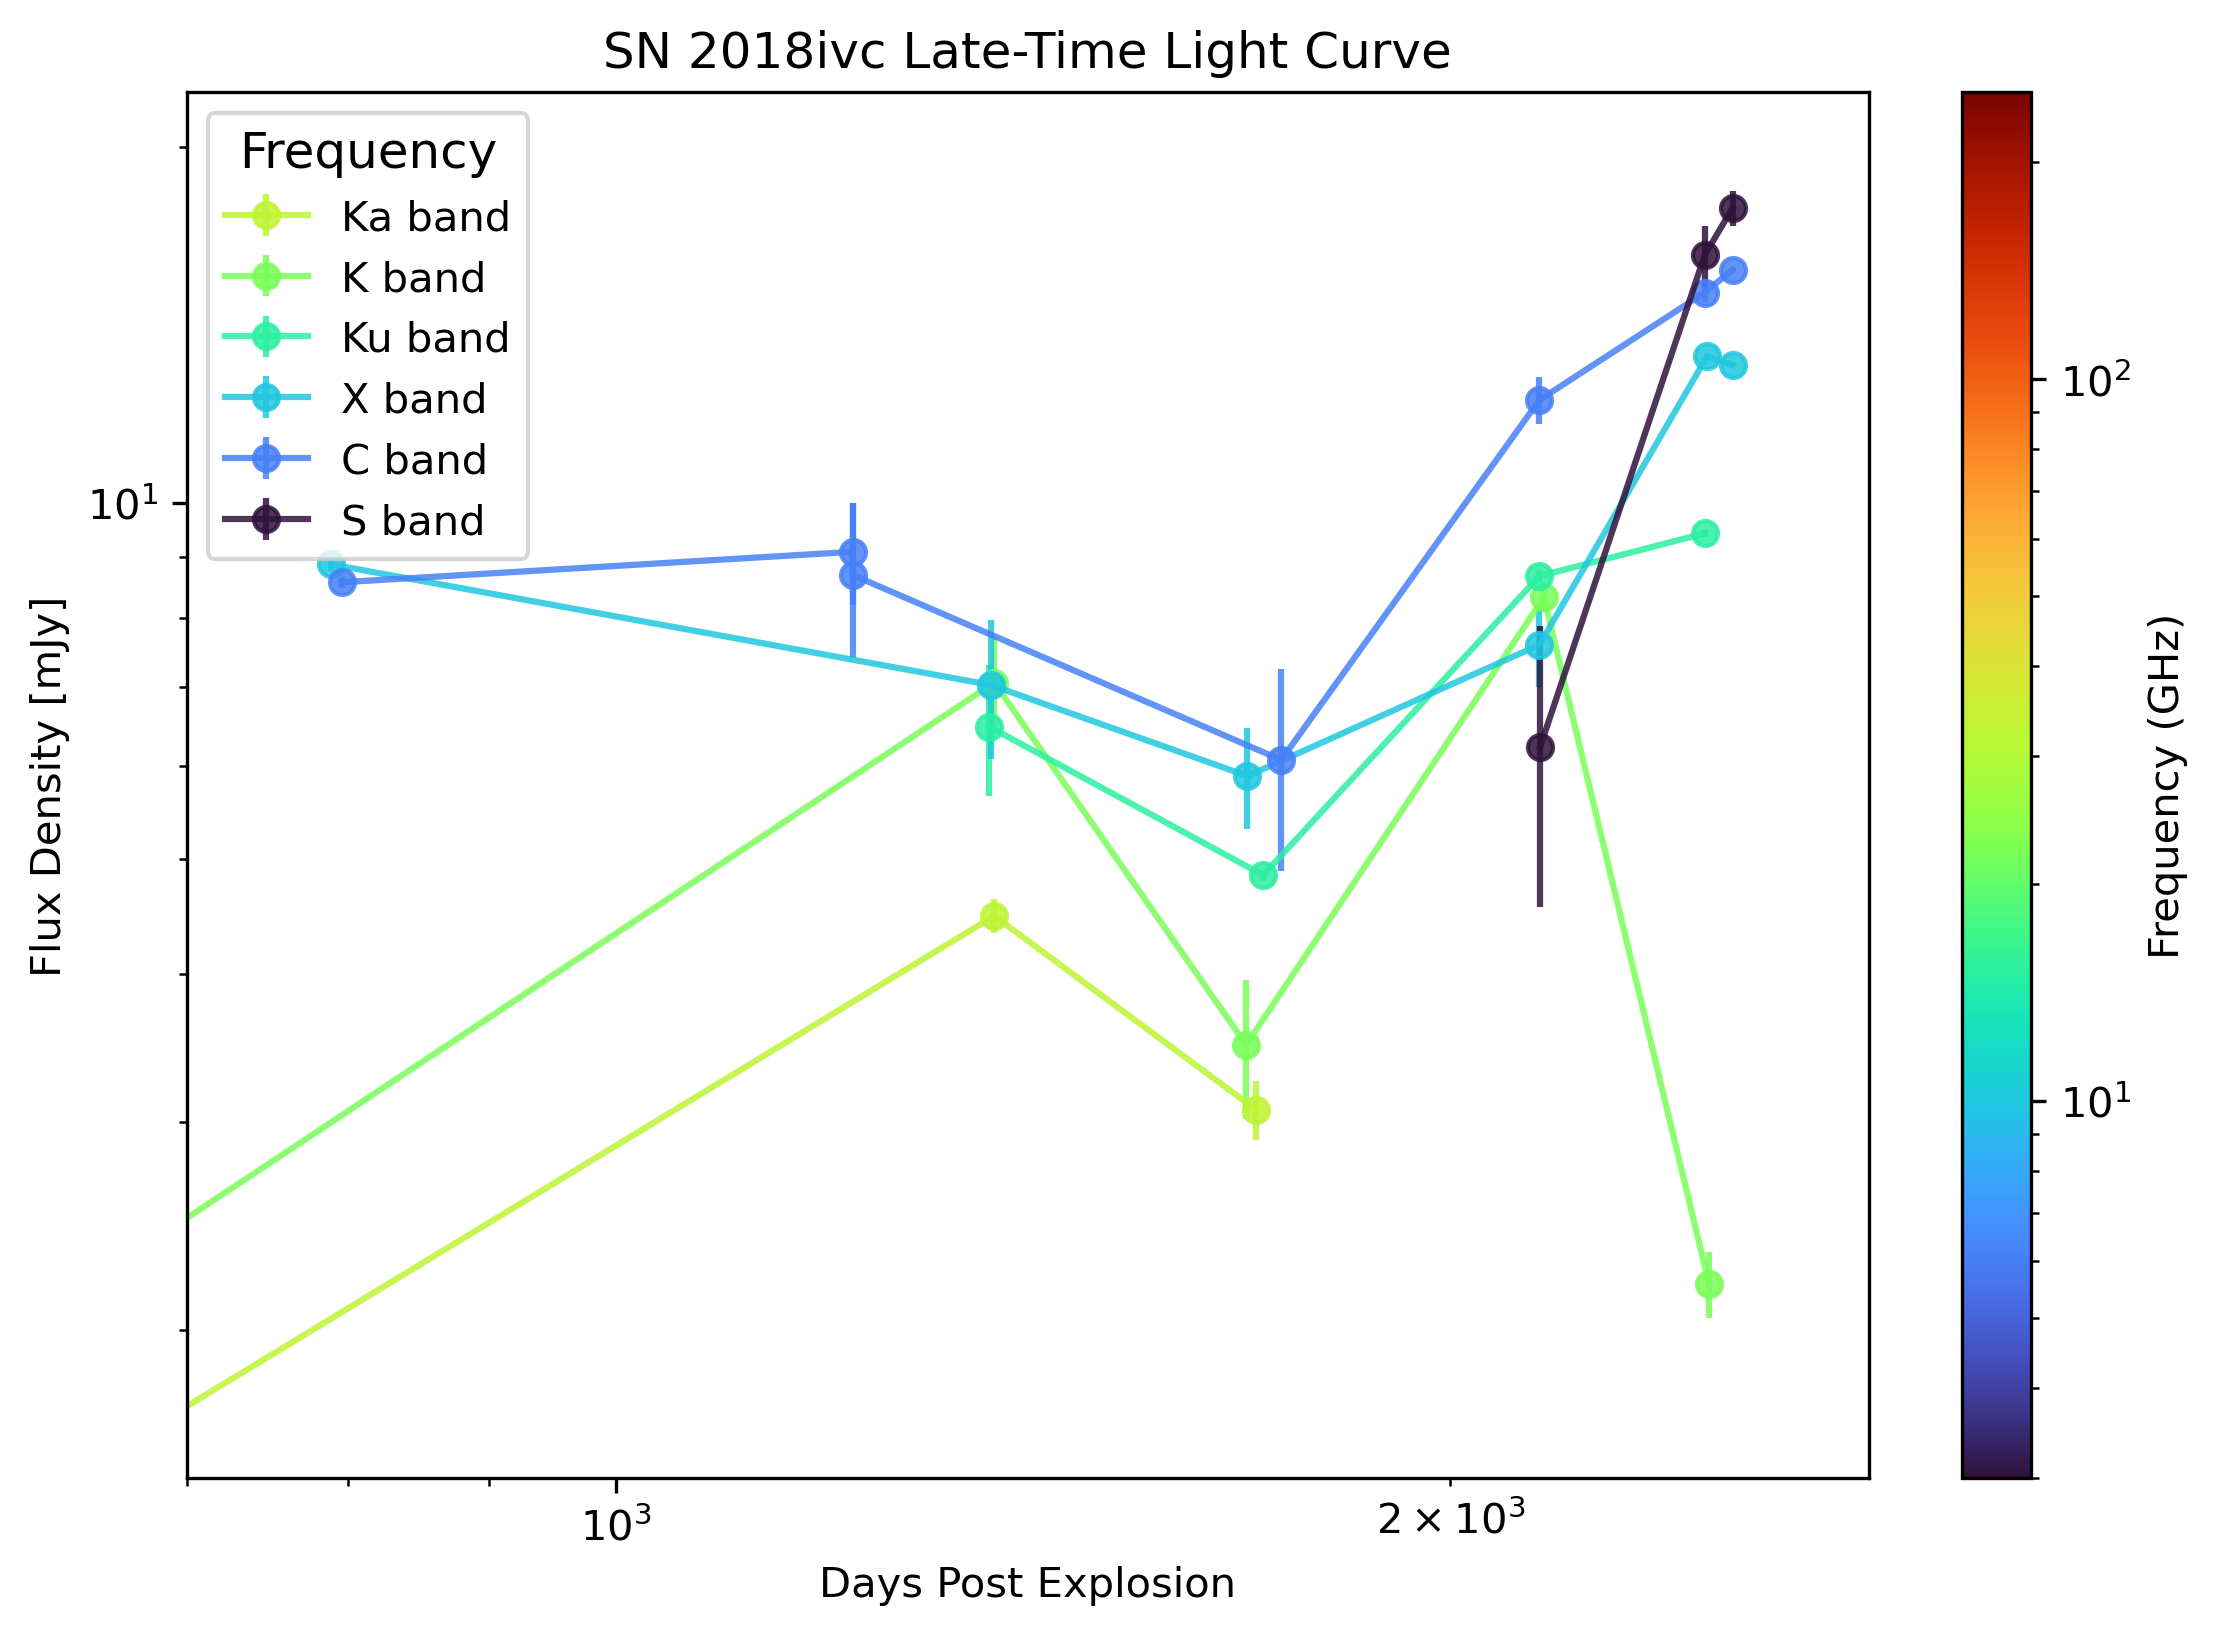

In [15]:
# now just plot the late time light curve 
import matplotlib as mpl
from matplotlib.colors import LogNorm

freq_map = {
    "250 GHz": 250,
    "100 GHz": 100,
    "Ku band": 15,
    "X band": 10,
    "S band": 3,
    "Ka band": 33,
    "K band": 22,
    "C band": 6
}
freqs = list(freq_map.values())

norm = LogNorm(vmin=min(freqs), vmax=max(freqs))
cmap = mpl.colormaps["turbo"]
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

fig, ax = plt.subplots(dpi=300, figsize=(8,6))

def plot_band(data, label):
    f = freq_map[label]
    color = cmap(norm(f))

    ax.errorbar(
        data['phase'],
        data['flux'],
        data['flux_err'],
        fmt='o-',
        color=color,
        alpha=0.85,   # slight transparency
        label=label
    )

# --- Plot all bands ---
plot_band(data_Ka, "Ka band")
plot_band(data_K, "K band")
plot_band(data_Ku, "Ku band")
plot_band(data_X, "X band")
plot_band(data_C, "C band")
plot_band(data_S, "S band")

# --- Axes formatting ---
ax.set_xscale('log')
ax.set_yscale('log')

ax.legend(title="Frequency", title_fontsize='large')
ax.set_xlabel('Days Post Explosion')
ax.set_ylabel('Flux Density [mJy]')
ax.set_title('SN 2018ivc Late-Time Light Curve')
ax.set_xlim(700, None)
ax.set_ylim(1.5, None)

# --- Log colorbar ---
cbar = fig.colorbar(sm, ax=ax, fraction=0.046)
cbar.set_label("Frequency (GHz)")

# Estimate R, B, and v for each component by assuming SSA, getting a value for K1, K2, and p, and calculating R and B from those

In [59]:
# Load in model independent parameters
D = 10.1 # in Mpc, as adopted by Maeda et al. 2023 and Boestrom et al. 2020
D_err = 1.8 # ^^
v_wind = 20 # km/s, use 20 b/c it is used in Maeda+2023a
v_ej = 7000 # km/s, adopted from Boestrom et al. 2020
T_e = 10**5 # K, standard value to adopt
epsilon_B = 0.012 # from Maeda+2023a, Model A
m_H = 1 # fractional mass, normalize so that it's 1

# scale factors:
F_p_scale = 1 # Jy
D_scale = 1 # Mpc
nu_p_scale = 5 # GHz, from eqn 12 of Chandra 2018
v_wind_scale = 10 # km/s, should this be the same or different from the actual value adopted?
v_ej_scale = 10**4 # km/s
T_e_scale = 10**5 # K
t_scale = 100 # days, adapt to be consistent for whatever formula
epsilon_B_scale = 0.1
B_scale = 1 # Gauss

# conversion factors
cmday_to_kmsec = (1/(10**5 * 86400))

Component 1: nu_p = 5.30 GHz, F_p = 8.75 mJy, R = 2.04e+17 cm, v = 1.78e+04 km/s, B = 2.83e-01 G
Component 2: nu_p = 20.52 GHz, F_p = 5.22 mJy, R = 4.13e+16 cm, v = 3.59e+03 km/s, B = 1.15e+00 G


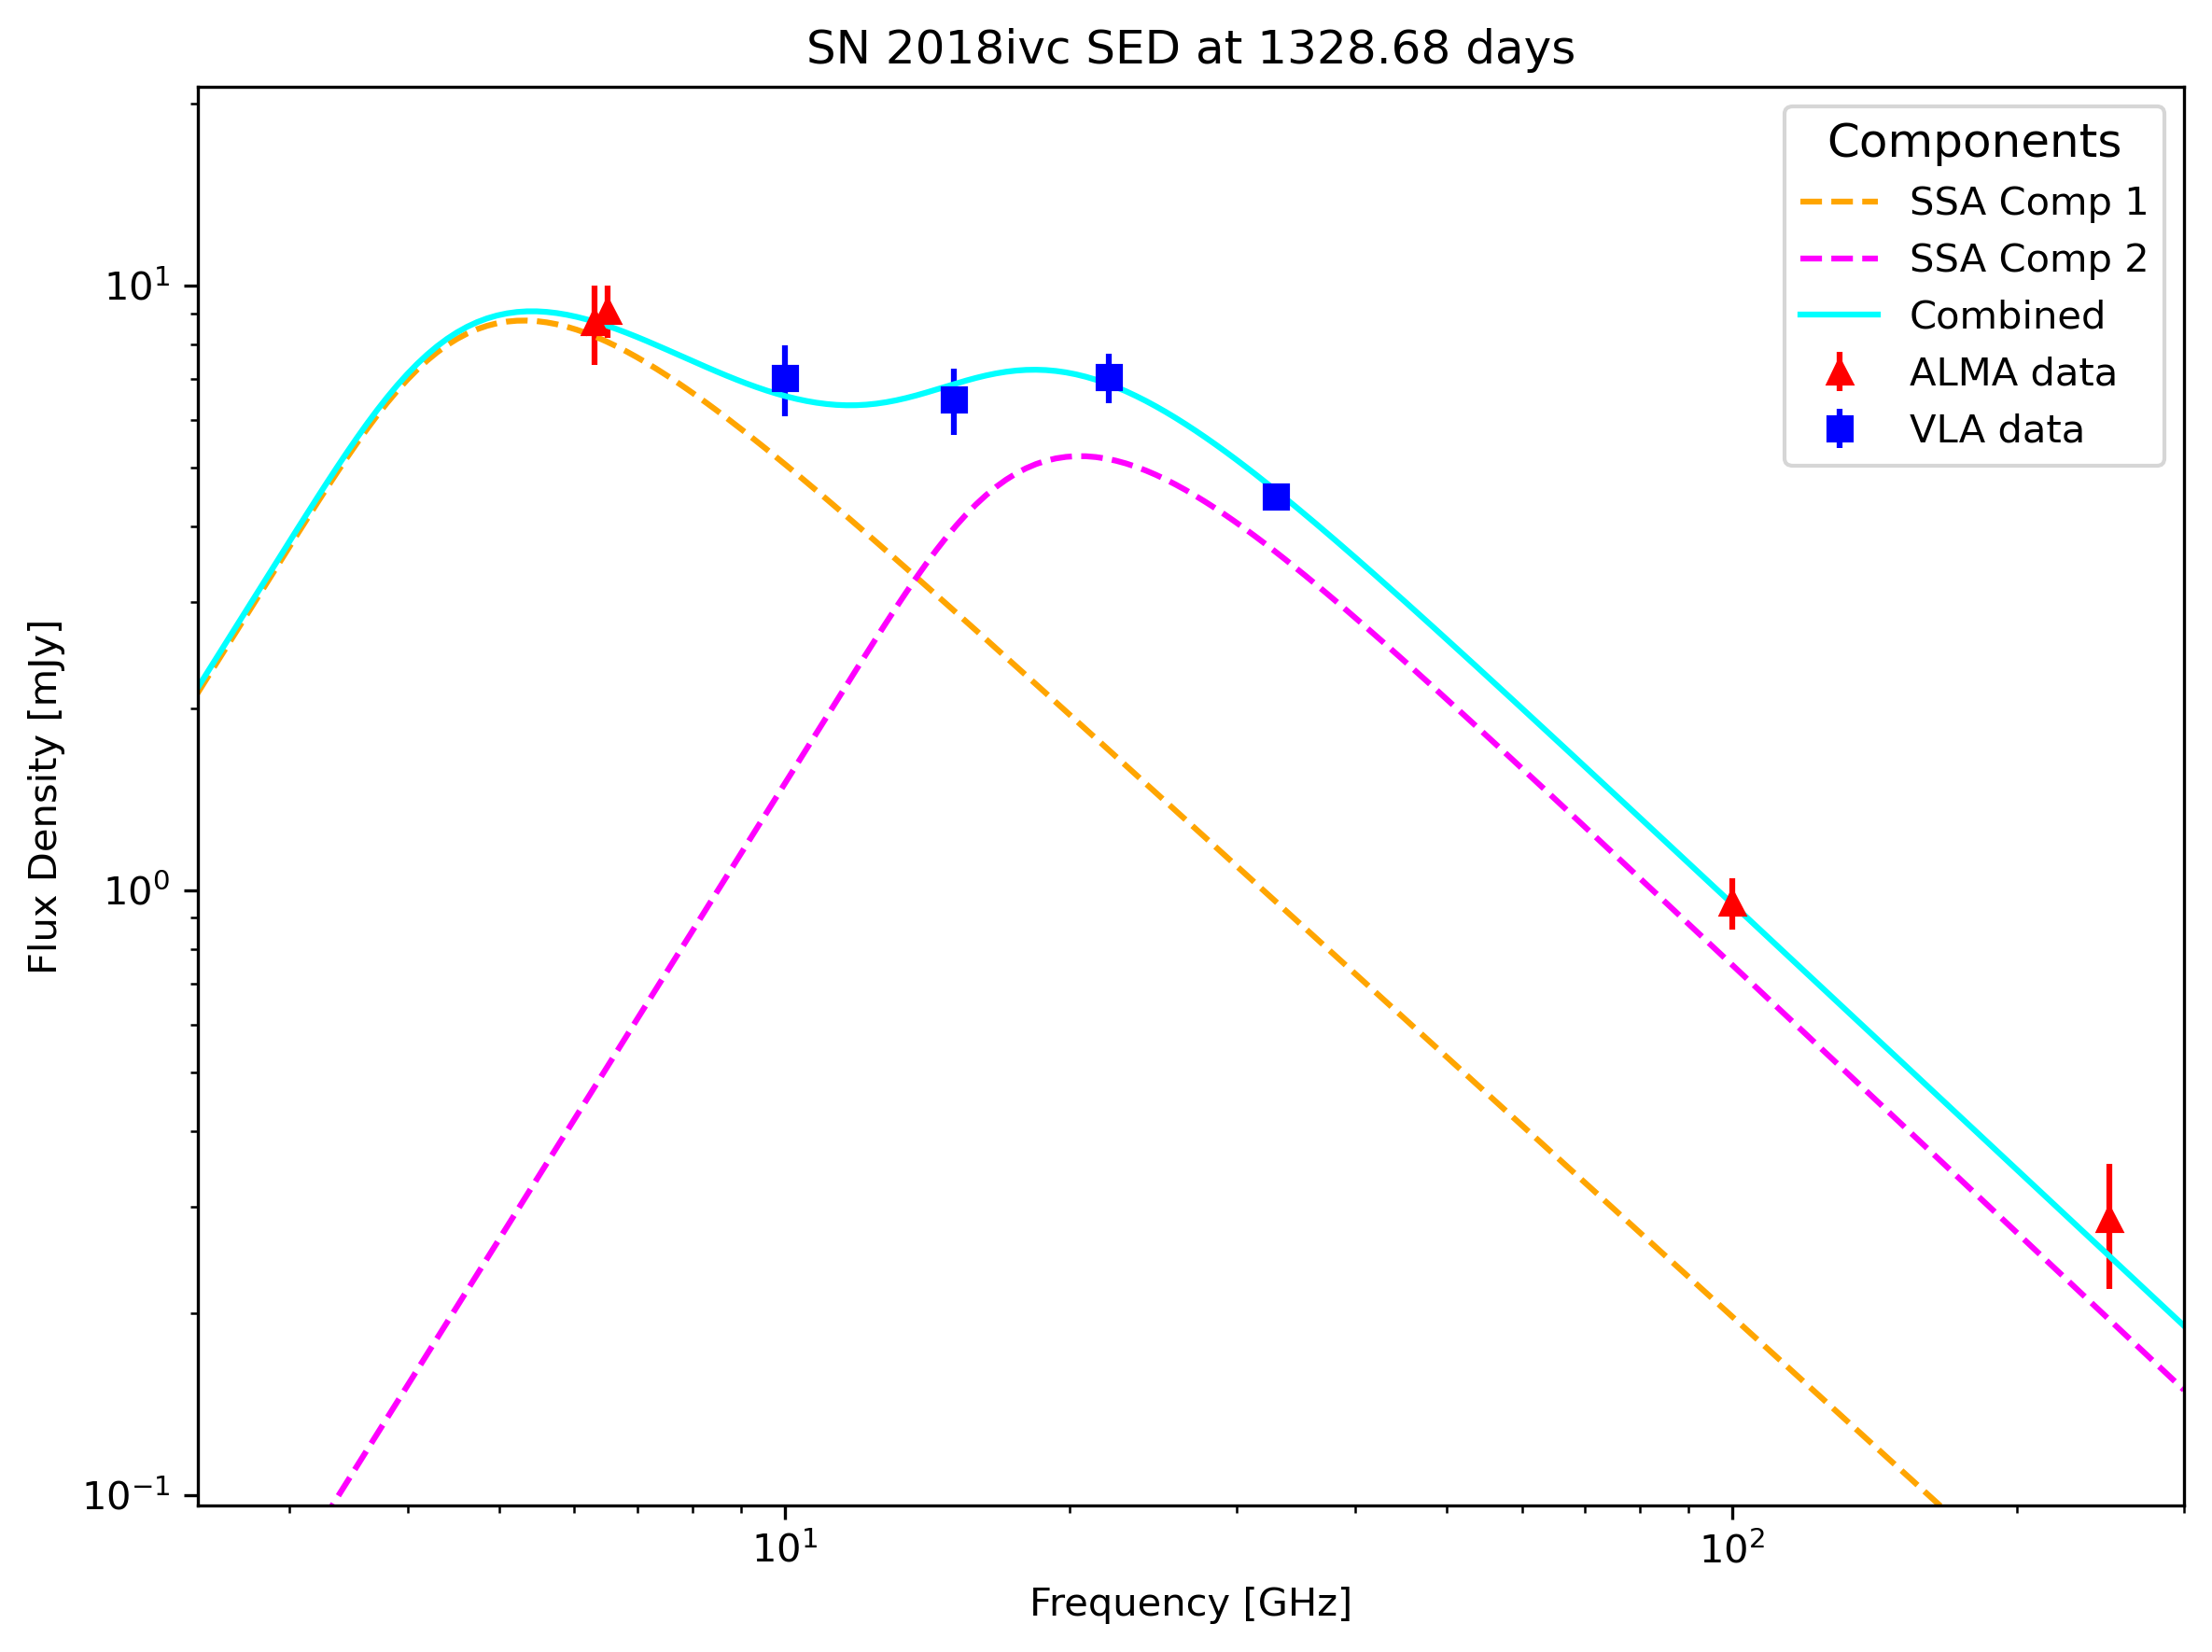

In [63]:
# 1300 day epoch:
functions.plot_single_epoch(1200, 1400, data, x_sed, y_lims, comp1=[75.0, 0.07, 3.85], 
                            comp2=[1.5, 15.0, 3.95], comp1_type="SSA", comp2_type="SSA")

# define params for each component
K1c1, K2c1, pc1 = [75.0, 0.07, 3.85]
K1c2, K2c2, pc2 = [1.5, 15.0, 3.95]

# define flux curves for each component
freq_range = np.logspace(np.log10(x_sed[0]), np.log10(x_sed[1]), 200)
flux_c1 = functions.F_SSA(freq_range, K1c1, K2c1, pc1)
flux_c2 = functions.F_SSA(freq_range, K1c2, K2c2, pc2)

# determine peak frequency and peak flux for each component
nu_peak_c1, Flux_peak_c1 = functions.find_peak_SSA(K1c1, K2c1, pc1, x_sed[0], x_sed[1])
nu_peak_c2, Flux_peak_c2 = functions.find_peak_SSA(K1c2, K2c2, pc2, x_sed[0], x_sed[1])

# calculate B and R for component 1
t_e1 = 1328.68 # days
R_c1 = functions.R_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
v_c1 = (R_c1 / t_e1) * cmday_to_kmsec # km/s
B_c1 = functions.B_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
print(f"Component 1: nu_p = {nu_peak_c1:.2f} GHz, F_p = {Flux_peak_c1:.2f} mJy, R = {R_c1:.2e} cm, v = {v_c1:.2e} km/s, B = {B_c1:.2e} G")

R_c2 = functions.R_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
v_c2 = (R_c2 / t_e1) * cmday_to_kmsec # km/s
B_c2 = functions.B_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
print(f"Component 2: nu_p = {nu_peak_c2:.2f} GHz, F_p = {Flux_peak_c2:.2f} mJy, R = {R_c2:.2e} cm, v = {v_c2:.2e} km/s, B = {B_c2:.2e} G")

Component 1: nu_p = 7.47 GHz, F_p = 6.90 mJy, R = 1.29e+17 cm, v = 8.78e+03 km/s, B = 4.09e-01 G
Component 2: nu_p = 26.51 GHz, F_p = 1.81 mJy, R = 1.98e+16 cm, v = 1.34e+03 km/s, B = 1.82e+00 G


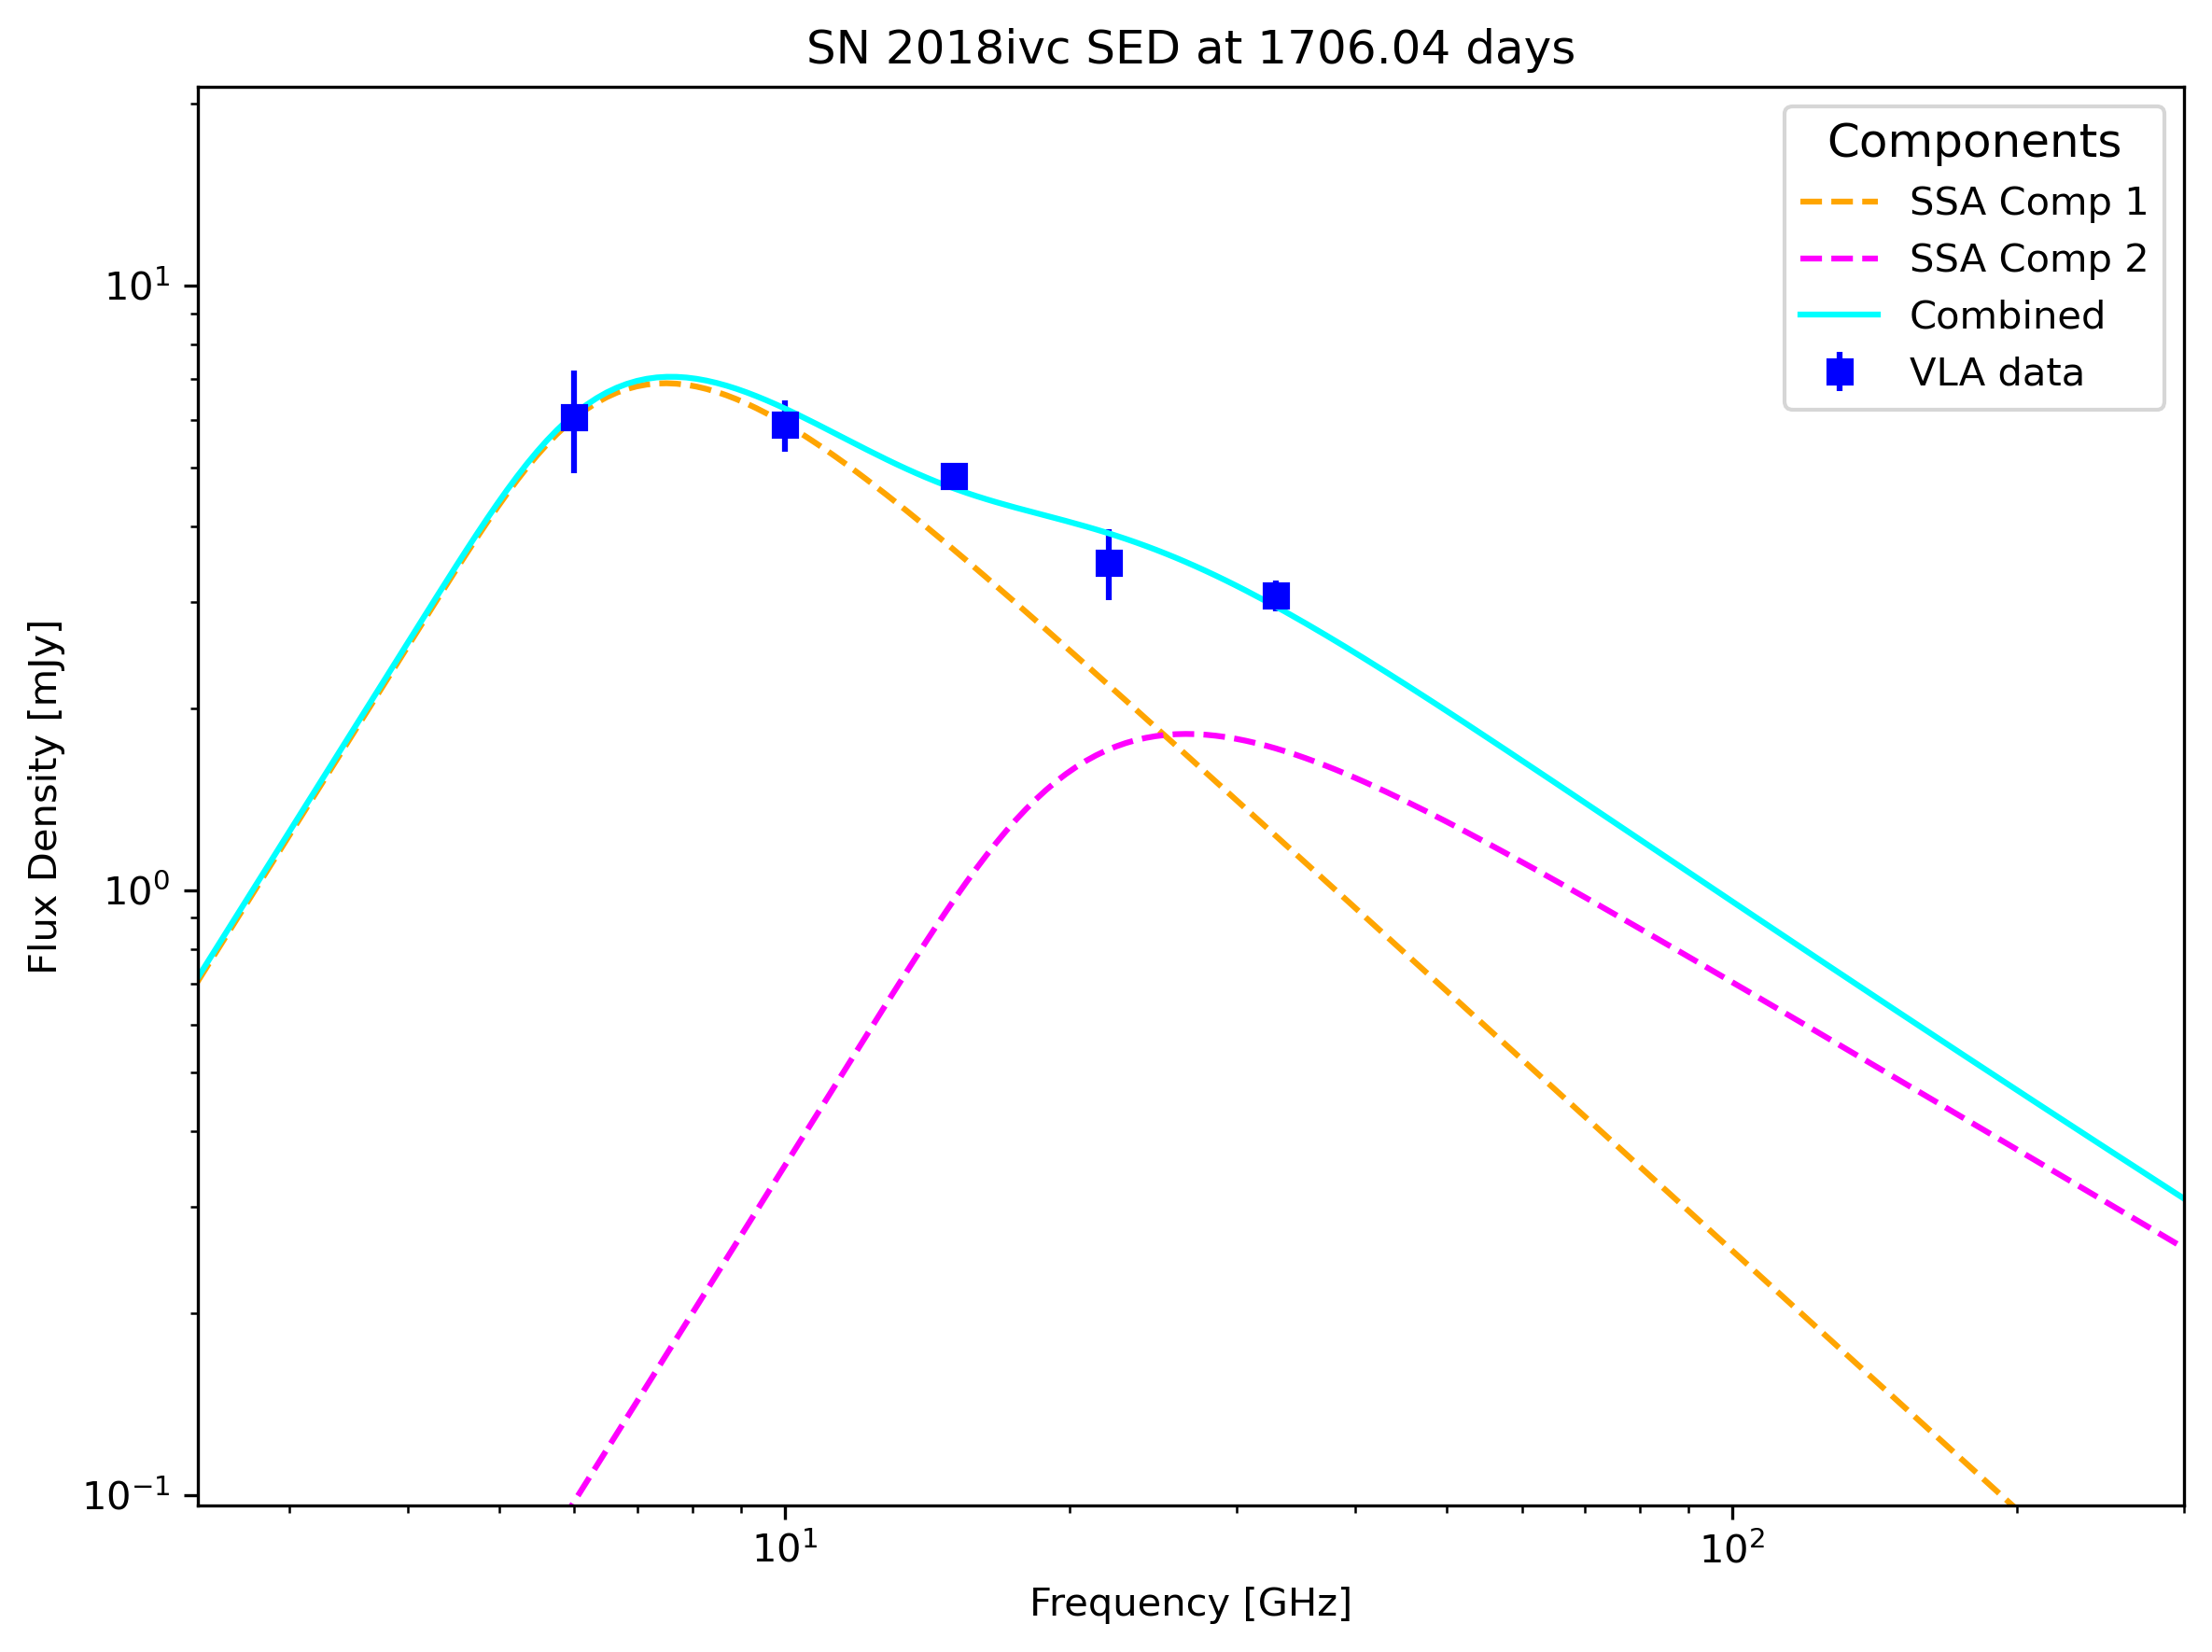

In [109]:
# 1700 day epoch:
functions.plot_single_epoch(1600, 1800, data, x_sed, y_lims, comp1=[25.0, 0.27, 3.85], comp2=[0.35, 17.0, 2.85],
                            comp1_type="SSA", comp2_type="SSA")

# define params for each component
K1c1, K2c1, pc1 = [25.0, 0.27, 3.85]
K1c2, K2c2, pc2 = [0.35, 17.0, 2.85]

# determine peak frequency and peak flux for each component
nu_peak_c1, Flux_peak_c1 = functions.find_peak_SSA(K1c1, K2c1, pc1, x_sed[0], x_sed[1])
nu_peak_c2, Flux_peak_c2 = functions.find_peak_SSA(K1c2, K2c2, pc2, x_sed[0], x_sed[1])

# calculate B and R for component 1
t_e2 = 1706.04 # days
R_c1 = functions.R_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
v_c1 = (R_c1 / t_e2) * cmday_to_kmsec # km/s
B_c1 = functions.B_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
print(f"Component 1: nu_p = {nu_peak_c1:.2f} GHz, F_p = {Flux_peak_c1:.2f} mJy, R = {R_c1:.2e} cm, v = {v_c1:.2e} km/s, B = {B_c1:.2e} G")

R_c2 = functions.R_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
v_c2 = (R_c2 / t_e2) * cmday_to_kmsec # km/s
B_c2 = functions.B_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
print(f"Component 2: nu_p = {nu_peak_c2:.2f} GHz, F_p = {Flux_peak_c2:.2f} mJy, R = {R_c2:.2e} cm, v = {v_c2:.2e} km/s, B = {B_c2:.2e} G")

Component 1: nu_p = 5.08 GHz, F_p = 11.76 mJy, R = 2.46e+17 cm, v = 1.32e+04 km/s, B = 2.67e-01 G
Component 2: nu_p = 23.95 GHz, F_p = 7.03 mJy, R = 4.16e+16 cm, v = 2.23e+03 km/s, B = 1.42e+00 G


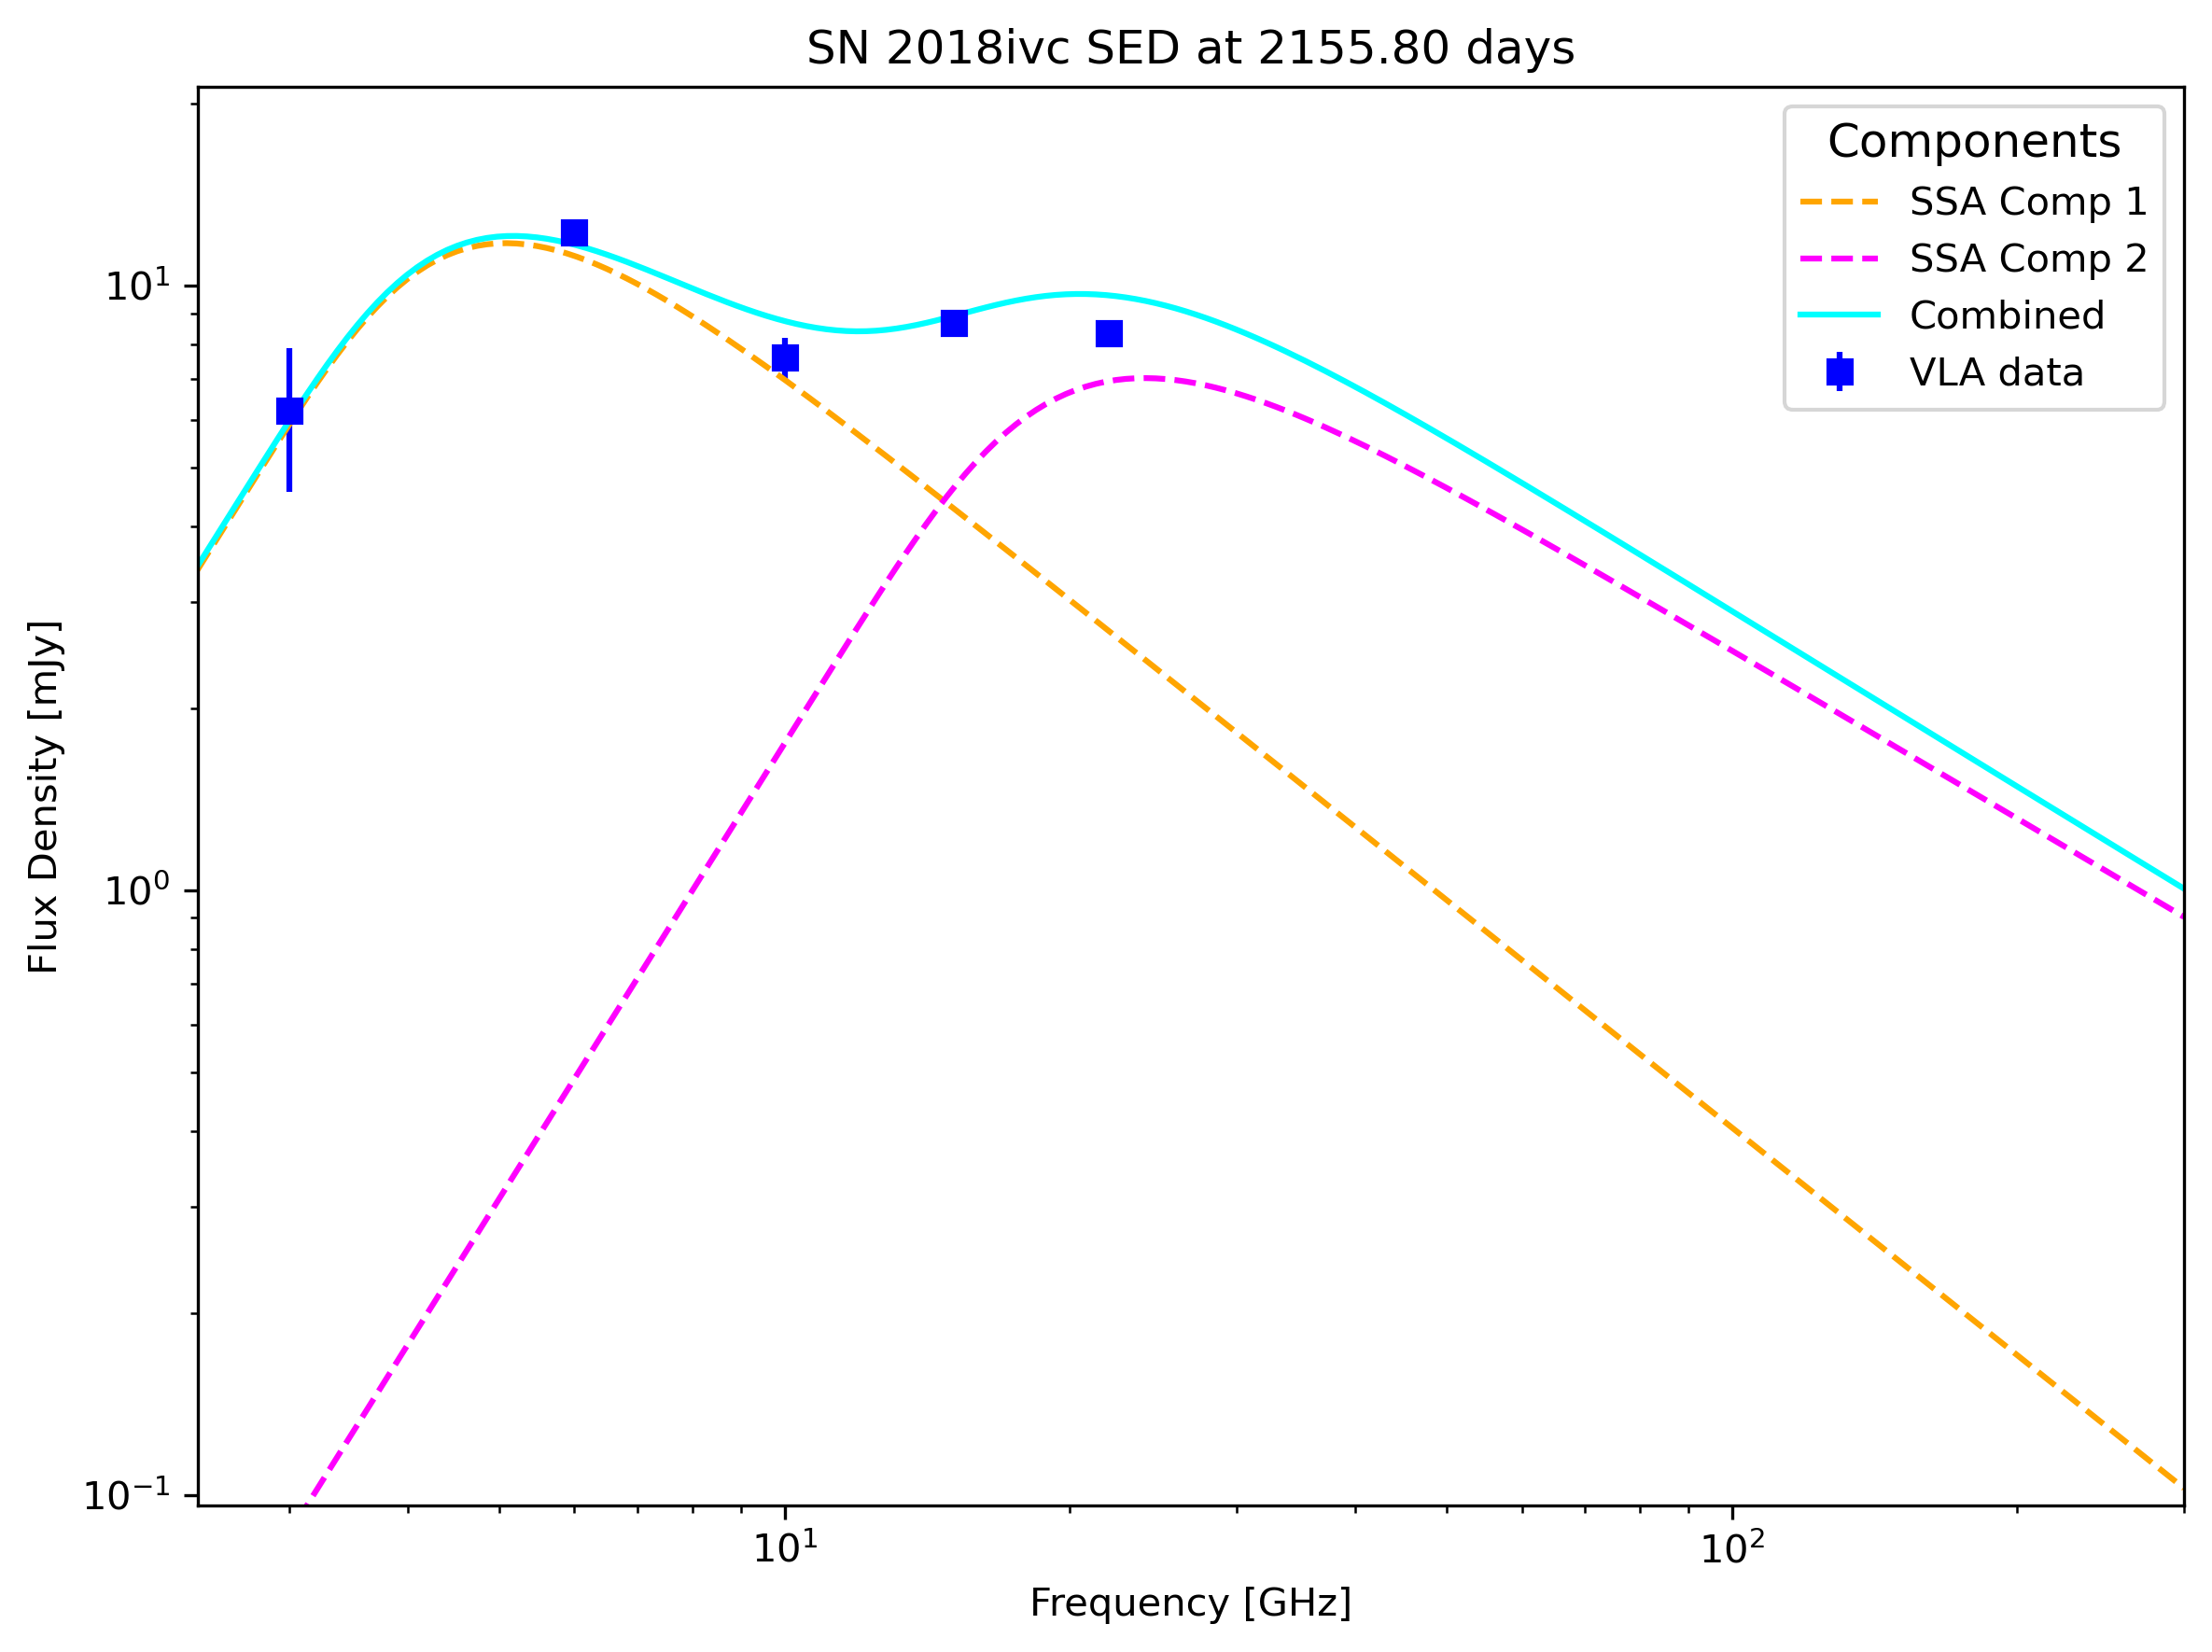

In [110]:
# 2100 day epoch:
functions.plot_single_epoch(2000, 2200, data, x_sed, y_lims, comp1=[120.0, 0.06, 3.5], comp2=[1.75, 12.0, 2.85],
                            comp1_type="SSA", comp2_type="SSA")

# define params for each component
K1c1, K2c1, pc1 = [120.0, 0.06, 3.5]
K1c2, K2c2, pc2 = [1.75, 12.0, 2.85]

# determine peak frequency and peak flux for each component
nu_peak_c1, Flux_peak_c1 = functions.find_peak_SSA(K1c1, K2c1, pc1, x_sed[0], x_sed[1])
nu_peak_c2, Flux_peak_c2 = functions.find_peak_SSA(K1c2, K2c2, pc2, x_sed[0], x_sed[1])

# calculate B and R for component 1
t_e3 = 2155.80 # days
R_c1 = functions.R_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
v_c1 = (R_c1 / t_e3) * cmday_to_kmsec # km/s
B_c1 = functions.B_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
print(f"Component 1: nu_p = {nu_peak_c1:.2f} GHz, F_p = {Flux_peak_c1:.2f} mJy, R = {R_c1:.2e} cm, v = {v_c1:.2e} km/s, B = {B_c1:.2e} G")

R_c2 = functions.R_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
v_c2 = (R_c2 / t_e3) * cmday_to_kmsec # km/s
B_c2 = functions.B_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
print(f"Component 2: nu_p = {nu_peak_c2:.2f} GHz, F_p = {Flux_peak_c2:.2f} mJy, R = {R_c2:.2e} cm, v = {v_c2:.2e} km/s, B = {B_c2:.2e} G")

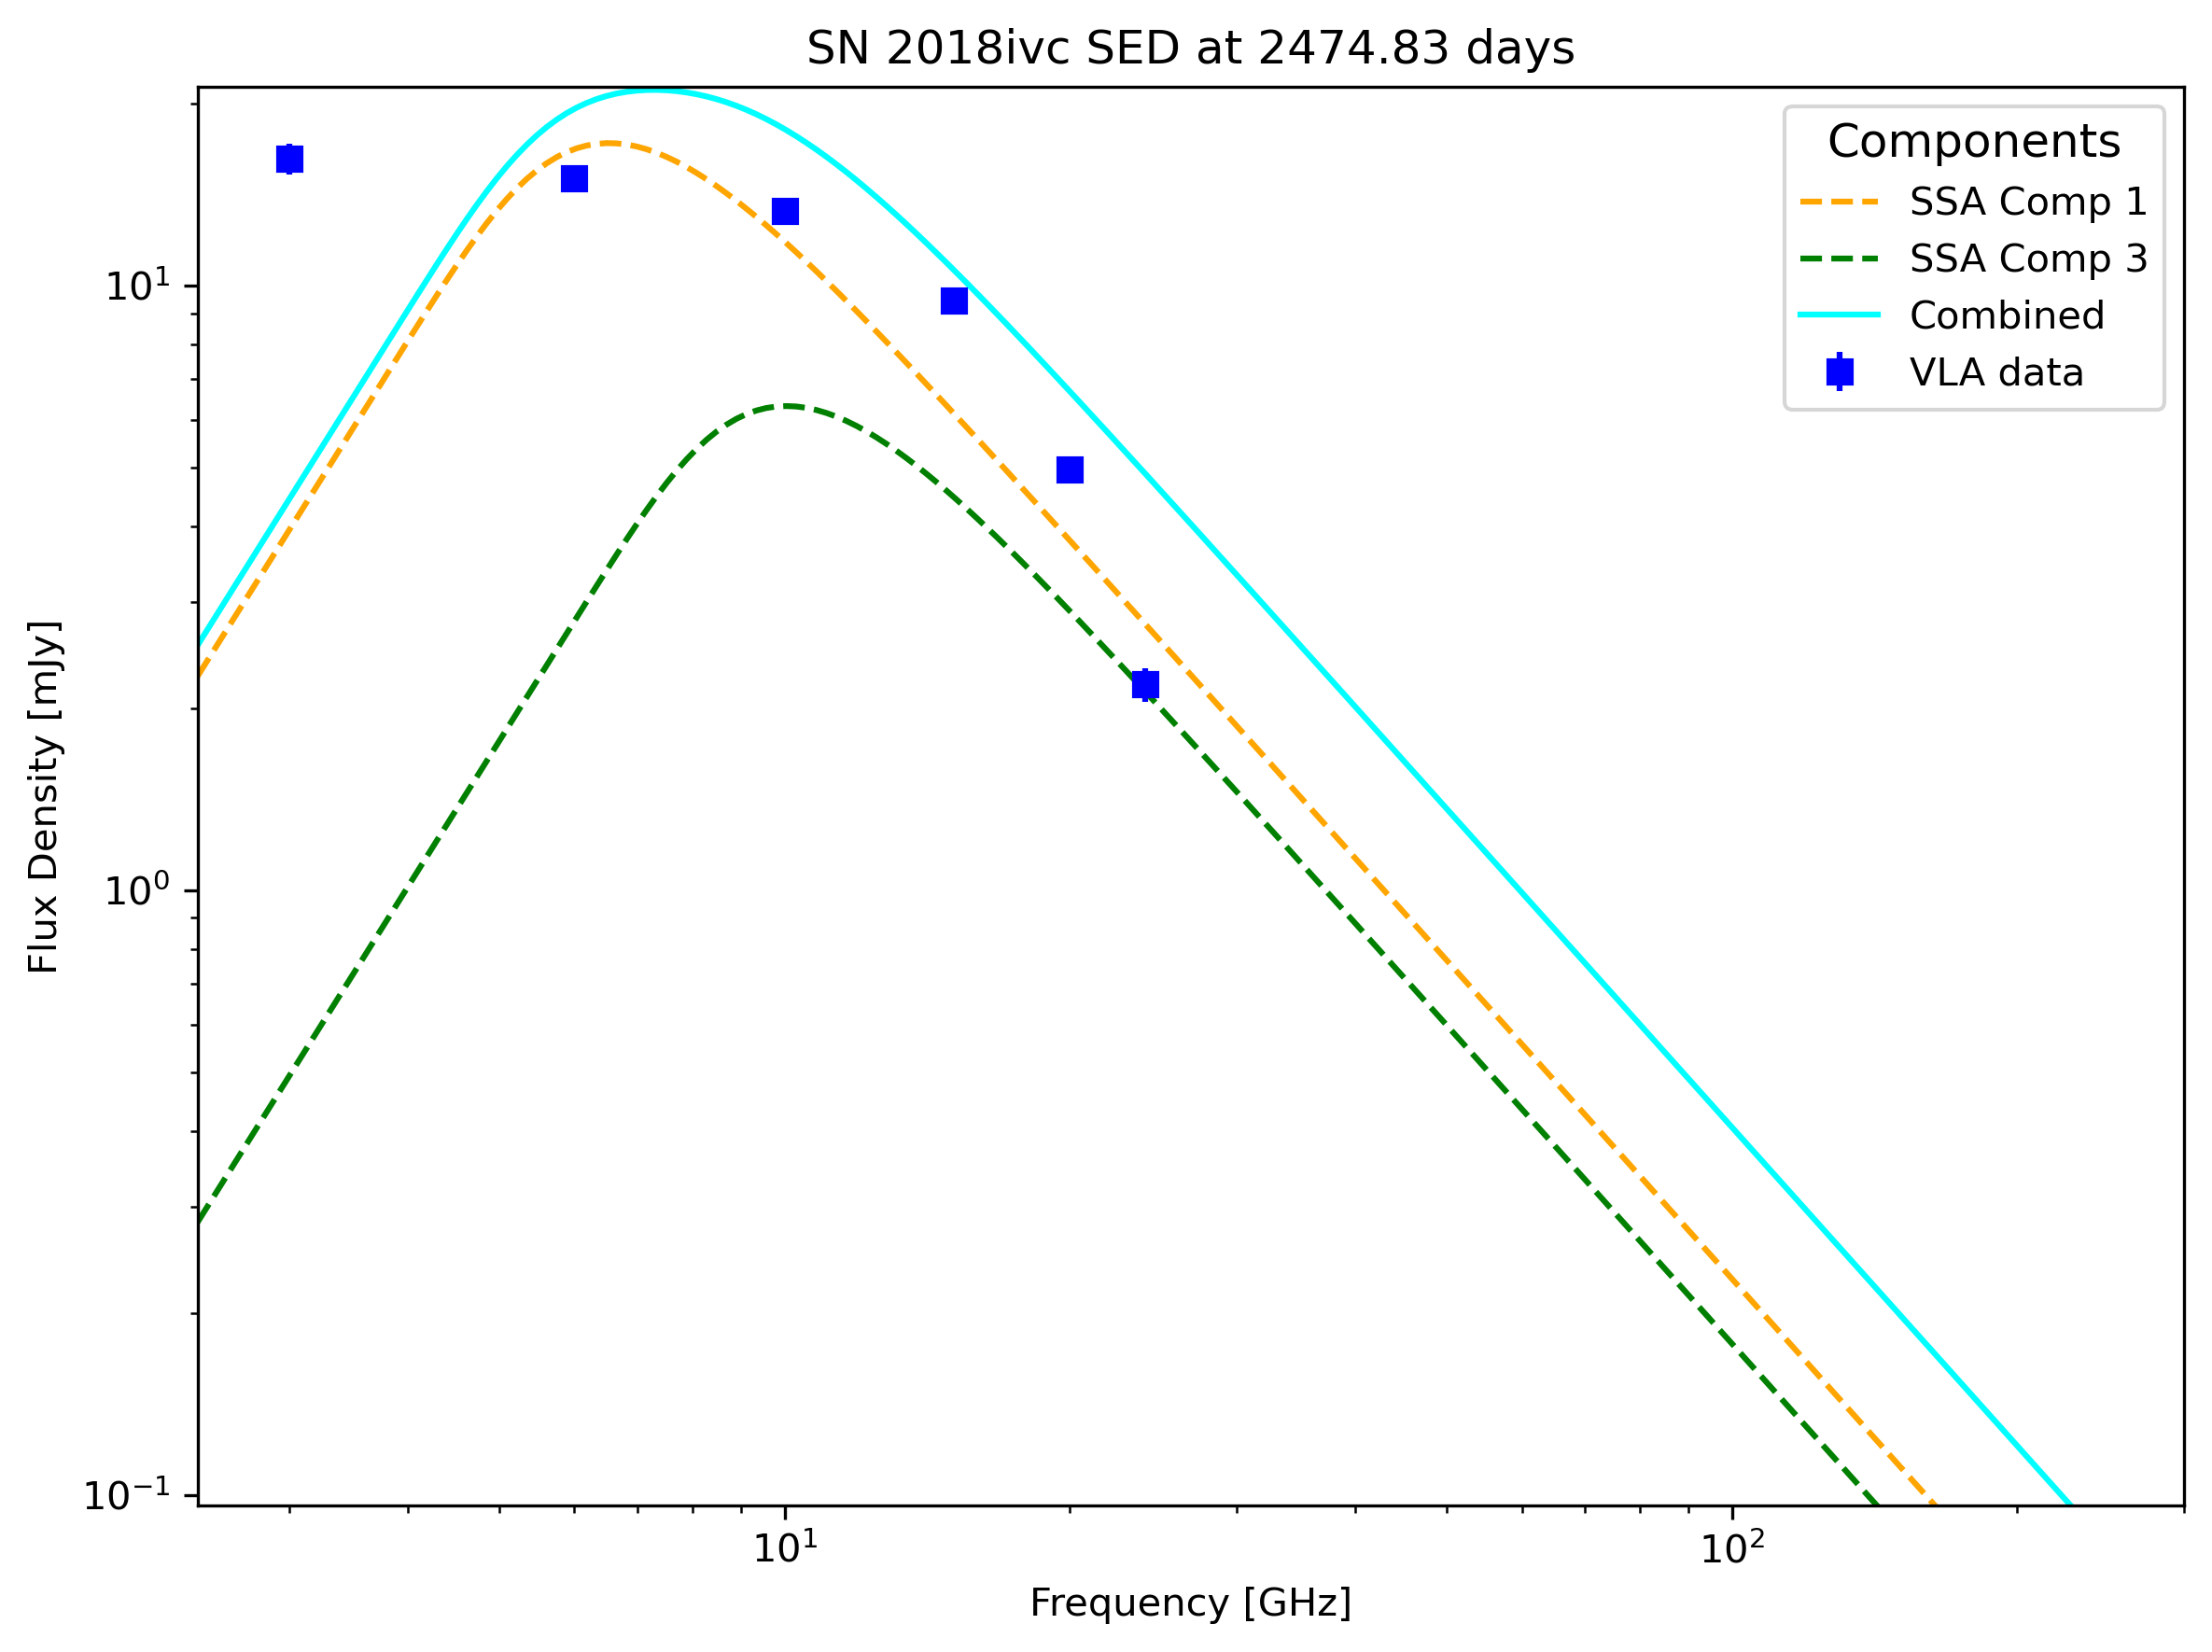

In [119]:
# 2100 day epoch:
functions.plot_single_epoch(2300, 2490, data, x_sed, y_lims, comp1=[80.0, 0.16, 4.5], comp1_type="SSA", 
                            comp3=[10.0, 1.0, 4.5], comp3_type="SSA")
#functions.plot_single_epoch(2300, 2490, data, (1.0, 100), (1.0, 30), comp1=[350.0, 0.03, 2.85], comp2=[5.0, 0.25, 3.5])

# # define params for each component
# K1c1, K2c1, pc1 = [120.0, 0.06, 3.5]
# K1c2, K2c2, pc2 = [1.75, 12.0, 2.85]

# # determine peak frequency and peak flux for each component
# nu_peak_c1, Flux_peak_c1 = functions.find_peak_SSA(K1c1, K2c1, pc1, x_sed[0], x_sed[1])
# nu_peak_c2, Flux_peak_c2 = functions.find_peak_SSA(K1c2, K2c2, pc2, x_sed[0], x_sed[1])

# # calculate B and R for component 1
# t_e3 = 2155.80 # days
# R_c1 = functions.R_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
# v_c1 = (R_c1 / t_e3) * cmday_to_kmsec # km/s
# B_c1 = functions.B_peak_SSA(pc1, Flux_peak_c1, D, nu_peak_c1, F_p_scale, D_scale, nu_p_scale)
# print(f"Component 1: nu_p = {nu_peak_c1:.2f} GHz, F_p = {Flux_peak_c1:.2f} mJy, R = {R_c1:.2e} cm, v = {v_c1:.2e} km/s, B = {B_c1:.2e} G")

# R_c2 = functions.R_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
# v_c2 = (R_c2 / t_e3) * cmday_to_kmsec # km/s
# B_c2 = functions.B_peak_SSA(pc2, Flux_peak_c2, D, nu_peak_c2, F_p_scale, D_scale, nu_p_scale)
# print(f"Component 2: nu_p = {nu_peak_c2:.2f} GHz, F_p = {Flux_peak_c2:.2f} mJy, R = {R_c2:.2e} cm, v = {v_c2:.2e} km/s, B = {B_c2:.2e} G")

# Everything below this is basically scratch from trying out the emcee fitting from an earlier era...deal with it later 

# Early stage
Model the fluxes from 0-1300 days, including all the previously published ALMA data

In [4]:
data_early = data[((data['phase'] == 1300) & (data['flux'] > 0.0))]

In [5]:
# get initial guess for parameters from simple one-epoch fit (1300 days)
mask_1300_early = data_early['phase'] == 1300
nu_1300_early = data_early['freq'][mask_1300_early]
F_1300_early = data_early['flux'][mask_1300_early]
Ferr_1300_early = data_early['flux_err'][mask_1300_early]

# get the spectral index alpha
lognu_early = np.log10(nu_1300_early)
logF_early  = np.log10(F_1300_early)
alpha_early, logA_early = np.polyfit(lognu_early, logF_early, 1)   # F ~ A * nu^alpha

p_init_early = 1 - 2*alpha_early
print("alpha_early ~", alpha_early, "=> p_init_early ~", p_init_early)

# Fit F_SSA (no time) to the 1300-day data
p0_simple_early   = [np.max(F_1300_early), 10.0, p_init_early]  # K1, K2, p
bounds_simple_early = ([0.0, 0.0, 1.0], [np.inf, 1e6, 4.0])

(K1_s_early, K2_s_early, p_s_early), cov_s_early = curve_fit(
    functions.F_SSA,
    nu_1300_early,
    F_1300_early,
    p0=p0_simple_early,
    bounds=bounds_simple_early,
    sigma=Ferr_1300_early,
    absolute_sigma=True
)

print("Simple SSA fit (early):\nK1 ~ ", K1_s_early, "\nK2 ~ ", K2_s_early, "\np ~ ", p_s_early)

alpha_early ~ -0.5707041199675404 => p_init_early ~ 2.141408239935081
Simple SSA fit (early):
K1 ~  30.528739980889384 
K2 ~  0.2887153350101707 
p ~  2.95909979998574


In [6]:
# once I have more than one epoch, can get intial guesses for a and b

In [7]:
# use the initial guesses from one epoch and light curve fits
initial_guess_early = [K1_s_early, K2_s_early, p_s_early, 0.0, 0.0]
bounds_early = (
    [0.0,   0.0,  1.0, -10.0, -10.0],   # lower bounds
    [np.inf, np.inf, 4.0,  10.0,  10.0] # upper bounds
)

results_early = functions.calc_params(data_early, functions.F_SSA_time, initial_guess_early, bounds_early)

K1_early = results_early['K1'][0]
K2_early = results_early['K2'][0]
p_early  = results_early['p'][0]
a_early  = results_early['a'][0]
b_early  = results_early['b'][0]

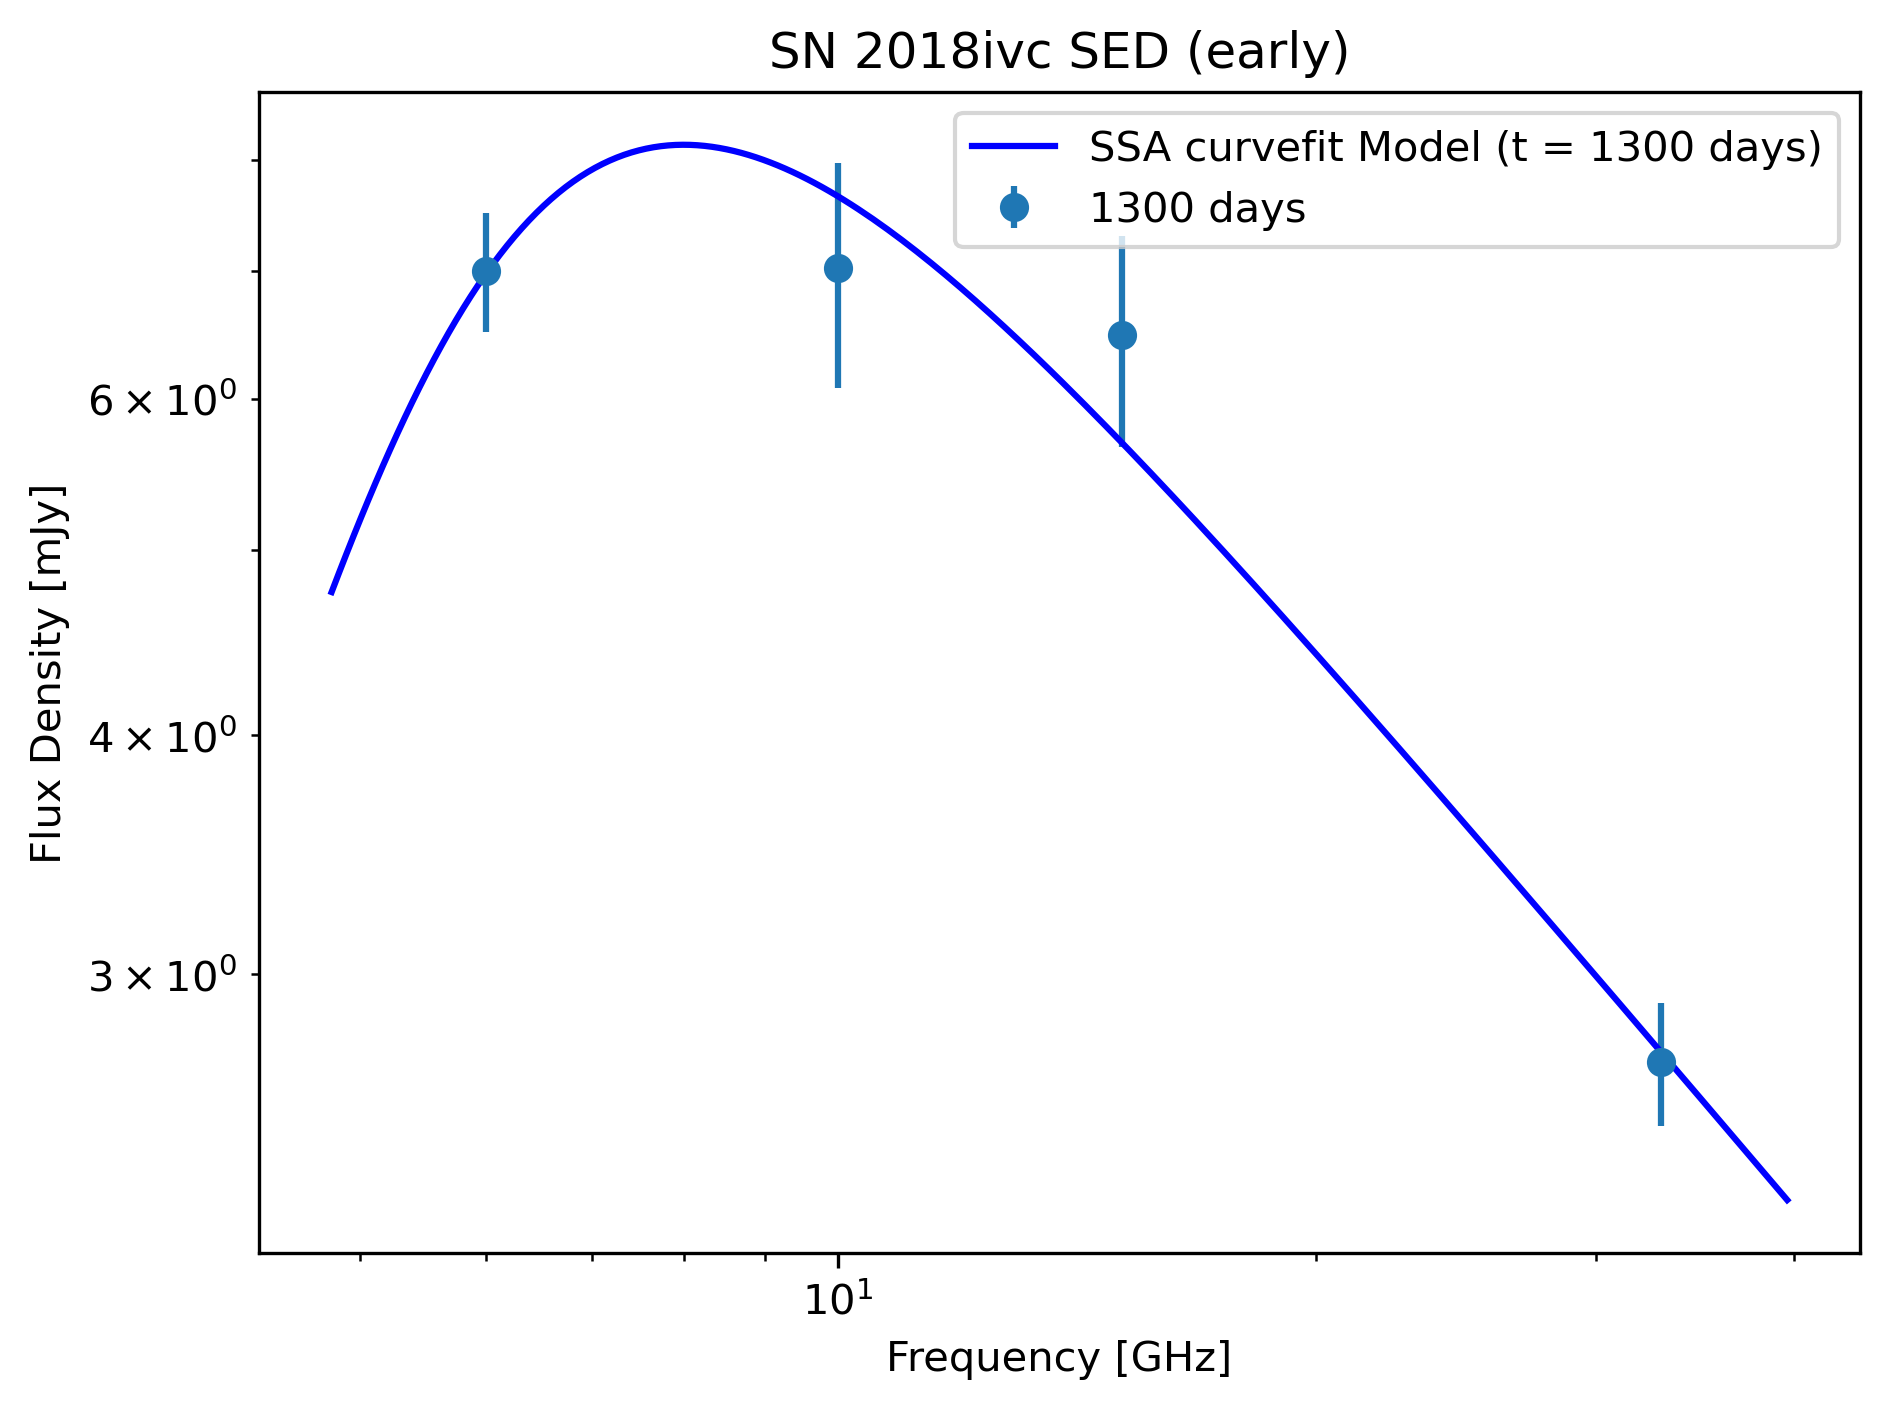

In [8]:
# plot the initial guess SED at a specific epoch
t_plot_early = 1300.0 

# Frequency grid for the model SED 
fmin_early = data_early['freq'].min() * 0.8
fmax_early = data_early['freq'].max() * 1.2
freq_model_early = np.logspace(np.log10(fmin_early), np.log10(fmax_early), 200)

# Evaluate the SSA model using the fitted parameters
flux_model_early = functions.F_SSA_time(freq_model_early, t_plot_early, K1_early, K2_early, p_early, a_early, b_early)

plt.figure(dpi=300)

# Plot the data, color-coded by phase
for phase_val_early in np.unique(data_early['phase']):
    mask_phase_early = data_early['phase'] == phase_val_early
    plt.errorbar(
        data_early['freq'][mask_phase_early],
        data_early['flux'][mask_phase_early],
        yerr=data_early['flux_err'][mask_phase_early],
        fmt='o',
        label=f'{phase_val_early:.0f} days'
    )

# Plot the model SED
plt.plot(freq_model_early, flux_model_early, 'b-', label=f'SSA curvefit Model (t = {t_plot_early:.0f} days)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Density [mJy]')
plt.title('SN 2018ivc SED (early)')
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
# use the initial guesses from curve fitting to initialize MCMC (early)
sampler_early = functions.run_mcmc([K1_early, K2_early, p_early, a_early, b_early], data_early, niters=2000, nwalkers=400)
chain_early = sampler_early.chain

Computation time: 108.458039 s


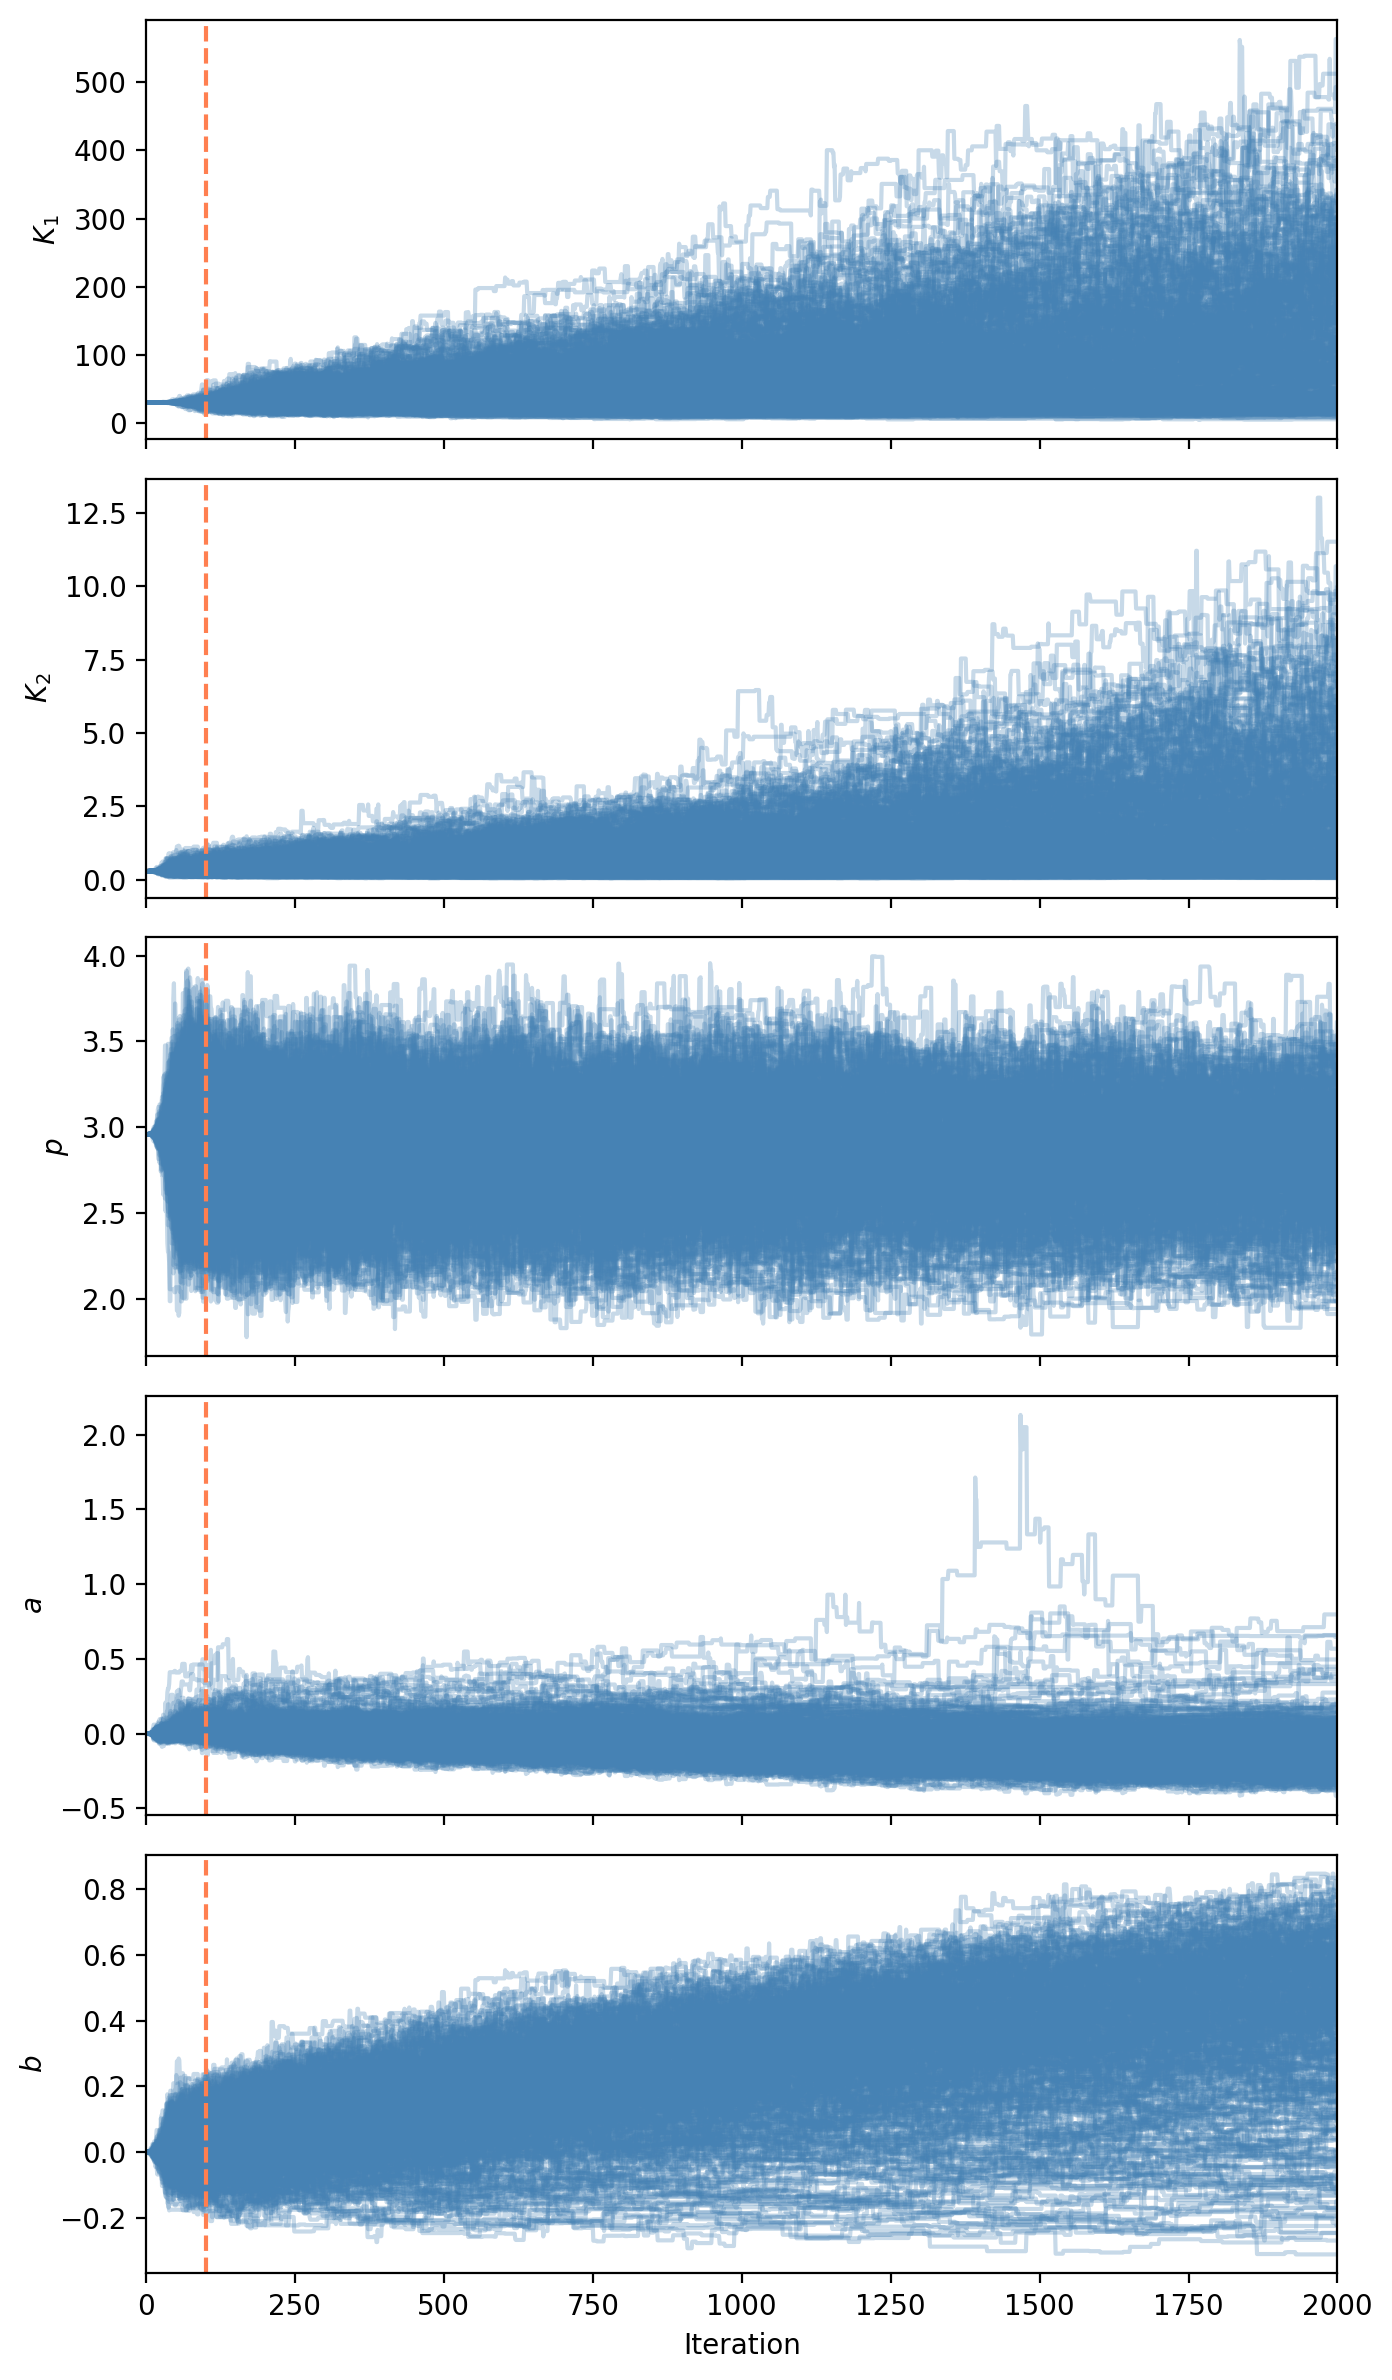

In [10]:
# plot the chains to determine burn in phase
chain_cut_early = 100
functions.make_chain_plot(chain_early, chain_cut_early)

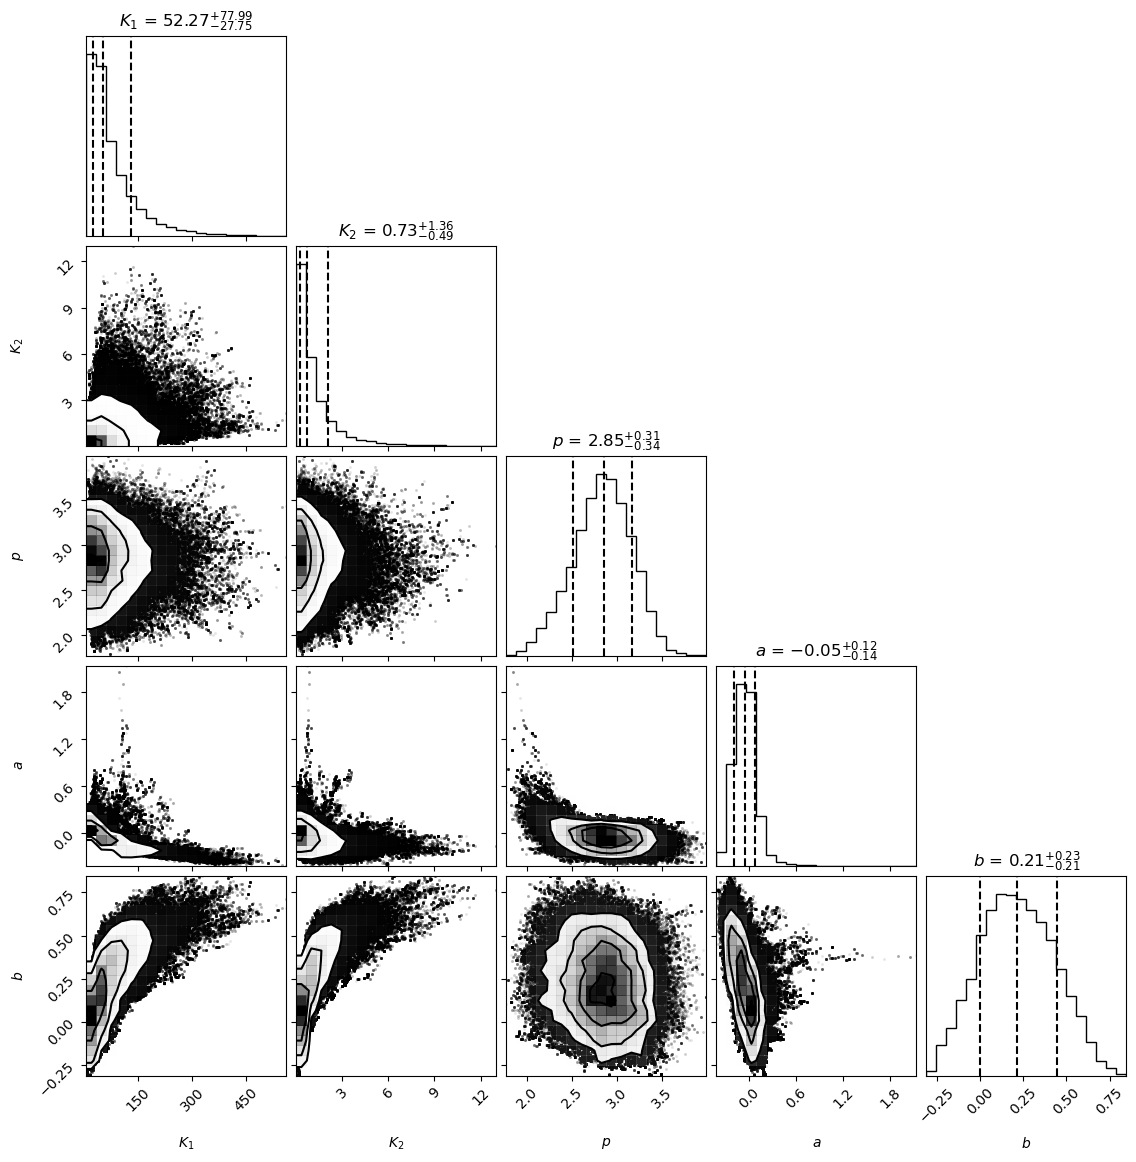

In [11]:
# make corner plots and get the best fit values and uncertainties
good_chain_early = chain_early[:, chain_cut_early:, :]
functions.make_corner_plot(good_chain_early)
best_params_early = functions.get_best_params(good_chain_early)

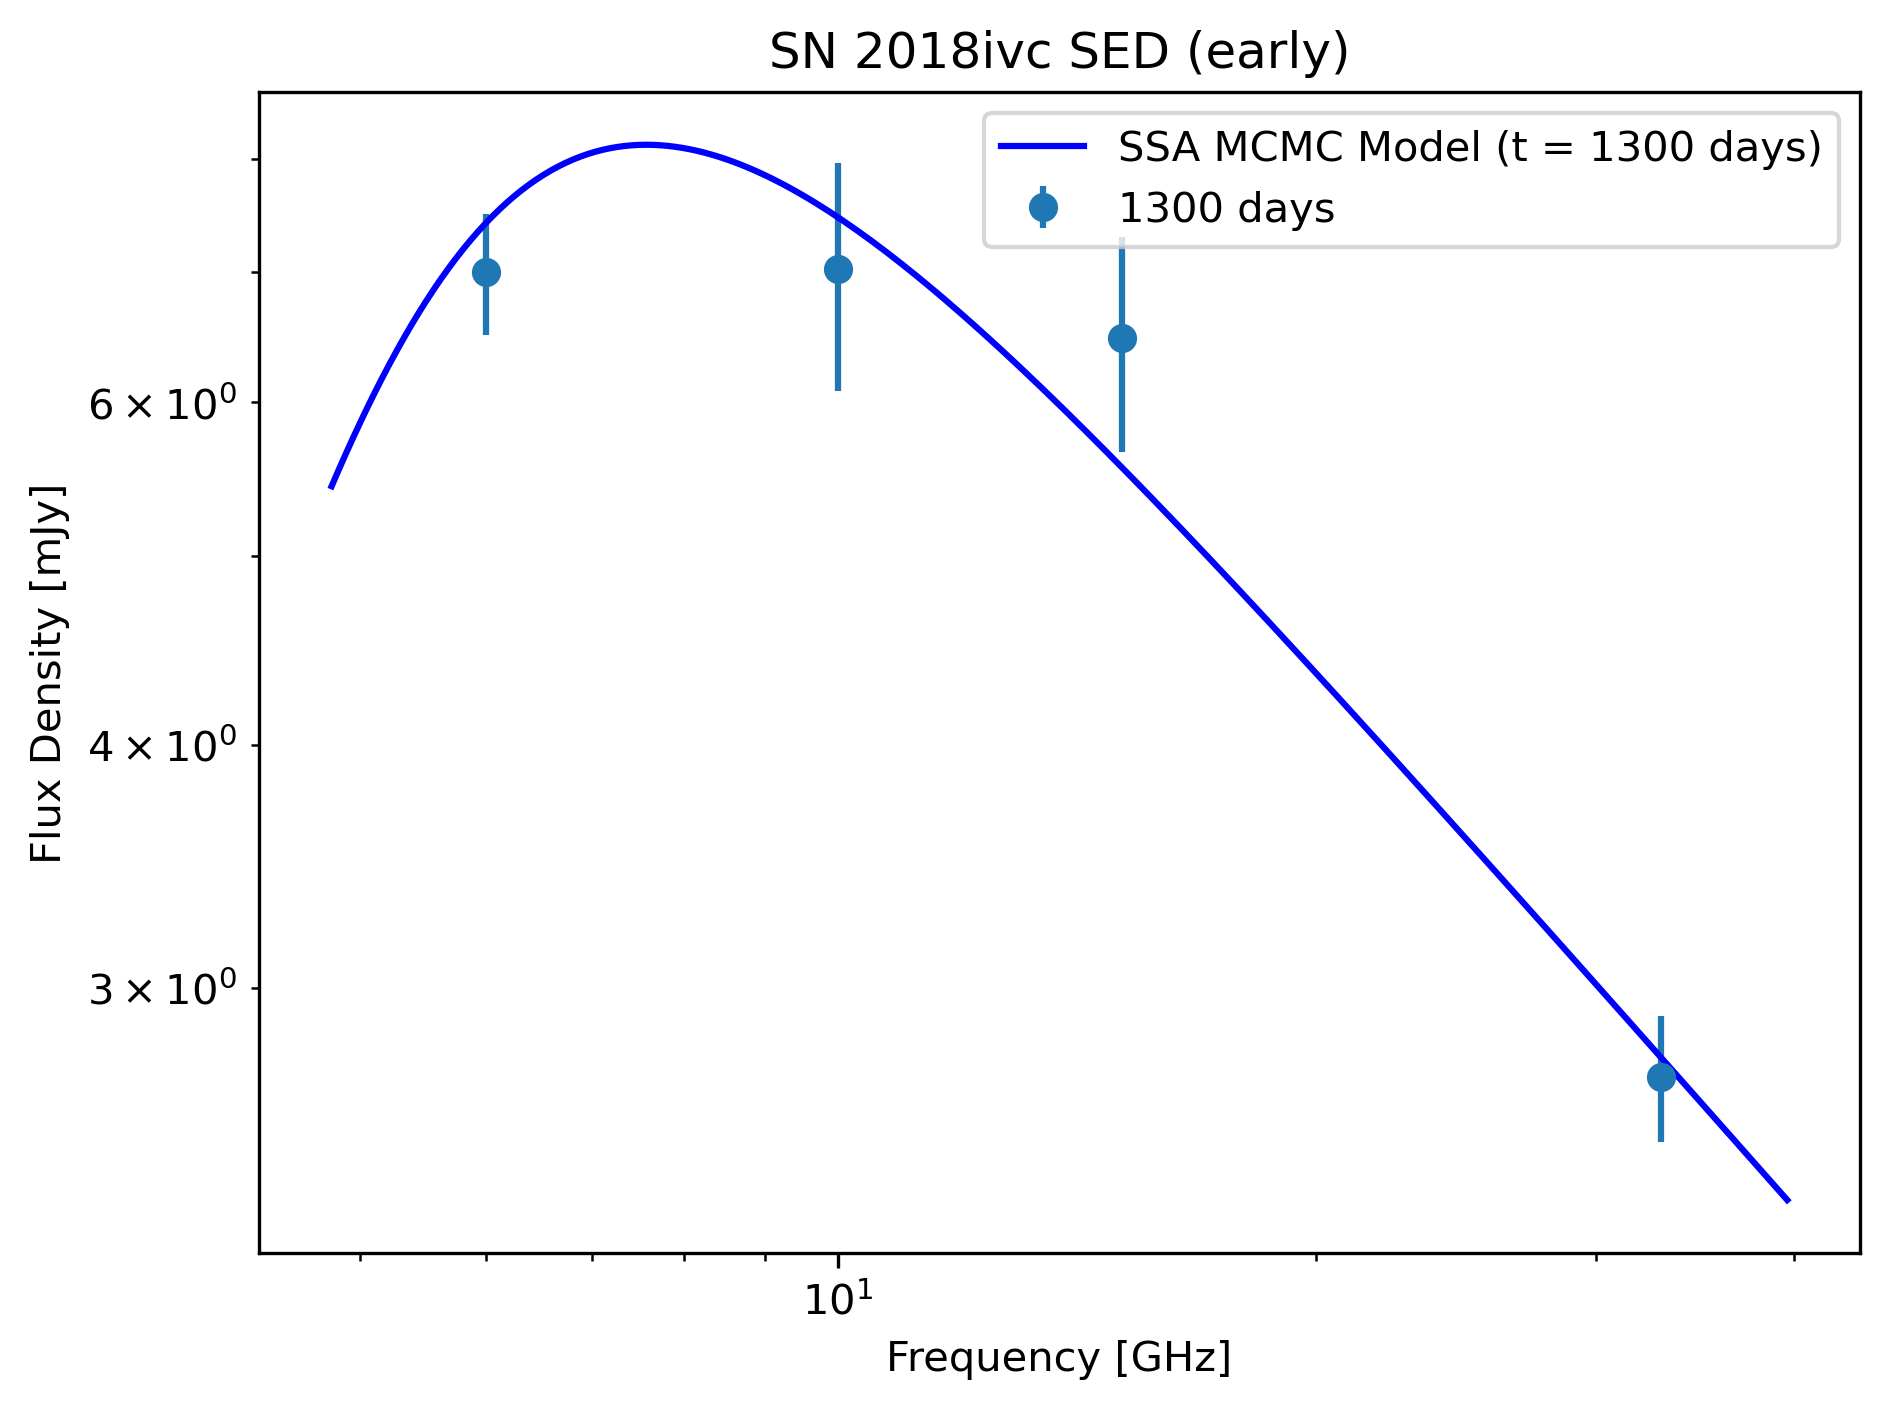

In [12]:

# now plot the MCMC model and data (early)
t_plot_early = 1300.0 

# Frequency grid for the model SED 
fmin_early = data_early['freq'].min() * 0.8
fmax_early = data_early['freq'].max() * 1.2
freq_model_early = np.logspace(np.log10(fmin_early), np.log10(fmax_early), 200)

# unpack best-fit parameters
K1_best_early, K1_err_early, K1_uncertainty_early = best_params_early['$K_1$']
K2_best_early, K2_err_early, K2_uncertainty_early = best_params_early['$K_2$']
p_best_early, p_err_early, p_uncertainty_early = best_params_early['$p$']
a_best_early, a_err_early, a_uncertainty_early = best_params_early['$a$']
b_best_early, b_err_early, b_uncertainty_early = best_params_early['$b$']

# Evaluate the SSA model using the fitted parameters
flux_model_MCMC_early = functions.F_SSA_time(freq_model_early, t_plot_early, K1_best_early, K2_best_early, p_best_early, a_best_early, b_best_early)

plt.figure(dpi=300)

# Plot the data, color-coded by phase
for phase_val_early in np.unique(data_early['phase']):
    mask_phase_early = data_early['phase'] == phase_val_early
    plt.errorbar(
        data_early['freq'][mask_phase_early],
        data_early['flux'][mask_phase_early],
        yerr=data_early['flux_err'][mask_phase_early],
        fmt='o',
        label=f'{phase_val_early:.0f} days'
    )

# Plot the model SED
plt.plot(freq_model_early, flux_model_MCMC_early, 'b-', label=f'SSA MCMC Model (t = {t_plot_early:.0f} days)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Density [mJy]')
plt.title('SN 2018ivc SED (early)')
plt.legend()
plt.tight_layout()
plt.show()

# Late stage
Model just the fluxes from 2100-2400 days. Start with just the 2400 day values, as that is what I have, but add the 2100 when I get them.

In [13]:
data_late = data[((data['phase'] >= 2000) & (data['flux'] > 0))]

In [14]:
# get initial guess for parameters from simple one-epoch fit (2400 days)
mask_2400_late = data_late['phase'] == 2400
nu_2400_late = data_late['freq'][mask_2400_late]
F_2400_late = data_late['flux'][mask_2400_late]
Ferr_2400_late = data_late['flux_err'][mask_2400_late]

# get the spectral index alpha
lognu_late = np.log10(nu_2400_late)
logF_late  = np.log10(F_2400_late)
alpha_late, logA_late = np.polyfit(lognu_late, logF_late, 1)   # F ~ A * nu^alpha

p_init_late = 1 - 2*alpha_late
print("alpha_late ~", alpha_late, "=> p_init_late ~", p_init_late)

# Fit F_SSA (no time) to the 2400-day data
p0_simple_late   = [np.max(F_2400_late), 10.0, p_init_late]  # K1, K2, p
bounds_simple_late = ([0.0, 0.0, 1.0], [np.inf, 1e6, 4.0])

(K1_s_late, K2_s_late, p_s_late), cov_s_late = curve_fit(
    functions.F_SSA,
    nu_2400_late,
    F_2400_late,
    p0=p0_simple_late,
    bounds=bounds_simple_late,
    sigma=Ferr_2400_late,
    absolute_sigma=True
)

print("Simple SSA fit (late):\nK1 ~ ", K1_s_late, "\nK2 ~ ", K2_s_late, "\np ~ ", p_s_late)

alpha_late ~ -0.8279917878318439 => p_init_late ~ 2.655983575663688
Simple SSA fit (late):
K1 ~  64.58232555689787 
K2 ~  0.23586619229588174 
p ~  3.809096122926624


In [15]:
# get intial guesses for a and b

# 6 GHz ~ optically thick at late times -> F ∝ t^a
a_init_late = functions.time_slope_for_freq(data, 6.0)

# 10 GHz ~ optically thin at late times -> F ∝ t^{-b}
slope_10_late = functions.time_slope_for_freq(data, 10.0)
b_init_late = -slope_10_late

print(f"a_init_late ~ {a_init_late:.3f}, b_init_late ~ {b_init_late:.3f}")

initial_guess_late = [K1_s_late, K2_s_late, p_s_late, a_init_late, b_init_late]

a_init_late ~ 1.227, b_init_late ~ -0.809


In [16]:
# use the initial guesses from one epoch and light curve fits
initial_guess_late = [K1_s_late, K2_s_late, p_s_late, a_init_late, b_init_late]
bounds_late = (
    [0.0,   0.0,  1.0, -10.0, -10.0],   # lower bounds
    [np.inf, np.inf, 4.0,  10.0,  10.0] # upper bounds
)

results_late = functions.calc_params(data_late, functions.F_SSA_time, initial_guess_late, bounds_late)

K1_late = results_late['K1'][0]
K2_late = results_late['K2'][0]
p_late  = results_late['p'][0]
a_late  = results_late['a'][0]
b_late  = results_late['b'][0]

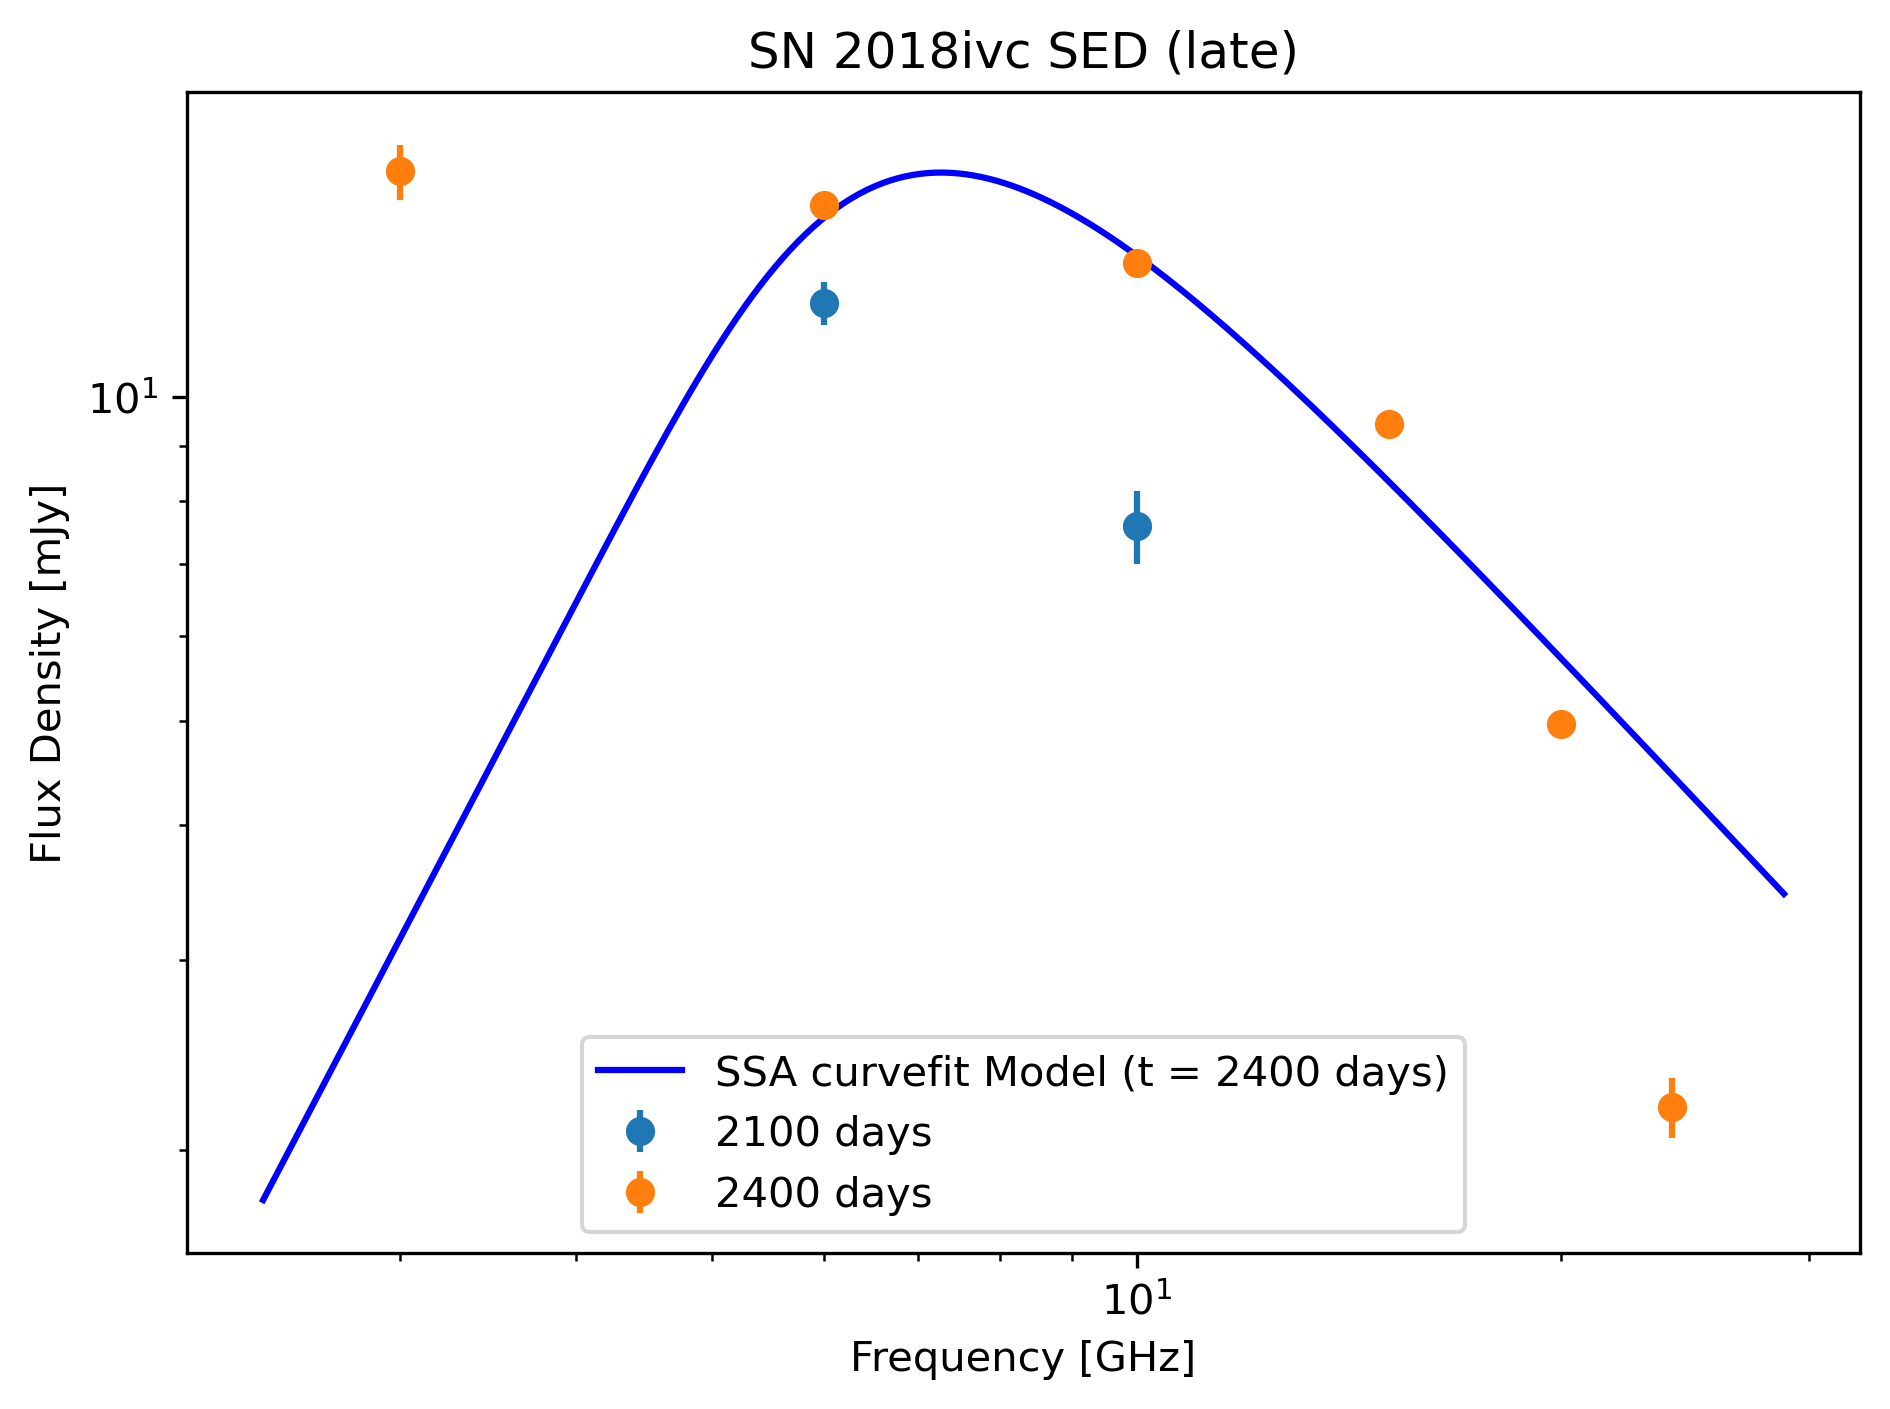

In [17]:
# plot the initial guess SED at a specific epoch
t_plot_late = 2400.0 

# Frequency grid for the model SED 
fmin_late = data_late['freq'].min() * 0.8
fmax_late = data_late['freq'].max() * 1.2
freq_model_late = np.logspace(np.log10(fmin_late), np.log10(fmax_late), 200)

# Evaluate the SSA model using the fitted parameters
flux_model_late = functions.F_SSA_time(freq_model_late, t_plot_late, K1_late, K2_late, p_late, a_late, b_late)

plt.figure(dpi=300)

# Plot the data, color-coded by phase
for phase_val_late in np.unique(data_late['phase']):
    mask_phase_late = data_late['phase'] == phase_val_late
    plt.errorbar(
        data_late['freq'][mask_phase_late],
        data_late['flux'][mask_phase_late],
        yerr=data_late['flux_err'][mask_phase_late],
        fmt='o',
        label=f'{phase_val_late:.0f} days'
    )

# Plot the model SED
plt.plot(freq_model_late, flux_model_late, 'b-', label=f'SSA curvefit Model (t = {t_plot_late:.0f} days)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Density [mJy]')
plt.title('SN 2018ivc SED (late)')
plt.legend()
plt.tight_layout()
plt.show()

In [18]:
# use the initial guesses from curve fitting to initialize MCMC (late)
sampler_late = functions.run_mcmc([K1_late, K2_late, p_late, a_late, b_late], data_late, niters=2000, nwalkers=400)
chain_late = sampler_late.chain

/opt/miniconda3/envs/18ivc/lib/python3.10/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]


Computation time: 108.072919 s


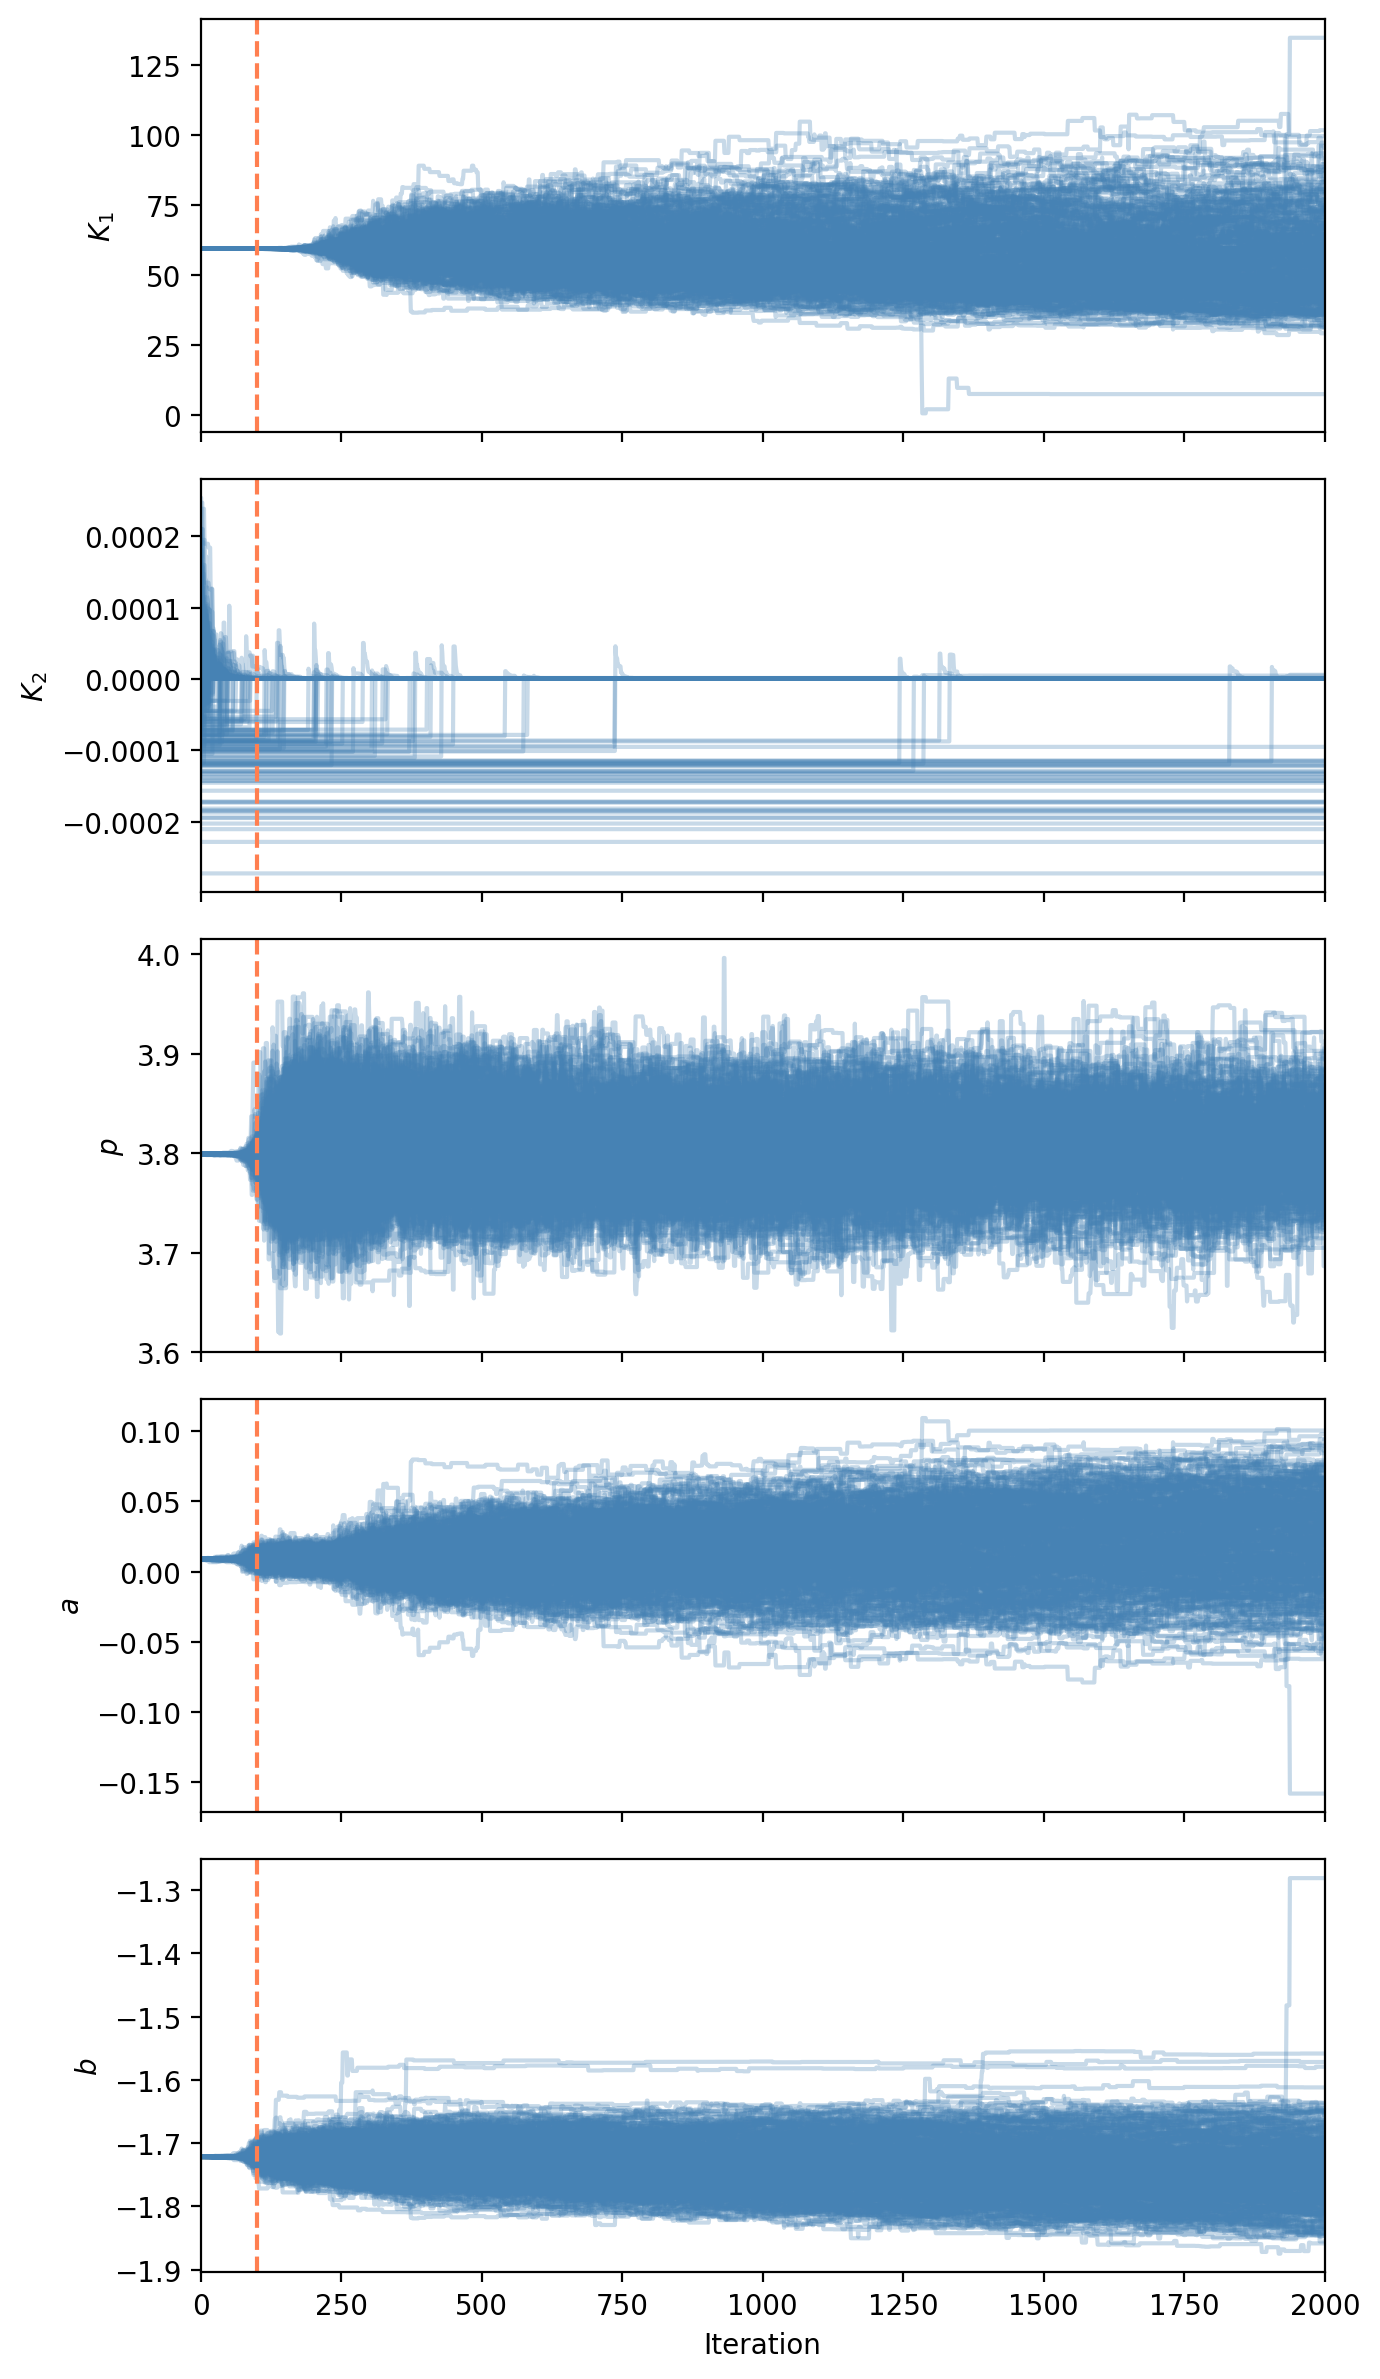

In [19]:
# plot the chains to determine burn in phase
chain_cut_late = 100
functions.make_chain_plot(chain_late, chain_cut_late)

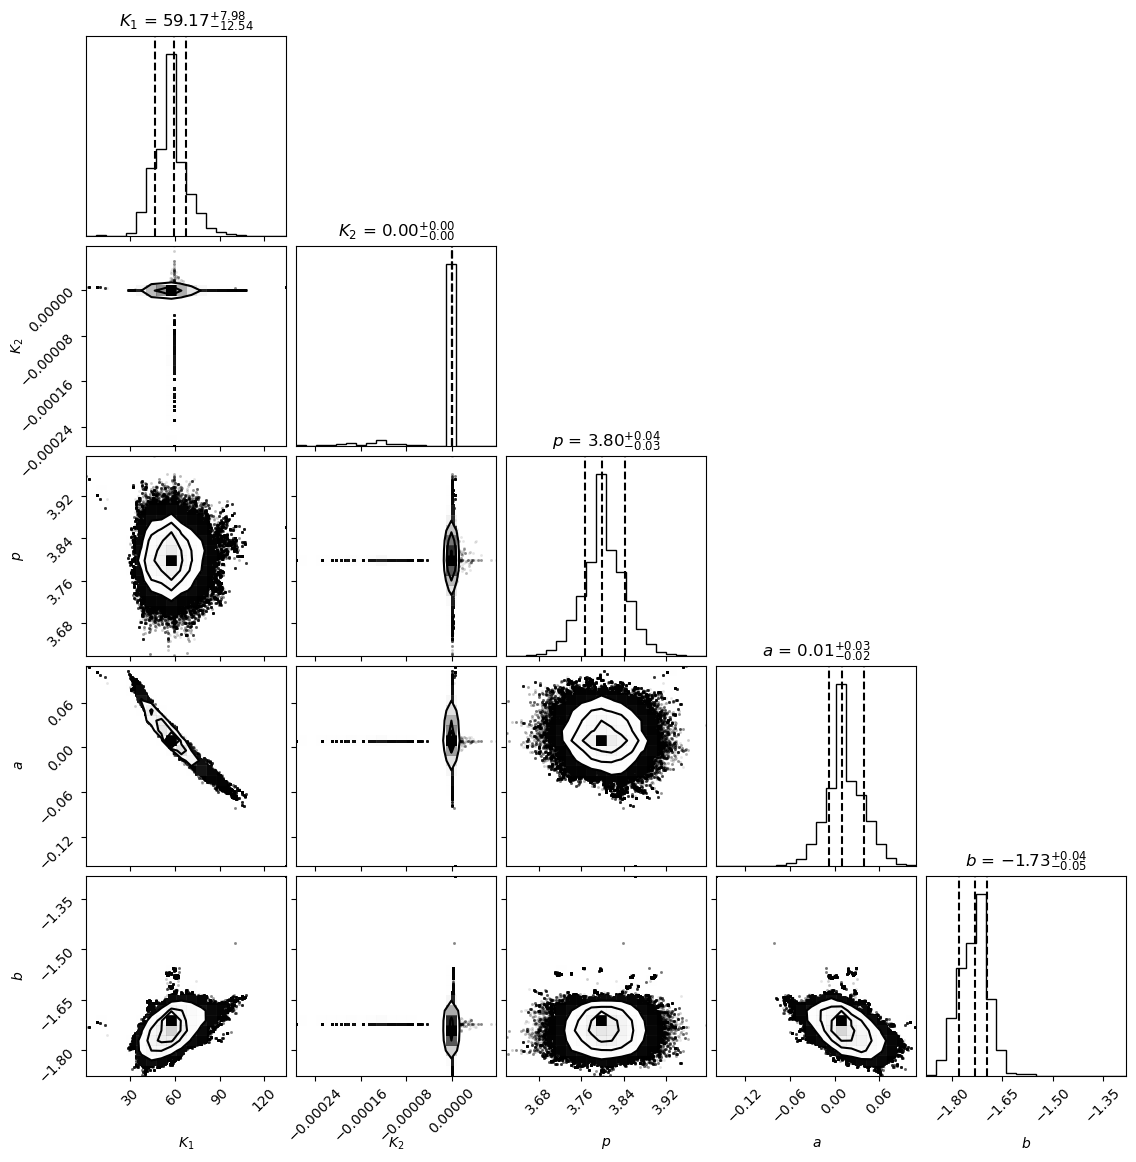

In [20]:
# make corner plots and get the best fit values and uncertainties
good_chain_late = chain_late[:, chain_cut_late:, :]
functions.make_corner_plot(good_chain_late)
best_params_late = functions.get_best_params(good_chain_late)

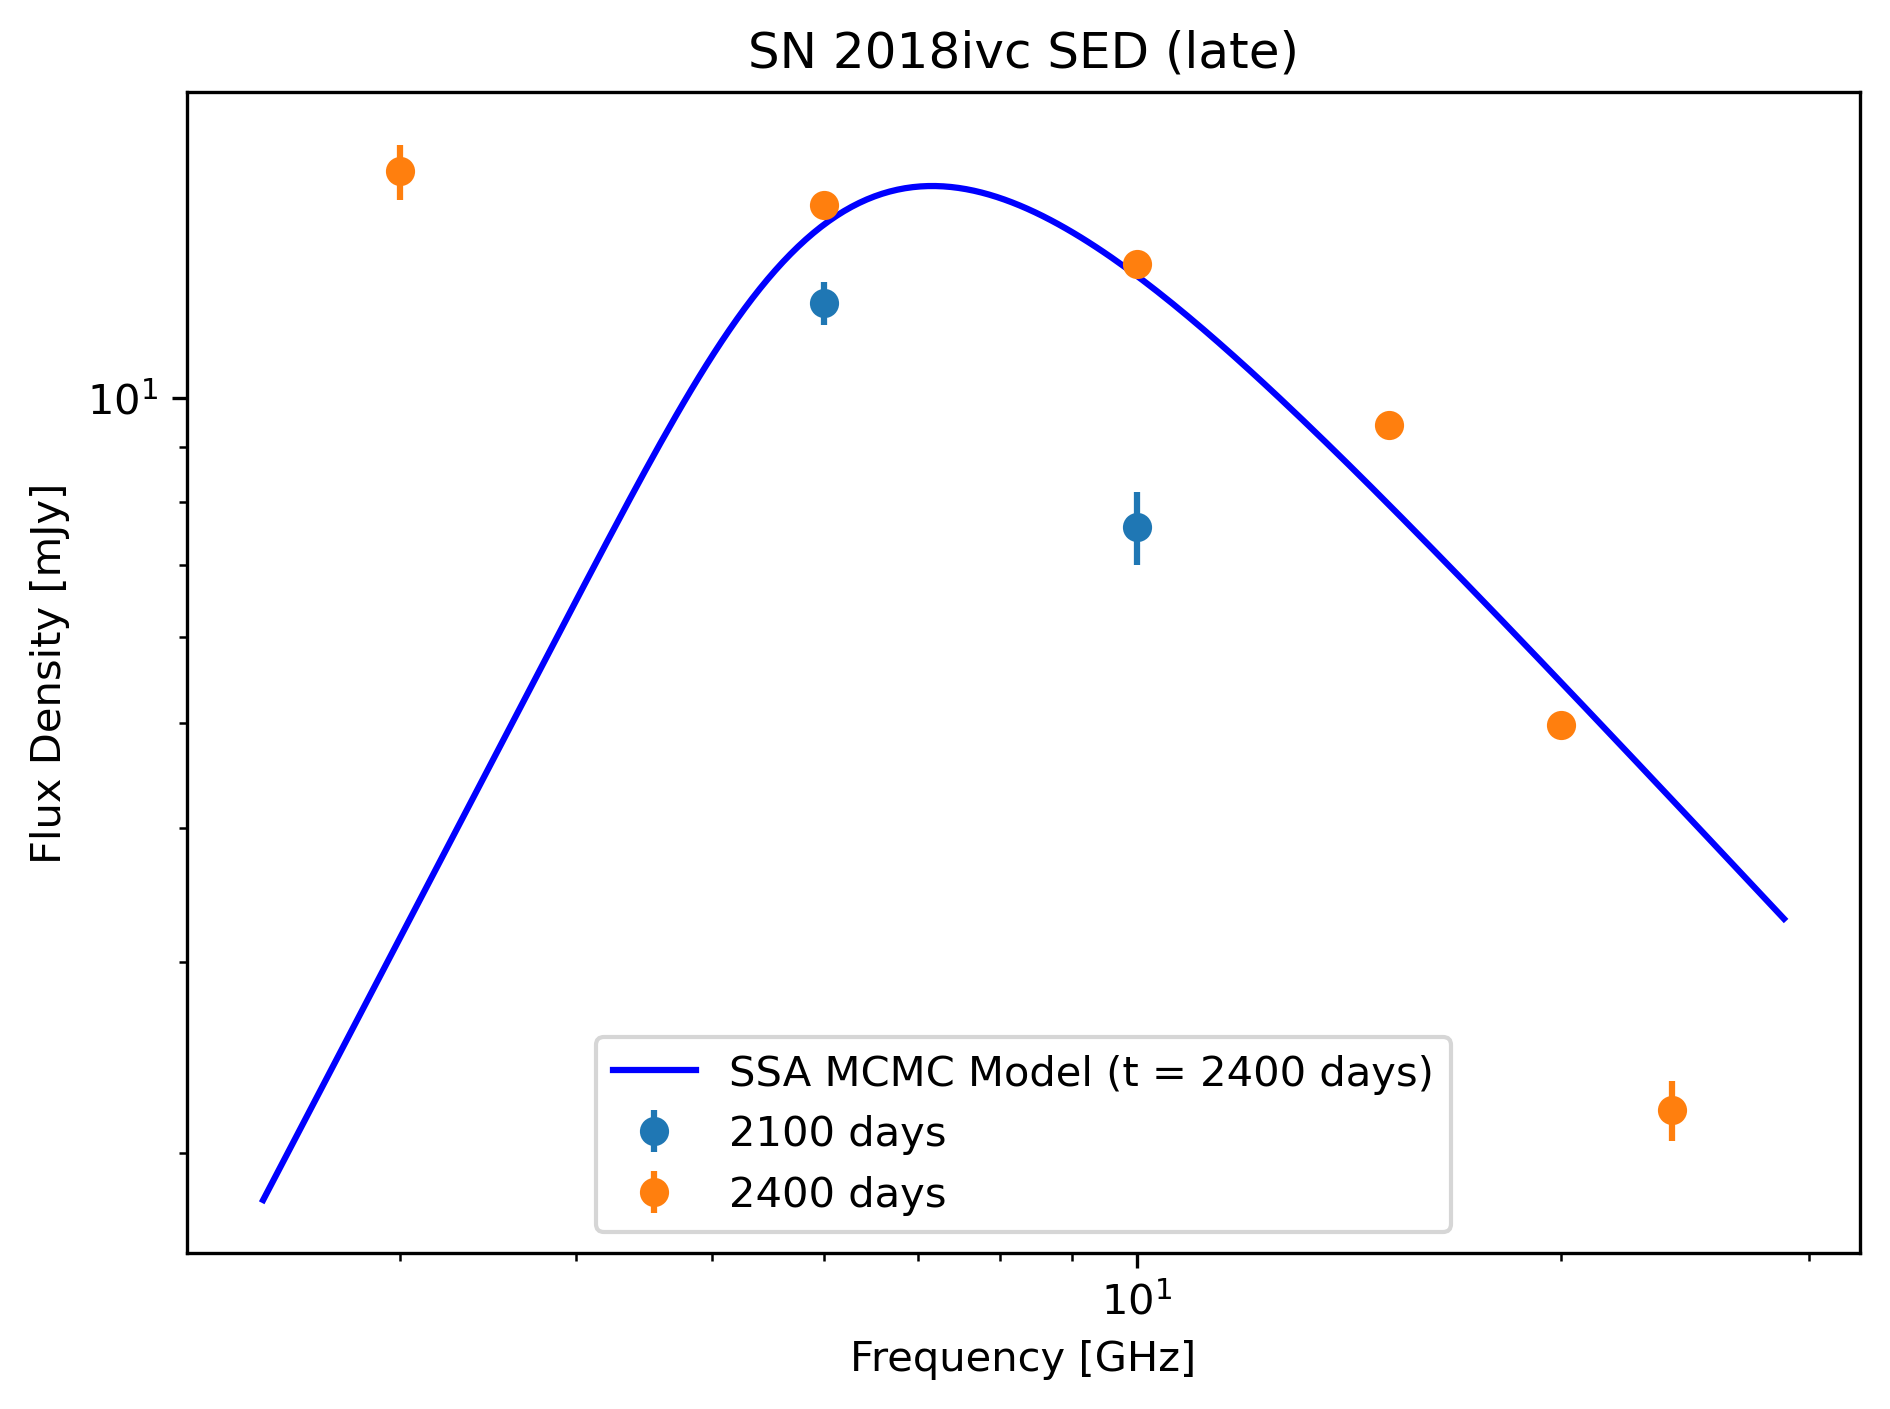

In [21]:
# now plot the MCMC model and data (late)
t_plot_late = 2400.0 

# Frequency grid for the model SED 
fmin_late = data_late['freq'].min() * 0.8
fmax_late = data_late['freq'].max() * 1.2
freq_model_late = np.logspace(np.log10(fmin_late), np.log10(fmax_late), 200)

# unpack best-fit parameters
K1_best_late, K1_err_late, K1_uncertainty_late = best_params_late['$K_1$']
K2_best_late, K2_err_late, K2_uncertainty_late = best_params_late['$K_2$']
p_best_late, p_err_late, p_uncertainty_late = best_params_late['$p$']
a_best_late, a_err_late, a_uncertainty_late = best_params_late['$a$']
b_best_late, b_err_late, b_uncertainty_late = best_params_late['$b$']

# Evaluate the SSA model using the fitted parameters
flux_model_MCMC_late = functions.F_SSA_time(freq_model_late, t_plot_late, K1_best_late, K2_best_late, p_best_late, a_best_late, b_best_late)

plt.figure(dpi=300)

# Plot the data, color-coded by phase
for phase_val_late in np.unique(data_late['phase']):
    mask_phase_late = data_late['phase'] == phase_val_late
    plt.errorbar(
        data_late['freq'][mask_phase_late],
        data_late['flux'][mask_phase_late],
        yerr=data_late['flux_err'][mask_phase_late],
        fmt='o',
        label=f'{phase_val_late:.0f} days'
    )

# Plot the model SED
plt.plot(freq_model_late, flux_model_MCMC_late, 'b-', label=f'SSA MCMC Model (t = {t_plot_late:.0f} days)')

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Density [mJy]')
plt.title('SN 2018ivc SED (late)')
plt.legend()
plt.tight_layout()
plt.show()

# Visualization 
Place to generate plots to share in group meeting, presentations, for the paper, etc.

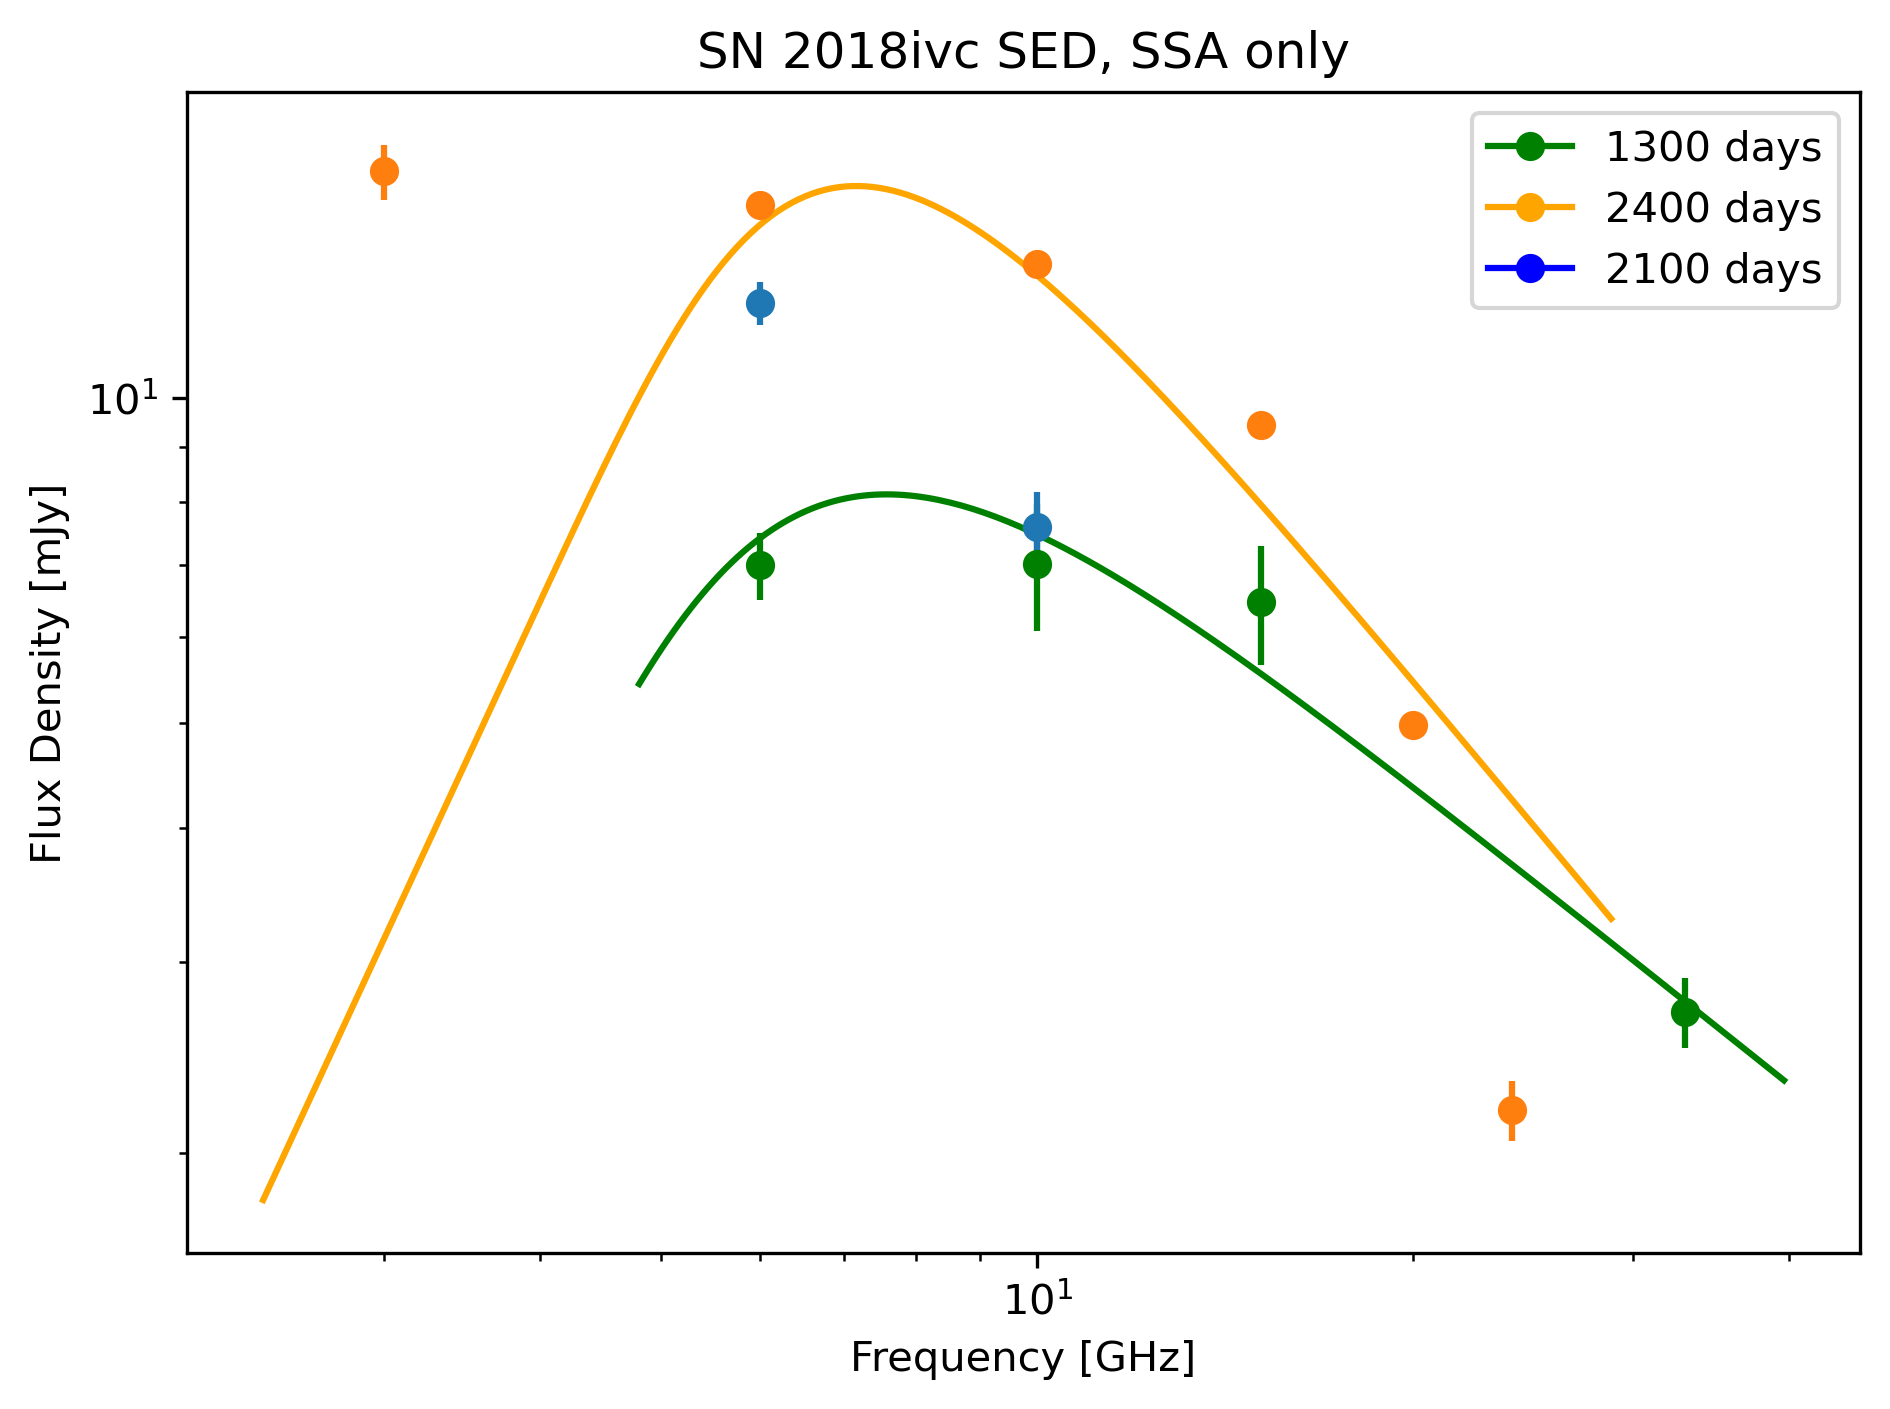

In [30]:
# Overplot early and late data along with their MCMC models
plt.figure(dpi=300)

# Plot early and late data
plt.errorbar(data_early['freq'],data_early['flux'],yerr=data_early['flux_err'],
             fmt='o',color='green',label='_nolegend_')

# plt.errorbar(data_late['freq'],data_late['flux'],yerr=data_late['flux_err'],
#              fmt='o',color='magenta',label='_nolegend_')

# Plot the data, color-coded by phase
for phase_val_late in np.unique(data_late['phase']):
    mask_phase_late = data_late['phase'] == phase_val_late
    plt.errorbar(
        data_late['freq'][mask_phase_late],
        data_late['flux'][mask_phase_late],
        yerr=data_late['flux_err'][mask_phase_late],
        fmt='o',
        label=f'_nolegend_'
    )

# Plot early and late SSA models
plt.plot(freq_model_early,flux_model_MCMC_early,'g-',label='_nolegend_')
plt.plot(freq_model_late,flux_model_MCMC_late,color='orange',linestyle='-',label='_nolegend_')

# Make combine legends
early_handle = mlines.Line2D(
    [], [], color='green', marker='o', linestyle='-',
    label='1300 days'
)

late_handle = mlines.Line2D(
    [], [], color='orange', marker='o', linestyle='-',
    label='2400 days'
)

handle_2100 = mlines.Line2D(
    [], [], color='blue', marker='o',
    label='2100 days'
)

plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [GHz]')
plt.ylabel('Flux Density [mJy]')
plt.title('SN 2018ivc SED, SSA only')

# Use only the proxy handles in the legend
plt.legend(handles=[early_handle, late_handle, handle_2100])

plt.tight_layout()
plt.show()


# Scratchwork
Everything from this point and below

In [4]:
# get inital guesses from running curve_fit on a subset of the data
data_init = data[((data['phase'] < 1700) & (data['flux'] > 0))]

initial_guess = [100.0, 0.1, 2.5, 0.0, 0.0]
bounds = (
    [0.0,   0.0,  1.0, -10.0, -10.0],   # lower bounds
    [np.inf, np.inf, 4.0,  10.0,  10.0] # upper bounds
)

results = functions.calc_params(data_init, functions.F_SSA_time, initial_guess, bounds)


K1 = results['K1'][0]
K2 = results['K2'][0]
p  = results['p'][0]
a  = results['a'][0]
b  = results['b'][0]

In [8]:
# run MCMC with a uniform prior, only on the non-zero data 
data_nonzero = data[data['flux'] > 0]

sampler = functions.run_mcmc([K1, K2, p, a, b], data_nonzero, niters=20000, nwalkers=400)
chain = sampler.chain

Computation time: 965.355784 s


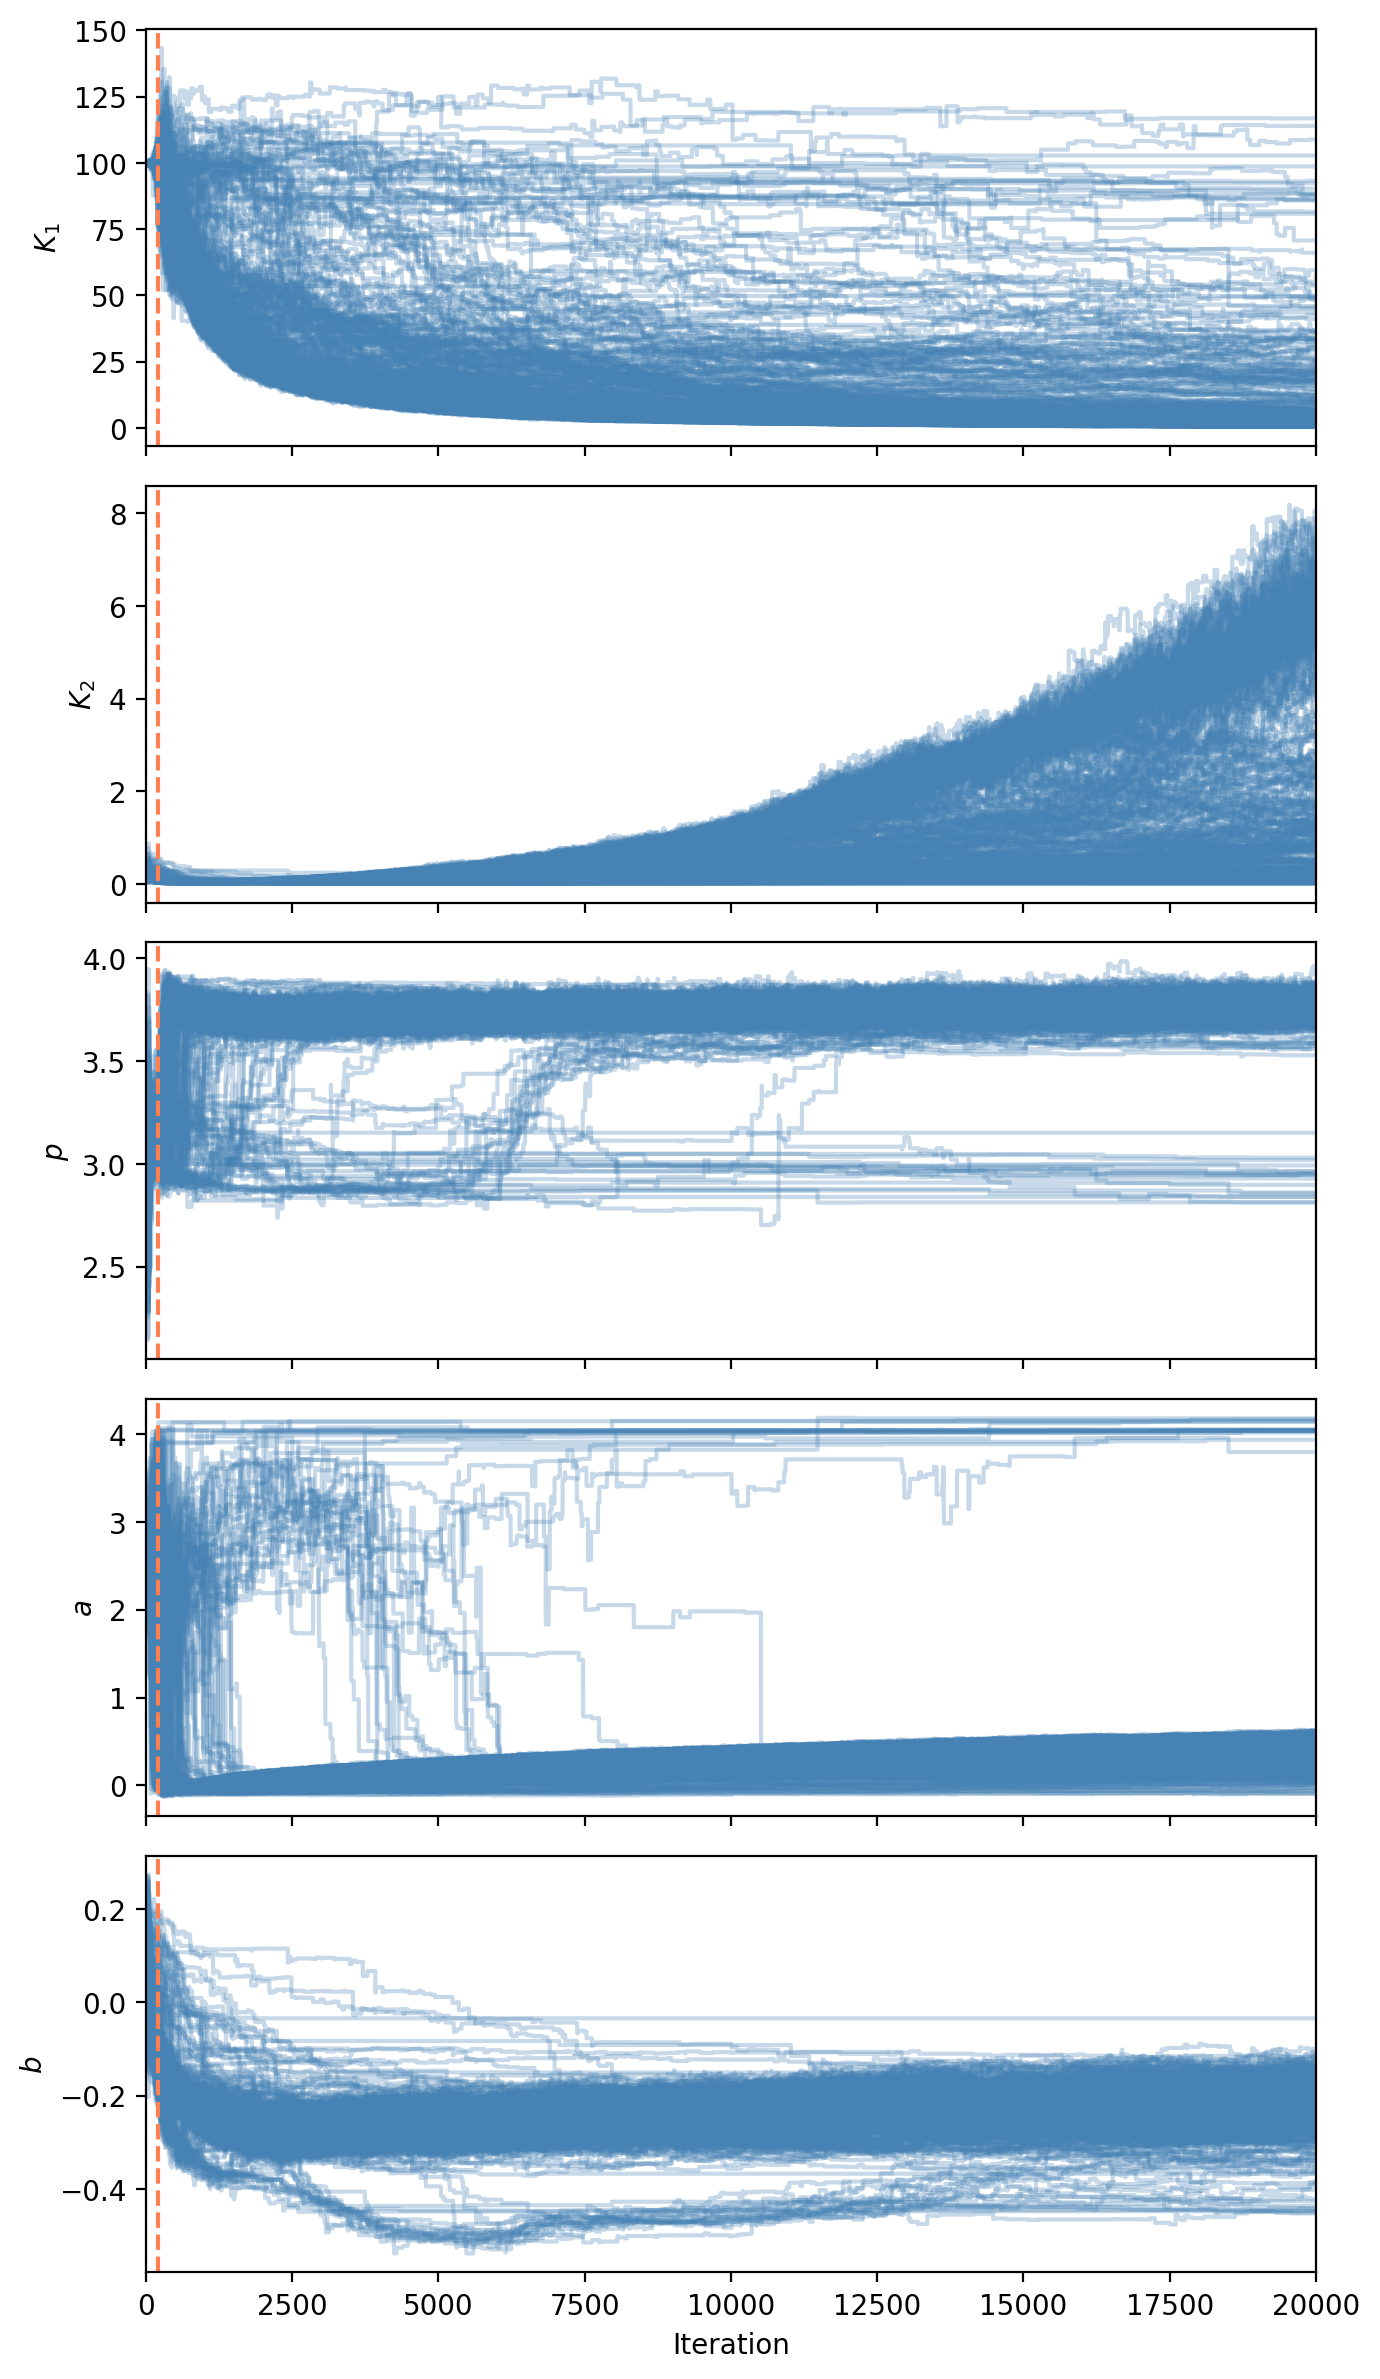

In [9]:
# plot the chains to determine burn in phase
chain_cut = 200
functions.make_chain_plot(chain, chain_cut)

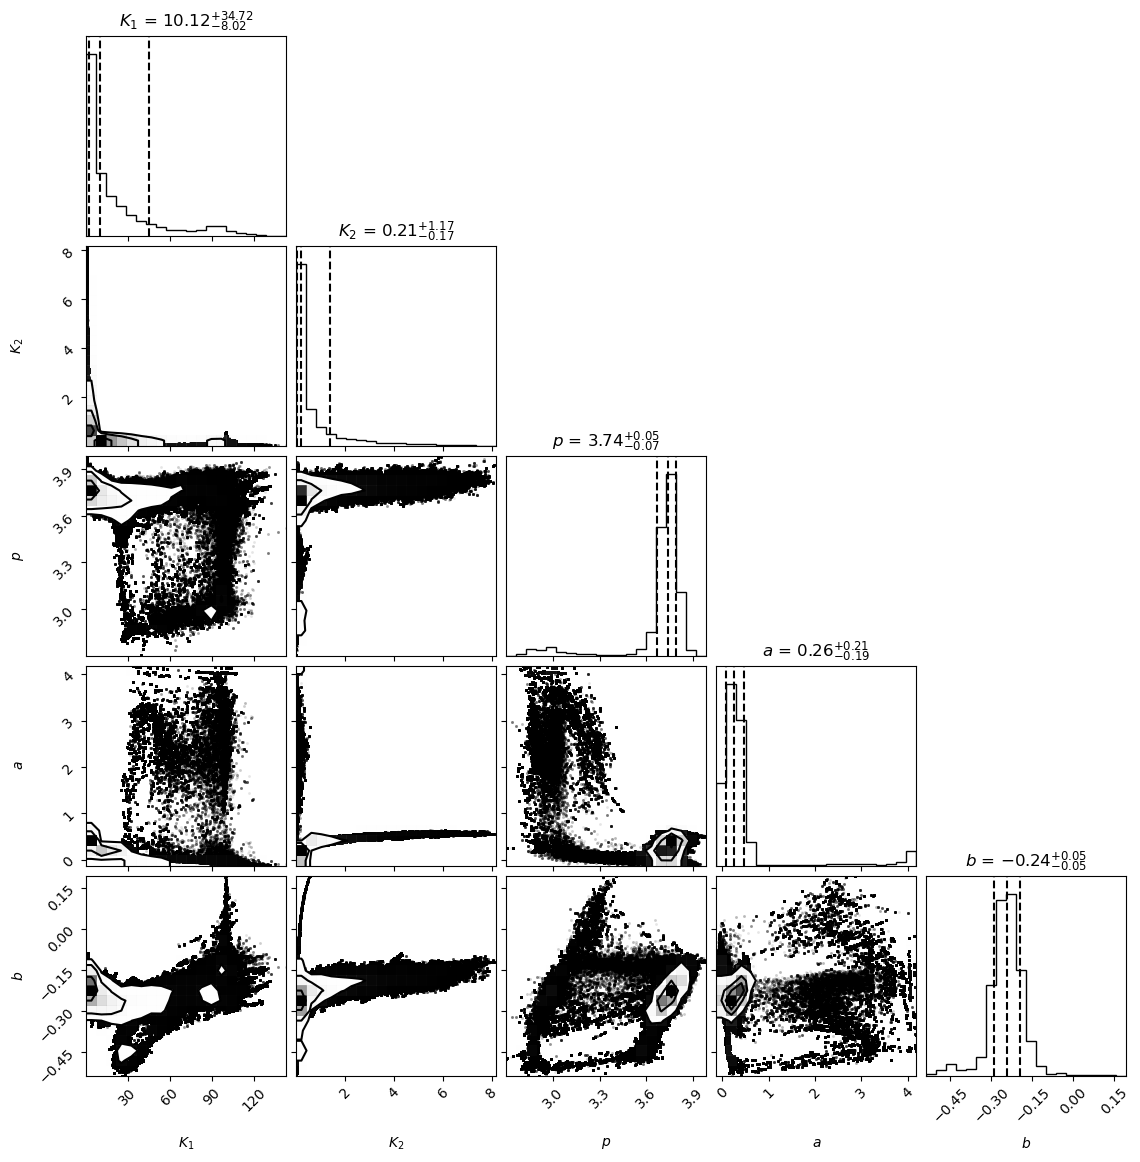

In [10]:
# make corner plots and get the best fit values and uncertainties
good_chain = chain[:, chain_cut:, :]
functions.make_corner_plot(good_chain)
best_params = functions.get_best_params(good_chain)